<a href="https://colab.research.google.com/github/Samy-Annasri/backcasting-for-adversarial-attacks-on-time-series/blob/main/BATS_energie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset,TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import random
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
seed = 999
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
from utils.elec.load_tsf import load_tsf
data = load_tsf("data/electricity_hourly_dataset.tsf")

df = pd.DataFrame([
    {"series_name": d["series_name"], **{f"t_{i}": v for i, v in enumerate(d["series"])}}
    for d in data
])


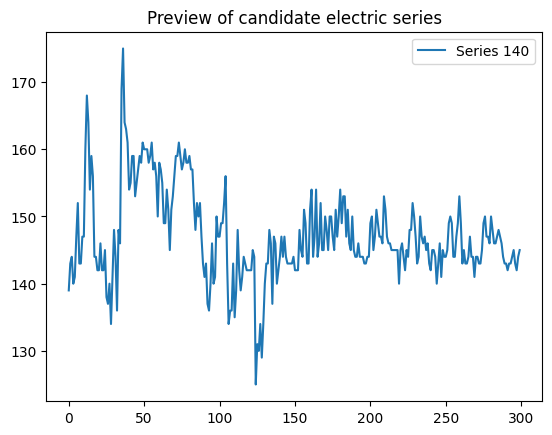

In [5]:
# series find for the moment : '18', '92', '123', '140', '91'
# gonna take 140 for the moment because his stable
for serie_id in ['140']:
    match = df[df['series_name'] == serie_id]

    if not match.empty:
        serie = match.iloc[0, 1:].dropna().astype(float).values
        plt.plot(serie[:300], label=f"Series {serie_id}")
    else:
        print(f"[!] Série {serie_id} non trouvée dans le DataFrame")

plt.legend()
plt.title("Preview of candidate electric series")
plt.show()


In [6]:
from utils.elec.setup_elec import prepare_electric_dataset

In [7]:
sequence_length = 30
result = prepare_electric_dataset(serie, sequence_length)

train_loader = result['train_loader']
test_loader = result['test_loader']
train_size = result['train_size']
serie_min, serie_max = result['min_max']
dates = result['dates']
print(dates)

[30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243,

In [8]:
from utils.elec.train_model_elec import train_models_elec

In [9]:
from models.lstm import SimpleLSTM
model = SimpleLSTM(input_size=1, hidden_size=64, output_size=1, num_layers=2)
model.to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 30

train_models_elec(model, loss_fn, optimizer, num_epochs, train_loader,device)

Epoch [1/30], Train Loss: 0.0084
Epoch [2/30], Train Loss: 0.0011
Epoch [3/30], Train Loss: 0.0010
Epoch [4/30], Train Loss: 0.0009
Epoch [5/30], Train Loss: 0.0009
Epoch [6/30], Train Loss: 0.0008
Epoch [7/30], Train Loss: 0.0007
Epoch [8/30], Train Loss: 0.0006
Epoch [9/30], Train Loss: 0.0005
Epoch [10/30], Train Loss: 0.0005
Epoch [11/30], Train Loss: 0.0004
Epoch [12/30], Train Loss: 0.0004
Epoch [13/30], Train Loss: 0.0004
Epoch [14/30], Train Loss: 0.0004
Epoch [15/30], Train Loss: 0.0004
Epoch [16/30], Train Loss: 0.0004
Epoch [17/30], Train Loss: 0.0004
Epoch [18/30], Train Loss: 0.0004
Epoch [19/30], Train Loss: 0.0004
Epoch [20/30], Train Loss: 0.0004
Epoch [21/30], Train Loss: 0.0004
Epoch [22/30], Train Loss: 0.0004
Epoch [23/30], Train Loss: 0.0004
Epoch [24/30], Train Loss: 0.0004
Epoch [25/30], Train Loss: 0.0004
Epoch [26/30], Train Loss: 0.0004
Epoch [27/30], Train Loss: 0.0004
Epoch [28/30], Train Loss: 0.0004
Epoch [29/30], Train Loss: 0.0004
Epoch [30/30], Train Lo

In [10]:
from utils.elec.evaluate_model_elec import evaluate_model_elec

In [11]:
results = evaluate_model_elec(model, test_loader, dates, train_size)

real_values = results['real_values']
predicted_values = results['predicted_values']
test_dates = results['test_dates']

In [12]:
# Computes scalar similarity (cosine similarity) between true and predicted values.
# Higher values indicate that adversarial predictions remain directionally aligned
# with the true values, suggesting stealthy and rational attacks!
def scalar_similarity(y_true, y_pred):
    numerator = np.dot(y_true, y_pred)
    denominator = np.linalg.norm(y_true) * np.linalg.norm(y_pred)
    if denominator == 0:
        return 0.0
    return numerator / denominator

In [13]:
# Creation of the tab result for plotting adversial attack result
models = ['LSTM','RNN','GRU']
metrics = ['MAE', "RMSE", 'SIM']

row_index = pd.MultiIndex.from_product([models, metrics], names=['Model', 'Metric'])

attacks = ['NA','PAST','REV']
epsilons = {
    'NA': [0],
    'PAST':[0],
    'REV':[0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1, 0.2],
}

col_tuples = []
for atk, eps_list in epsilons.items():
    for eps in eps_list:
        col_tuples.append((atk, f"{eps:.2f}"))

col_index = pd.MultiIndex.from_tuples(col_tuples, names=['Attack', 'ε'])

res_tab = pd.DataFrame(index=row_index, columns=col_index, dtype=float)

print(res_tab)

Attack         NA PAST  REV                                   
ε            0.00 0.00 0.01 0.02 0.03 0.04 0.05 0.07 0.10 0.20
Model Metric                                                  
LSTM  MAE     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      RMSE    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      SIM     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
RNN   MAE     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      RMSE    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      SIM     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
GRU   MAE     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      RMSE    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      SIM     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN


In [14]:
from utils.elec.log_and_plot_elec import log_and_plot_elec

LSTM | NA – Epsilon 0.00 – MAE: 1.5802 | SIM: 0.9998


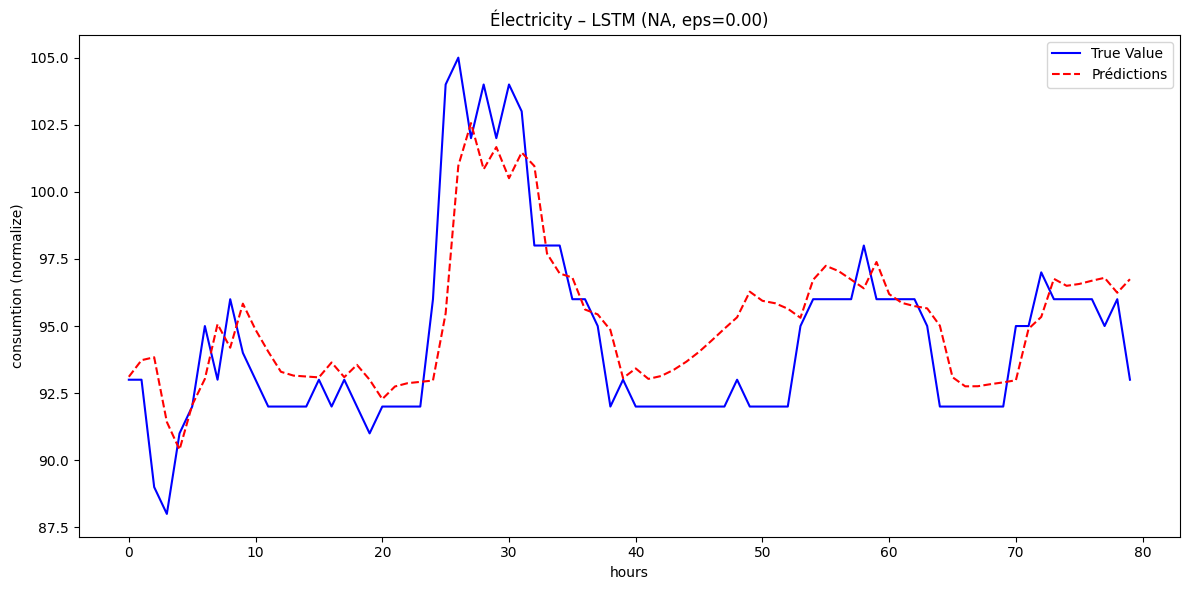

In [15]:
# Denormalize
true_values_denorm = real_values * (serie_max - serie_min) + serie_min
predictions_denorm = predicted_values * (serie_max - serie_min) + serie_min

n_hours = 80

log_and_plot_elec(
    true_values=true_values_denorm[-n_hours:],
    predictions=predictions_denorm[-n_hours:],
    model_name='LSTM',
    attack_name='NA',
    epsilon=0.00,
    res_tab=res_tab,
    similarity_fn=scalar_similarity,
    save_path=f"results/elec/SEED_{seed}/plots/NA/0",
    save_png=True
)

In [16]:
result_rev = prepare_electric_dataset(serie, sequence_length,reverse=True)

train_loader_rev = result_rev['train_loader']
test_loader_rev = result_rev['test_loader']
train_size_rev = result_rev['train_size']
serie_min_rev, serie_max_rev = result_rev['min_max']
dates_rev = result_rev['dates']
print(dates_rev)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [17]:
model_rev = SimpleLSTM(input_size=1, hidden_size=64, output_size=1, num_layers=2)
optimizer_rev = torch.optim.Adam(model_rev.parameters(), lr=0.001)
model_rev.to(device)
train_models_elec(model_rev, loss_fn, optimizer_rev, num_epochs, train_loader_rev,device)


Epoch [1/30], Train Loss: 0.0067
Epoch [2/30], Train Loss: 0.0010
Epoch [3/30], Train Loss: 0.0009
Epoch [4/30], Train Loss: 0.0009
Epoch [5/30], Train Loss: 0.0008
Epoch [6/30], Train Loss: 0.0007
Epoch [7/30], Train Loss: 0.0006
Epoch [8/30], Train Loss: 0.0005
Epoch [9/30], Train Loss: 0.0005
Epoch [10/30], Train Loss: 0.0005
Epoch [11/30], Train Loss: 0.0005
Epoch [12/30], Train Loss: 0.0004
Epoch [13/30], Train Loss: 0.0004
Epoch [14/30], Train Loss: 0.0004
Epoch [15/30], Train Loss: 0.0004
Epoch [16/30], Train Loss: 0.0004
Epoch [17/30], Train Loss: 0.0004
Epoch [18/30], Train Loss: 0.0004
Epoch [19/30], Train Loss: 0.0004
Epoch [20/30], Train Loss: 0.0004
Epoch [21/30], Train Loss: 0.0004
Epoch [22/30], Train Loss: 0.0004
Epoch [23/30], Train Loss: 0.0004
Epoch [24/30], Train Loss: 0.0004
Epoch [25/30], Train Loss: 0.0004
Epoch [26/30], Train Loss: 0.0004
Epoch [27/30], Train Loss: 0.0004
Epoch [28/30], Train Loss: 0.0004
Epoch [29/30], Train Loss: 0.0004
Epoch [30/30], Train Lo

In [18]:
results_rev = evaluate_model_elec(model_rev, test_loader_rev, dates_rev, train_size_rev)

real_values_rev = results_rev['real_values']
predicted_values_rev = results_rev['predicted_values']
test_dates_rev = results_rev['test_dates']

LSTM | PAST – Epsilon 0.00 – MAE: 1.3583 | SIM: 0.9998


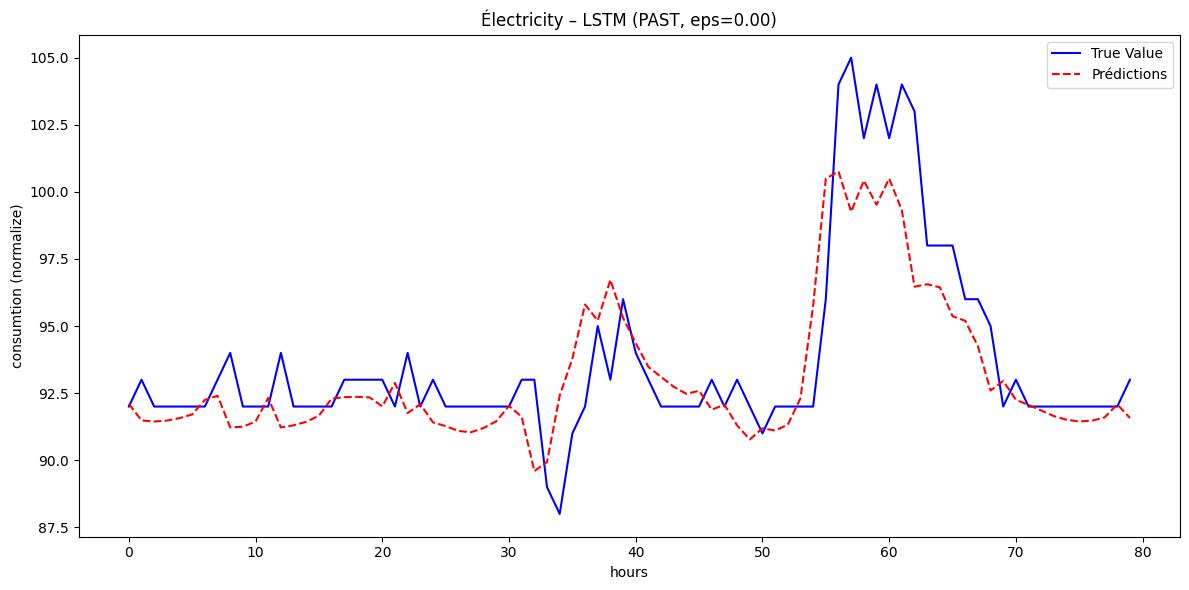

In [19]:
# Denormalize
true_values_denorm_rev = real_values_rev * (serie_max_rev - serie_min_rev) + serie_min_rev
predictions_denorm_rev = predicted_values_rev * (serie_max_rev - serie_min_rev) + serie_min_rev

log_and_plot_elec(
    true_values=true_values_denorm_rev[-n_hours:],
    predictions=predictions_denorm_rev[-n_hours:],
    model_name='LSTM',
    attack_name='PAST',
    epsilon=0.00,
    res_tab=res_tab,
    similarity_fn=scalar_similarity,
    save_path=f"results/elec/SEED_{seed}/plots/PAST/0",
    save_png=True
)

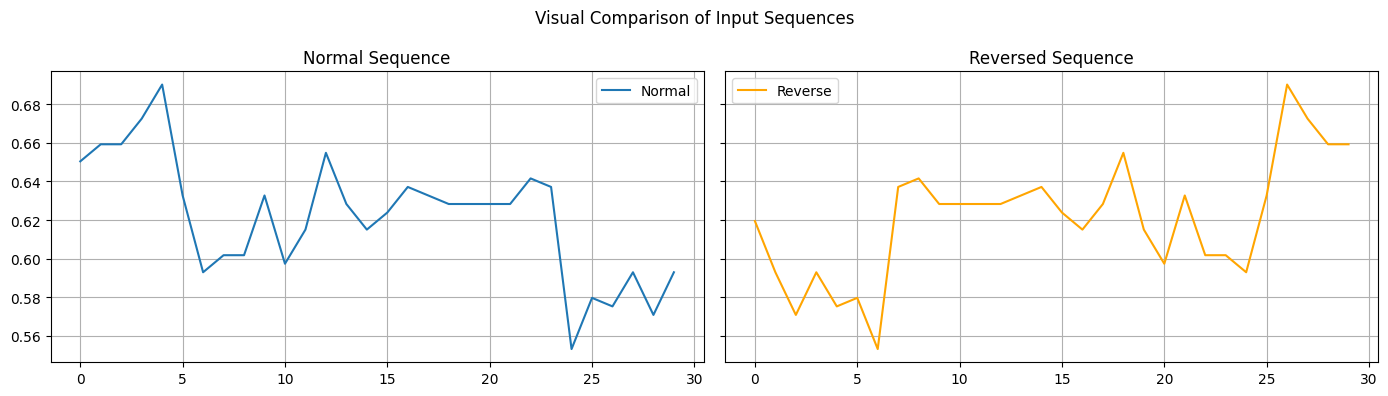

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axs[0].plot(result['X'][100].squeeze(), label='Normal')
axs[0].set_title("Normal Sequence")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(result_rev['X'][100].squeeze(), label='Reverse', color='orange')
axs[1].set_title("Reversed Sequence")
axs[1].legend()
axs[1].grid(True)

plt.suptitle("Visual Comparison of Input Sequences")
plt.tight_layout()
plt.show()


LSTM | REV – Epsilon 0.01 – MAE: 2.8471 | SIM: 0.9995


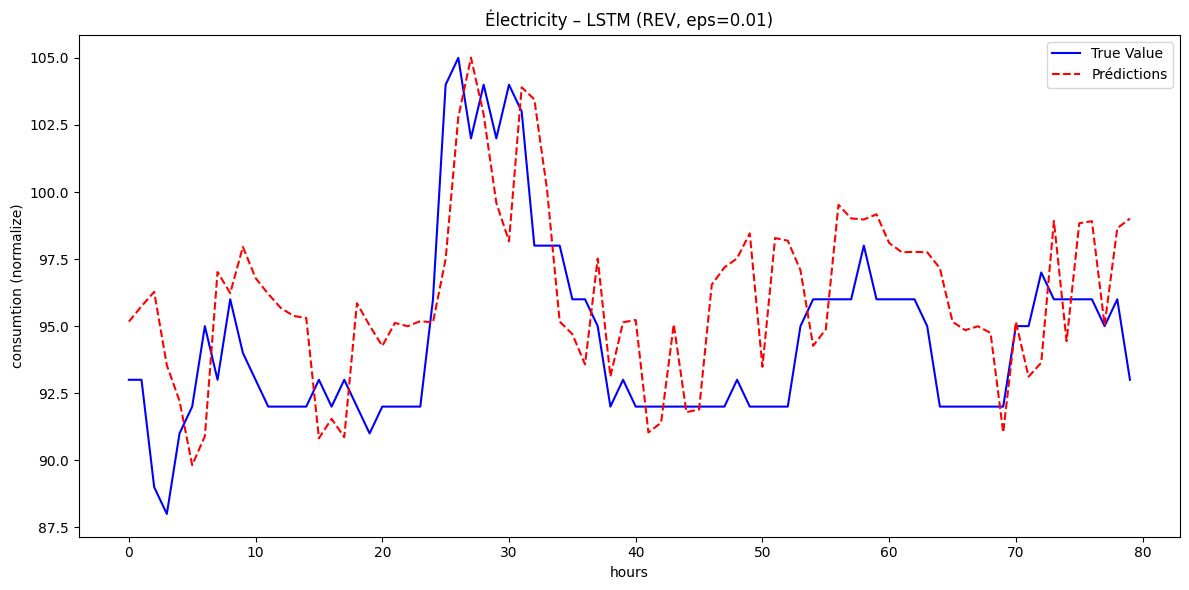

LSTM | REV – Epsilon 0.02 – MAE: 4.4876 | SIM: 0.9988


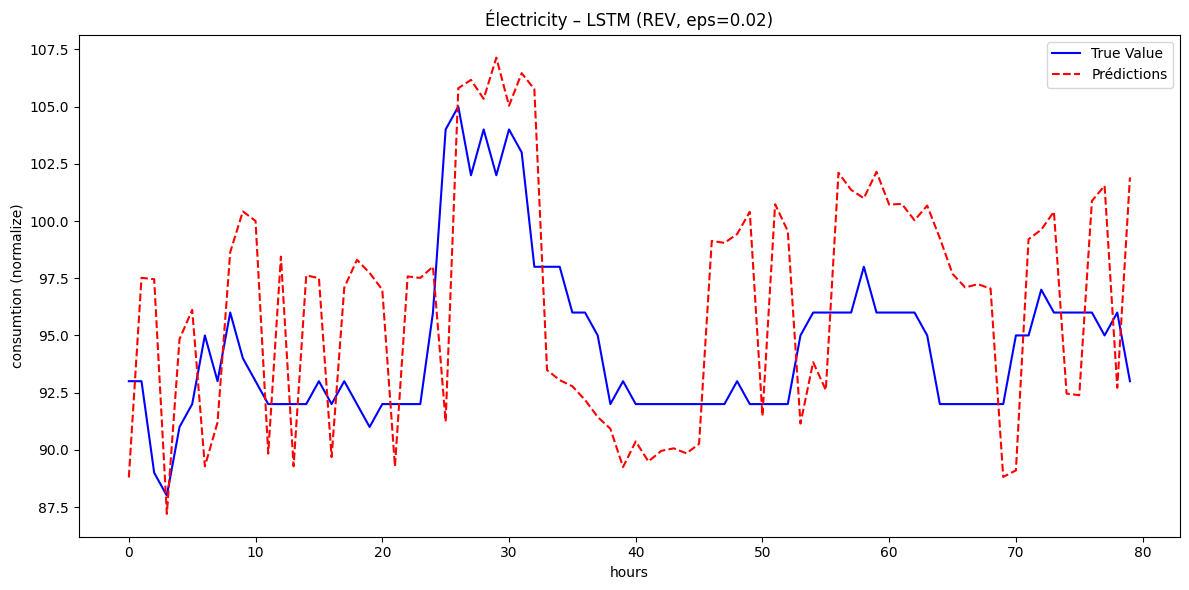

LSTM | REV – Epsilon 0.03 – MAE: 6.5457 | SIM: 0.9982


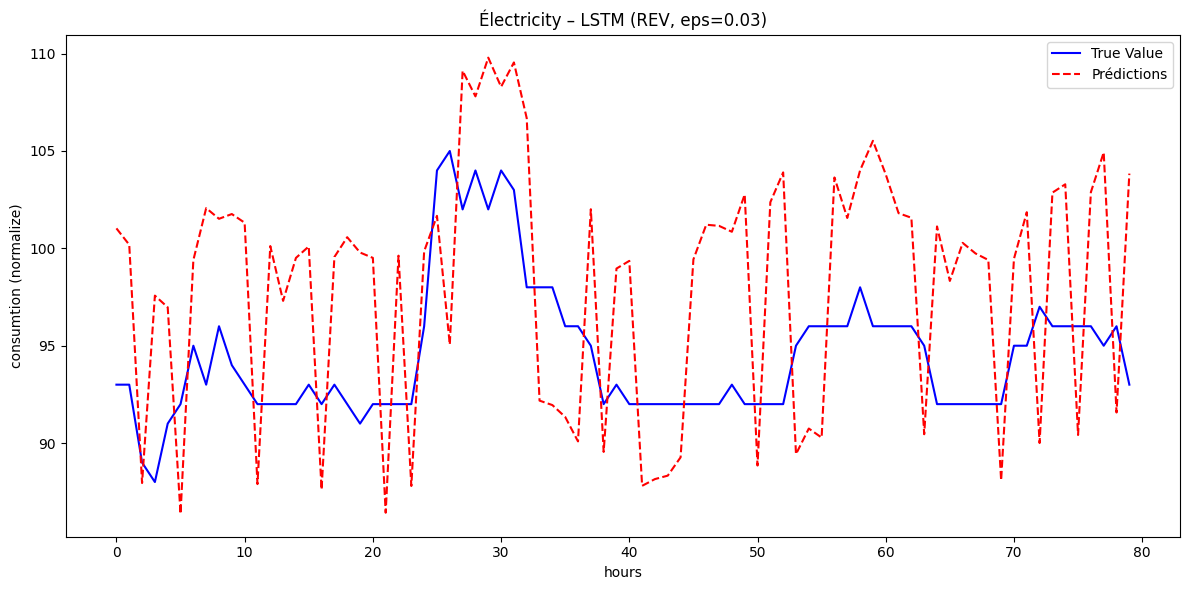

LSTM | REV – Epsilon 0.04 – MAE: 8.6941 | SIM: 0.9964


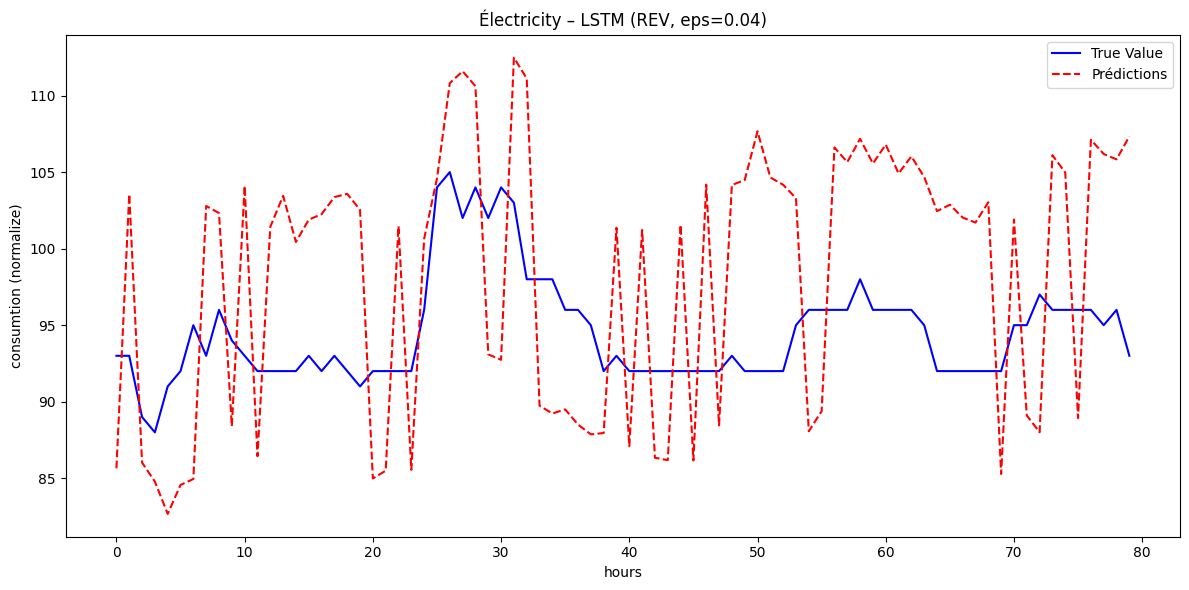

LSTM | REV – Epsilon 0.05 – MAE: 11.2483 | SIM: 0.9945


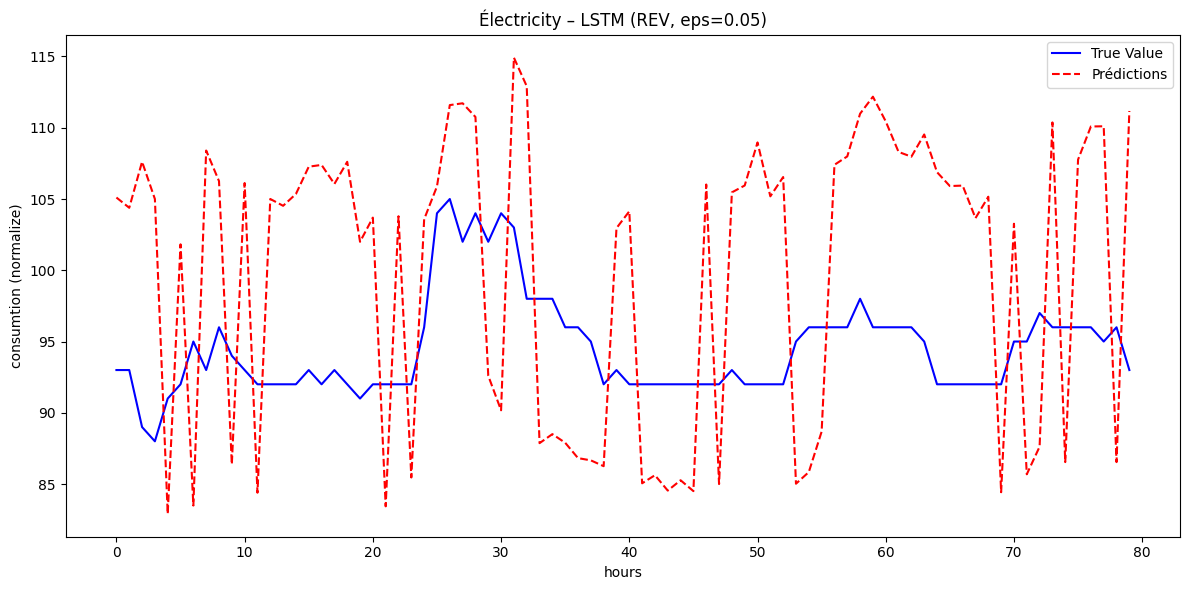

LSTM | REV – Epsilon 0.07 – MAE: 16.7397 | SIM: 0.9895


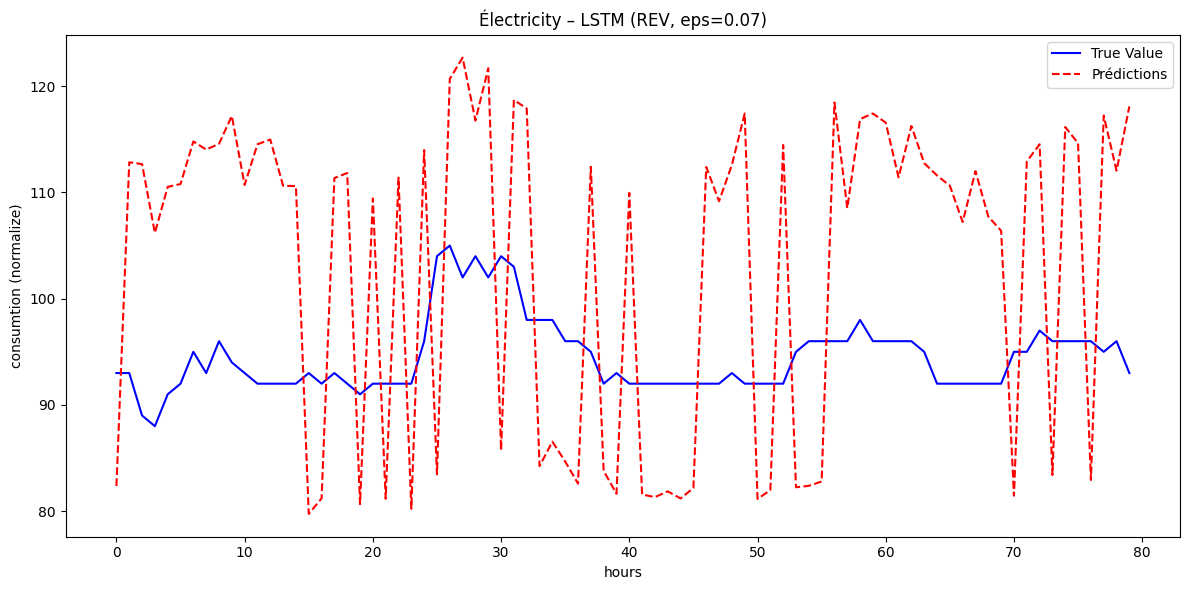

LSTM | REV – Epsilon 0.10 – MAE: 21.9615 | SIM: 0.9849


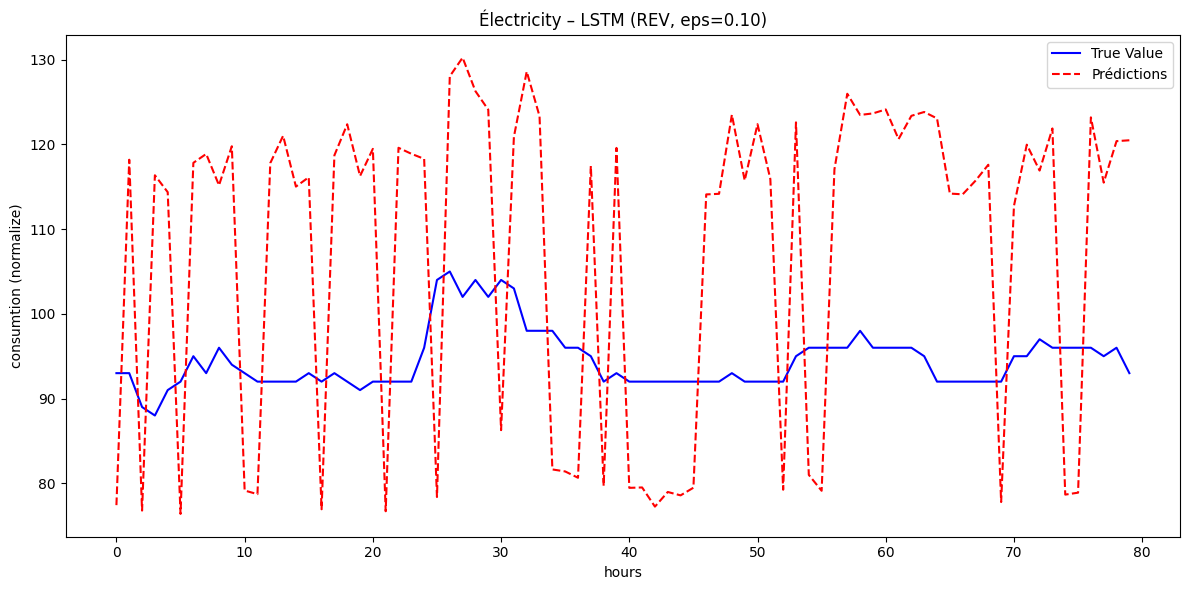

LSTM | REV – Epsilon 0.20 – MAE: 38.3610 | SIM: 0.9652


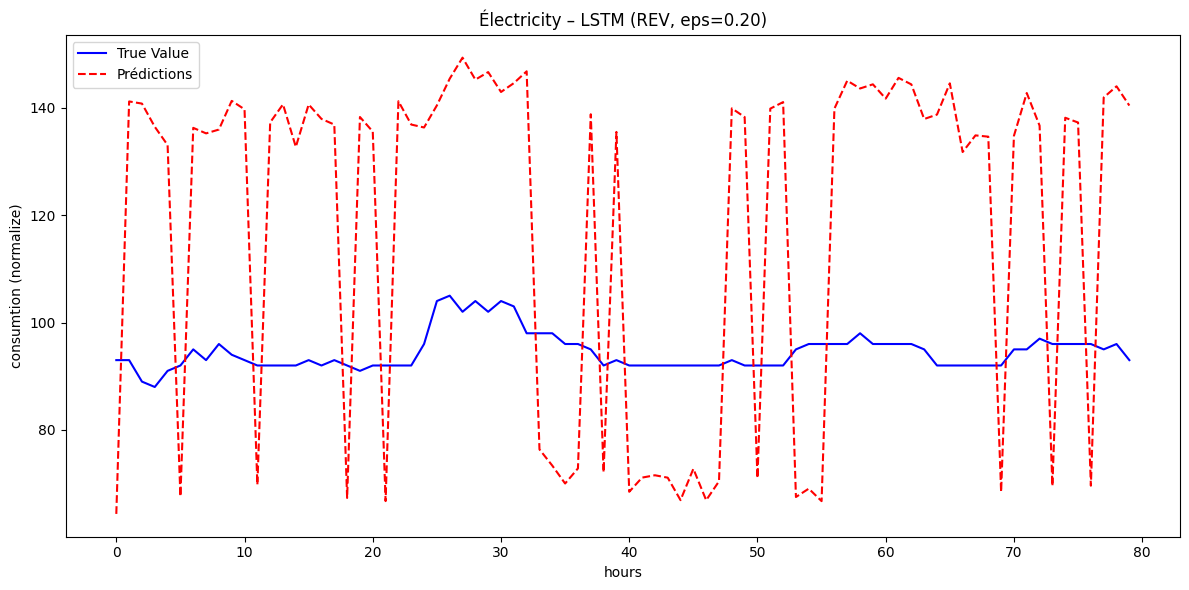

In [21]:
from attack.rev import reverse_forecast_attack

epsilons = [0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1, 0.2]
results = reverse_forecast_attack(
    model_rev, model,
    test_loader_rev, test_loader,
    epsilons,
    serie_min_rev, serie_max_rev
)

for esp, (true_vals, preds) in results.items():
  log_and_plot_elec(
      true_values=true_vals[-n_hours:],
      predictions=preds[-n_hours:],
      model_name='LSTM',
      attack_name='REV',
      epsilon=esp,
      res_tab=res_tab,
      similarity_fn=scalar_similarity,
      save_path=f"results/elec/SEED_{seed}/plots/REV/{esp}",
      save_png=True
  )

In [22]:
display(res_tab)

Attack              NA      PAST       REV                                \
ε                 0.00      0.00      0.01      0.02      0.03      0.04   
Model Metric                                                               
LSTM  MAE     1.580212  1.358286  2.847092  4.487642  6.545673  8.694085   
      RMSE    2.118119  1.961298  3.301107  5.010583  6.896636  9.098038   
      SIM     0.999774  0.999800  0.999543  0.998850  0.998154  0.996407   
RNN   MAE          NaN       NaN       NaN       NaN       NaN       NaN   
      RMSE         NaN       NaN       NaN       NaN       NaN       NaN   
      SIM          NaN       NaN       NaN       NaN       NaN       NaN   
GRU   MAE          NaN       NaN       NaN       NaN       NaN       NaN   
      RMSE         NaN       NaN       NaN       NaN       NaN       NaN   
      SIM          NaN       NaN       NaN       NaN       NaN       NaN   

Attack                                                    
ε                  0.05       0.07       0.10       0.20  
Model Metric                                              
LSTM  MAE     11.248319  16.739714  21.961461  38.360962  
      RMSE    11.713782  17.265378  22.670161  39.716961  
      SIM      0.994509   0.989532   0.984862   0.965235  
RNN   MAE           NaN        NaN        NaN        NaN  
      RMSE          NaN        NaN        NaN        NaN  
      SIM           NaN        NaN        NaN        NaN  
GRU   MAE           NaN        NaN        NaN        NaN  
      RMSE          NaN        NaN        NaN        NaN  
      SIM           NaN        NaN        NaN        NaN

In [23]:
from models.rnn import SimpleRNN
model_rnn = SimpleRNN(input_size=1, hidden_size=64, output_size=1, num_layers=2)
model_rnn.to(device)
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=0.001)
train_models_elec(model_rnn, loss_fn, optimizer, num_epochs, train_loader,device)

Epoch [1/30], Train Loss: 0.0052
Epoch [2/30], Train Loss: 0.0006
Epoch [3/30], Train Loss: 0.0005
Epoch [4/30], Train Loss: 0.0005
Epoch [5/30], Train Loss: 0.0005
Epoch [6/30], Train Loss: 0.0004
Epoch [7/30], Train Loss: 0.0005
Epoch [8/30], Train Loss: 0.0004
Epoch [9/30], Train Loss: 0.0004
Epoch [10/30], Train Loss: 0.0004
Epoch [11/30], Train Loss: 0.0004
Epoch [12/30], Train Loss: 0.0004
Epoch [13/30], Train Loss: 0.0004
Epoch [14/30], Train Loss: 0.0004
Epoch [15/30], Train Loss: 0.0004
Epoch [16/30], Train Loss: 0.0004
Epoch [17/30], Train Loss: 0.0004
Epoch [18/30], Train Loss: 0.0004
Epoch [19/30], Train Loss: 0.0004
Epoch [20/30], Train Loss: 0.0004
Epoch [21/30], Train Loss: 0.0004
Epoch [22/30], Train Loss: 0.0004
Epoch [23/30], Train Loss: 0.0004
Epoch [24/30], Train Loss: 0.0004
Epoch [25/30], Train Loss: 0.0004
Epoch [26/30], Train Loss: 0.0004
Epoch [27/30], Train Loss: 0.0004
Epoch [28/30], Train Loss: 0.0004
Epoch [29/30], Train Loss: 0.0004
Epoch [30/30], Train Lo

RNN | NA – Epsilon 0.00 – MAE: 2.0119 | SIM: 0.9998


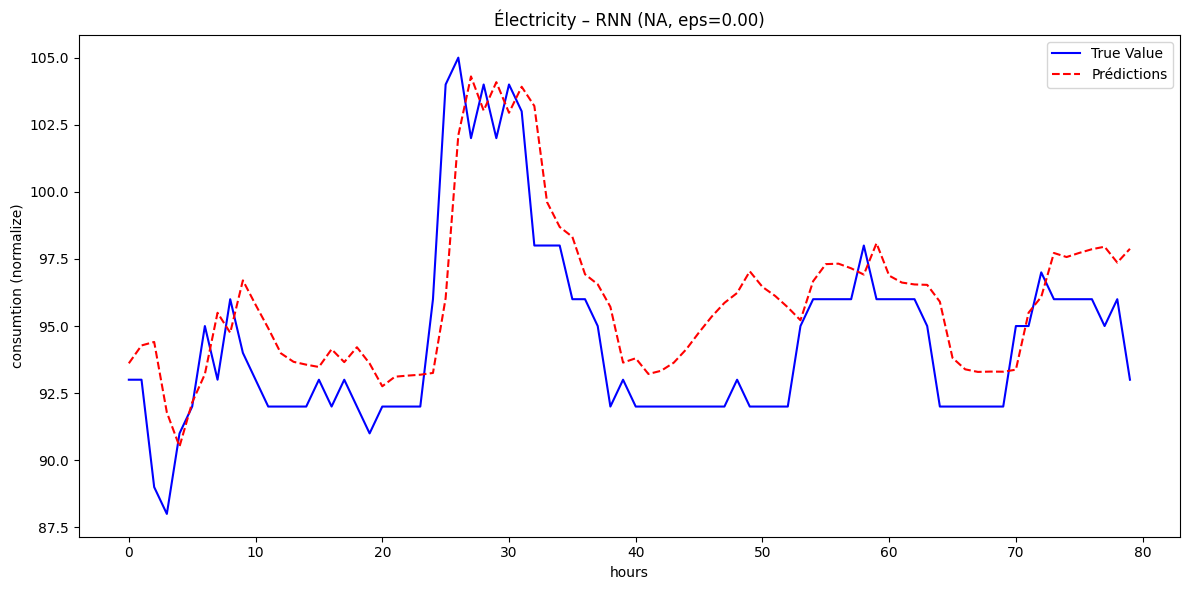

In [24]:
results_rnn = evaluate_model_elec(model_rnn, test_loader, dates, train_size)

real_values_rnn = results_rnn['real_values']
predicted_values_rnn = results_rnn['predicted_values']
test_dates_rnn = results_rnn['test_dates']

true_values_denorm_rnn = real_values_rnn * (serie_max - serie_min) + serie_min
predictions_denorm_rnn = predicted_values_rnn * (serie_max - serie_min) + serie_min

log_and_plot_elec(
    true_values=true_values_denorm_rnn[-n_hours:],
    predictions=predictions_denorm_rnn[-n_hours:],
    model_name='RNN',
    attack_name='NA',
    epsilon=0.00,
    res_tab=res_tab,
    similarity_fn=scalar_similarity,
    save_path=f"results/elec/SEED_{seed}/plots/PAST/0",
    save_png=True
)

In [25]:
model_rnn_rev = SimpleRNN(input_size=1, hidden_size=64, output_size=1, num_layers=2)
model_rnn_rev.to(device)
optimizer = torch.optim.Adam(model_rnn_rev.parameters(), lr=0.001)
train_models_elec(model_rnn_rev, loss_fn, optimizer, num_epochs, train_loader_rev,device)

Epoch [1/30], Train Loss: 0.0037
Epoch [2/30], Train Loss: 0.0006
Epoch [3/30], Train Loss: 0.0005
Epoch [4/30], Train Loss: 0.0004
Epoch [5/30], Train Loss: 0.0004
Epoch [6/30], Train Loss: 0.0004
Epoch [7/30], Train Loss: 0.0004
Epoch [8/30], Train Loss: 0.0004
Epoch [9/30], Train Loss: 0.0004
Epoch [10/30], Train Loss: 0.0004
Epoch [11/30], Train Loss: 0.0004
Epoch [12/30], Train Loss: 0.0004
Epoch [13/30], Train Loss: 0.0004
Epoch [14/30], Train Loss: 0.0004
Epoch [15/30], Train Loss: 0.0004
Epoch [16/30], Train Loss: 0.0004
Epoch [17/30], Train Loss: 0.0004
Epoch [18/30], Train Loss: 0.0004
Epoch [19/30], Train Loss: 0.0004
Epoch [20/30], Train Loss: 0.0004
Epoch [21/30], Train Loss: 0.0004
Epoch [22/30], Train Loss: 0.0004
Epoch [23/30], Train Loss: 0.0004
Epoch [24/30], Train Loss: 0.0004
Epoch [25/30], Train Loss: 0.0004
Epoch [26/30], Train Loss: 0.0004
Epoch [27/30], Train Loss: 0.0004
Epoch [28/30], Train Loss: 0.0004
Epoch [29/30], Train Loss: 0.0004
Epoch [30/30], Train Lo

RNN | PAST – Epsilon 0.00 – MAE: 1.4719 | SIM: 0.9998


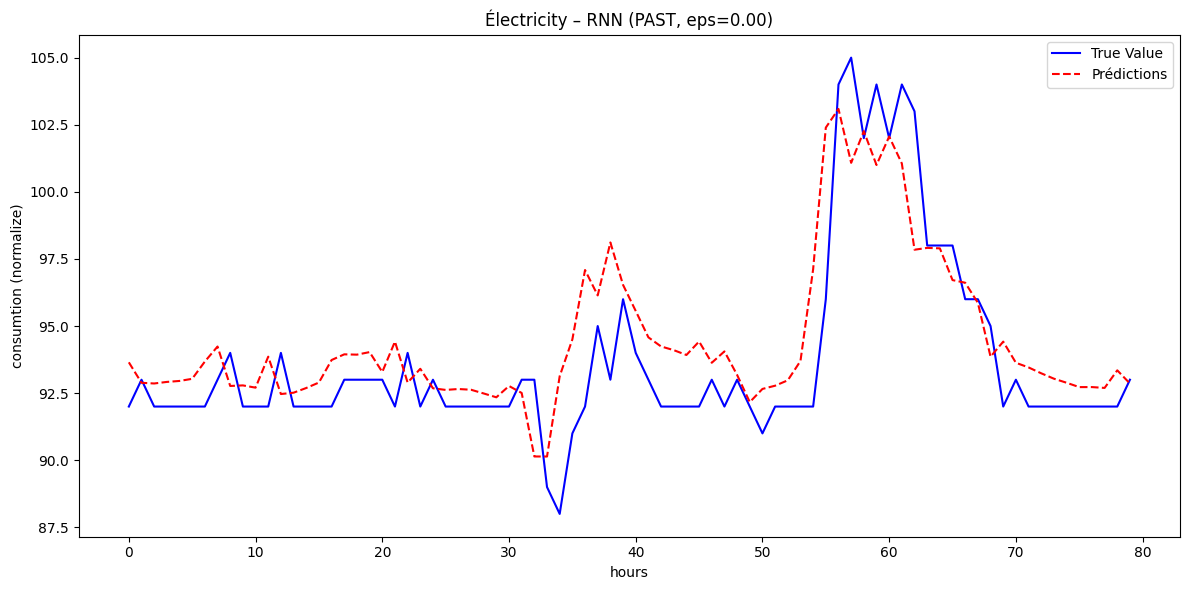

In [26]:
results_rev_rnn = evaluate_model_elec(model_rnn_rev, test_loader_rev, dates_rev, train_size_rev)

real_values_rev_rnn = results_rev_rnn['real_values']
predicted_values_rev_rnn = results_rev_rnn['predicted_values']
test_dates_rev_rnn = results_rev_rnn['test_dates']

true_values_denorm_rev_rnn = real_values_rev_rnn * (serie_max_rev - serie_min_rev) + serie_min_rev
predictions_denorm_rev_rnn = predicted_values_rev_rnn * (serie_max_rev - serie_min_rev) + serie_min_rev

log_and_plot_elec(
    true_values=true_values_denorm_rev_rnn[-n_hours:],
    predictions=predictions_denorm_rev_rnn[-n_hours:],
    model_name='RNN',
    attack_name='PAST',
    epsilon=0.00,
    res_tab=res_tab,
    similarity_fn=scalar_similarity,
    save_path=f"results/elec/SEED_{seed}/plots/PAST/0",
    save_png=True
)

RNN | REV – Epsilon 0.01 – MAE: 1.8775 | SIM: 0.9996


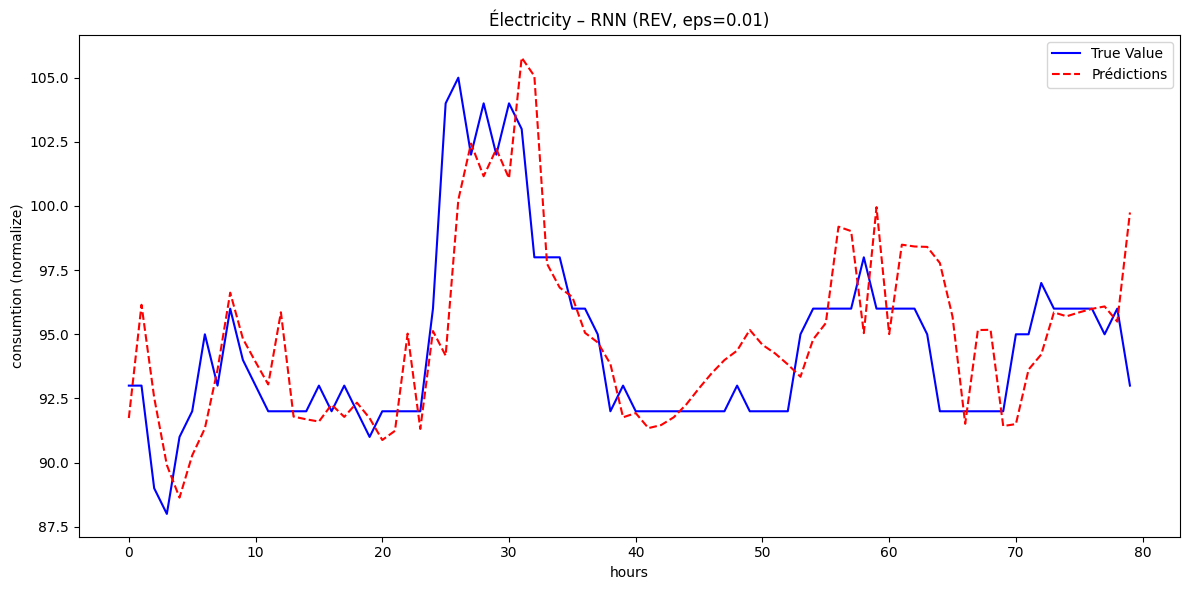

RNN | REV – Epsilon 0.02 – MAE: 3.0812 | SIM: 0.9992


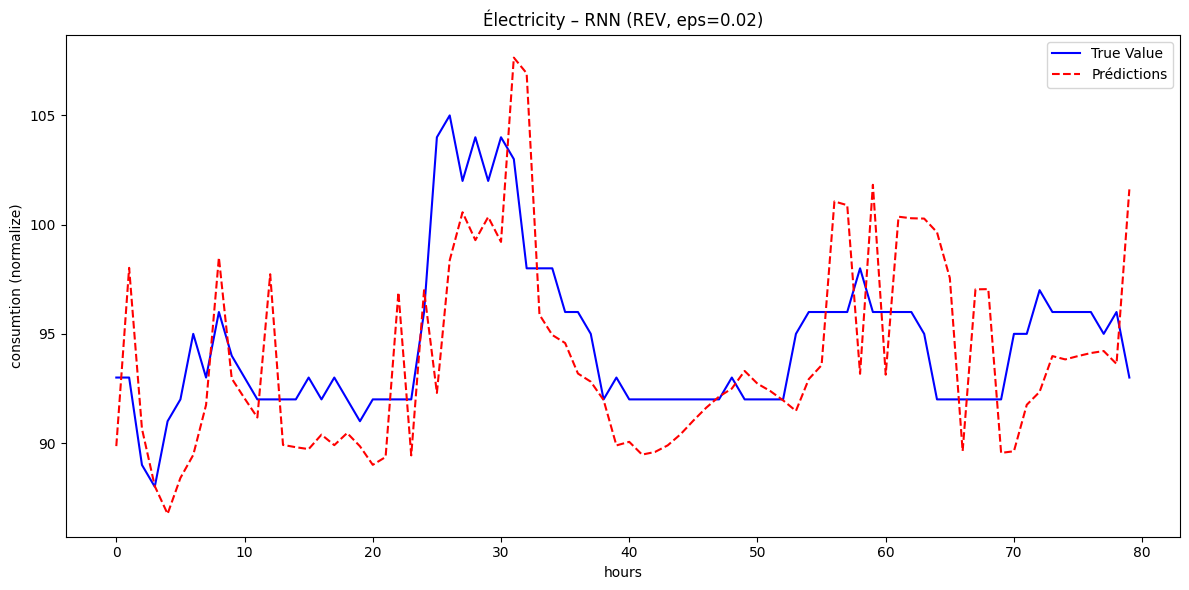

RNN | REV – Epsilon 0.03 – MAE: 4.8482 | SIM: 0.9985


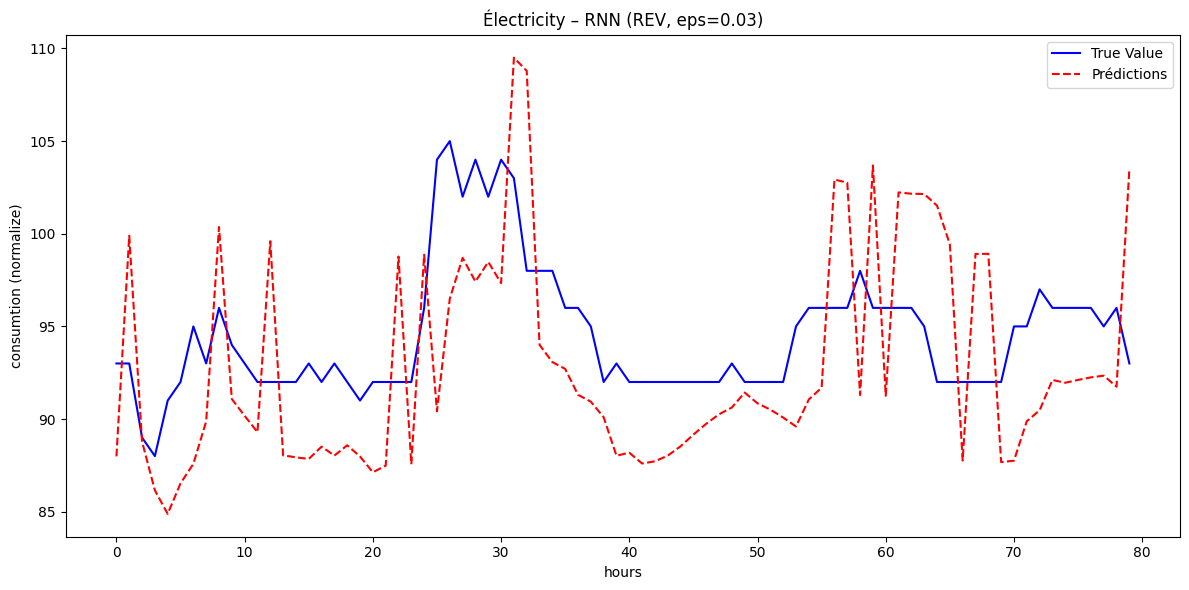

RNN | REV – Epsilon 0.04 – MAE: 6.7207 | SIM: 0.9974


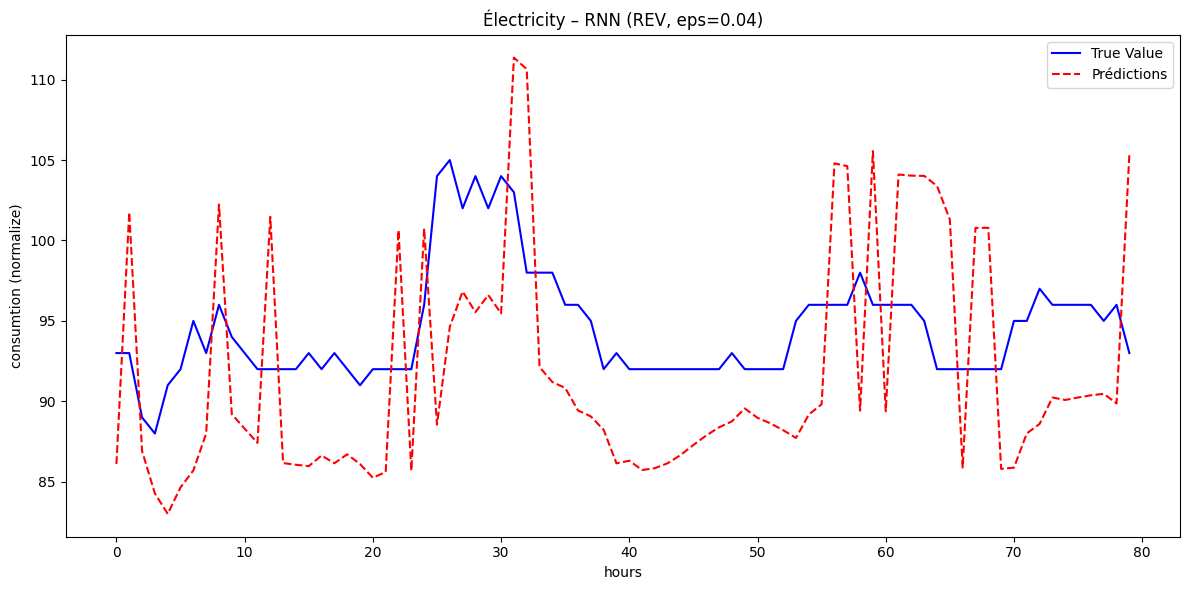

RNN | REV – Epsilon 0.05 – MAE: 8.5933 | SIM: 0.9961


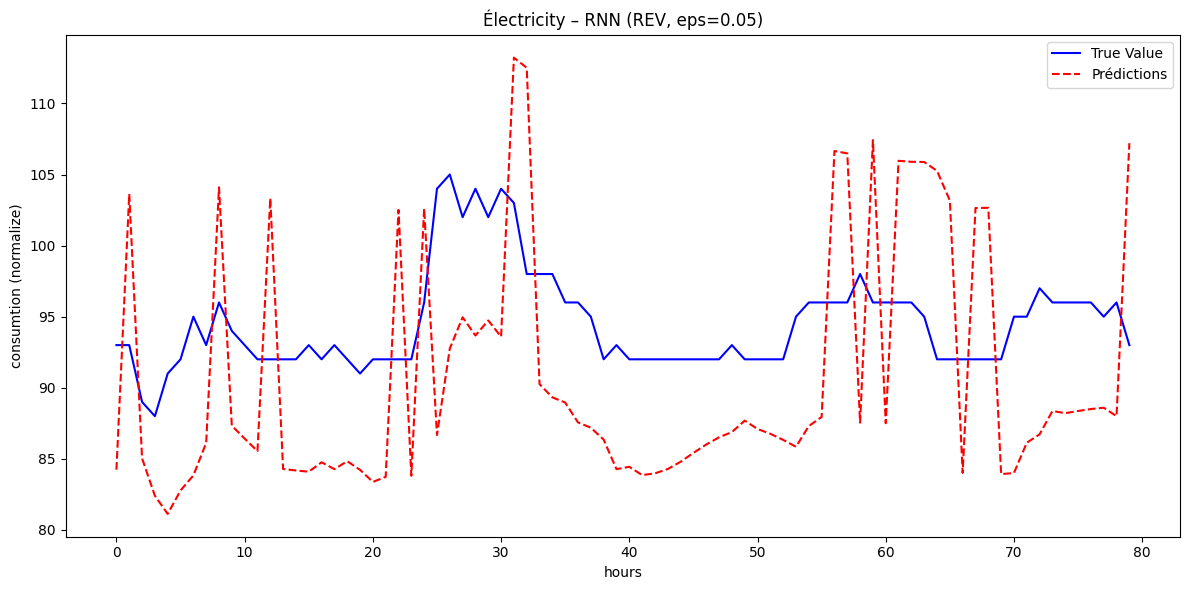

RNN | REV – Epsilon 0.07 – MAE: 13.2742 | SIM: 0.9910


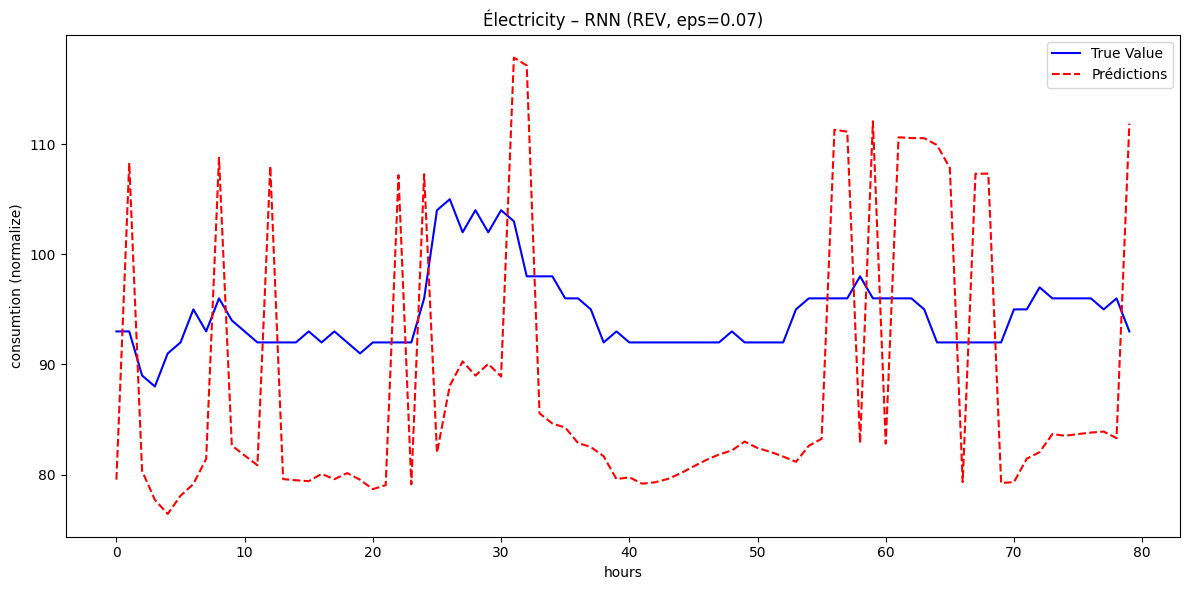

RNN | REV – Epsilon 0.10 – MAE: 17.9524 | SIM: 0.9835


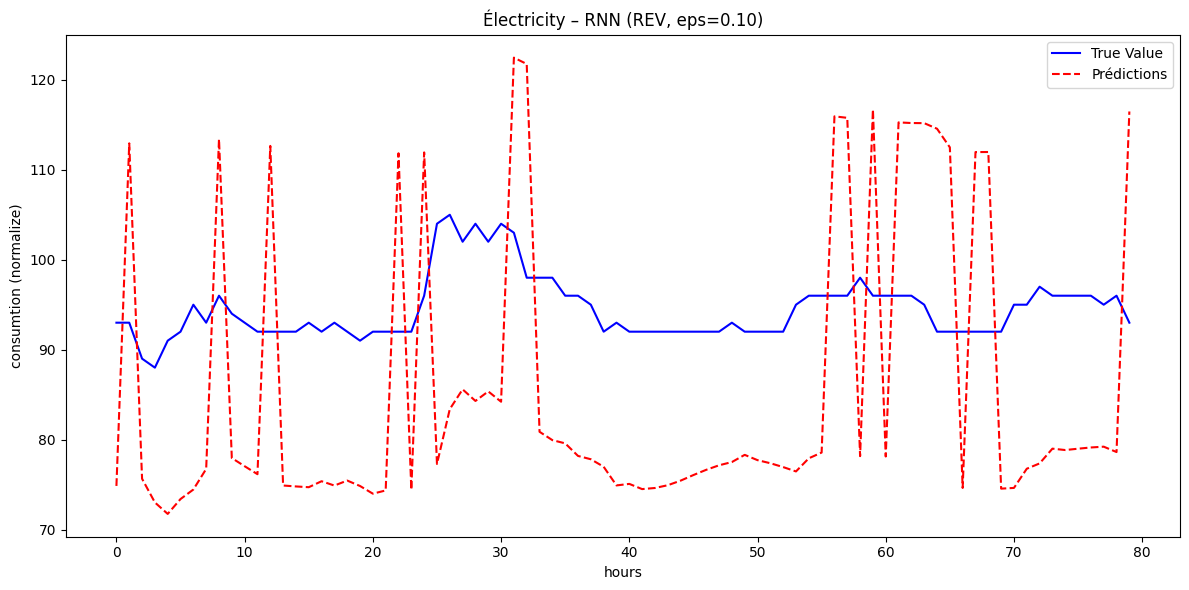

RNN | REV – Epsilon 0.20 – MAE: 36.5996 | SIM: 0.9238


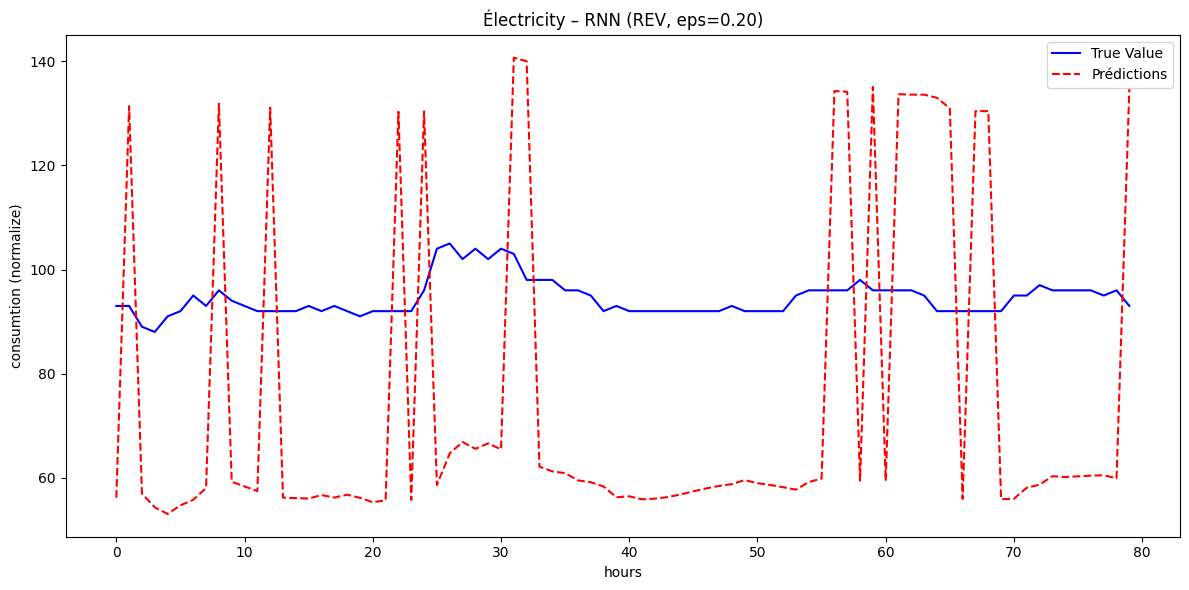

In [27]:
results = reverse_forecast_attack(
    model_rnn_rev, model_rnn,
    test_loader_rev, test_loader,
    epsilons,
    serie_min_rev, serie_max_rev
)

for esp, (true_vals, preds) in results.items():
  log_and_plot_elec(
      true_values=true_vals[-n_hours:],
      predictions=preds[-n_hours:],
      model_name='RNN',
      attack_name='REV',
      epsilon=esp,
      res_tab=res_tab,
      similarity_fn=scalar_similarity,
      save_path=f"results/elec/SEED_{seed}/plots/REV/{esp}",
      save_png=True
  )

In [28]:
from models.gru import SimpleGRU
model_gru = SimpleGRU(input_size=1, hidden_size=64, output_size=1, num_layers=2)
model_gru.to(device)
optimizer = torch.optim.Adam(model_gru.parameters(), lr=0.001)
train_models_elec(model_gru, loss_fn, optimizer, num_epochs, train_loader,device)

Epoch [1/30], Train Loss: 0.0069
Epoch [2/30], Train Loss: 0.0005
Epoch [3/30], Train Loss: 0.0005
Epoch [4/30], Train Loss: 0.0004
Epoch [5/30], Train Loss: 0.0004
Epoch [6/30], Train Loss: 0.0004
Epoch [7/30], Train Loss: 0.0004
Epoch [8/30], Train Loss: 0.0004
Epoch [9/30], Train Loss: 0.0004
Epoch [10/30], Train Loss: 0.0004
Epoch [11/30], Train Loss: 0.0004
Epoch [12/30], Train Loss: 0.0004
Epoch [13/30], Train Loss: 0.0004
Epoch [14/30], Train Loss: 0.0004
Epoch [15/30], Train Loss: 0.0004
Epoch [16/30], Train Loss: 0.0004
Epoch [17/30], Train Loss: 0.0004
Epoch [18/30], Train Loss: 0.0004
Epoch [19/30], Train Loss: 0.0004
Epoch [20/30], Train Loss: 0.0004
Epoch [21/30], Train Loss: 0.0004
Epoch [22/30], Train Loss: 0.0004
Epoch [23/30], Train Loss: 0.0004
Epoch [24/30], Train Loss: 0.0004
Epoch [25/30], Train Loss: 0.0004
Epoch [26/30], Train Loss: 0.0004
Epoch [27/30], Train Loss: 0.0004
Epoch [28/30], Train Loss: 0.0004
Epoch [29/30], Train Loss: 0.0004
Epoch [30/30], Train Lo

GRU | NA – Epsilon 0.00 – MAE: 1.4173 | SIM: 0.9998


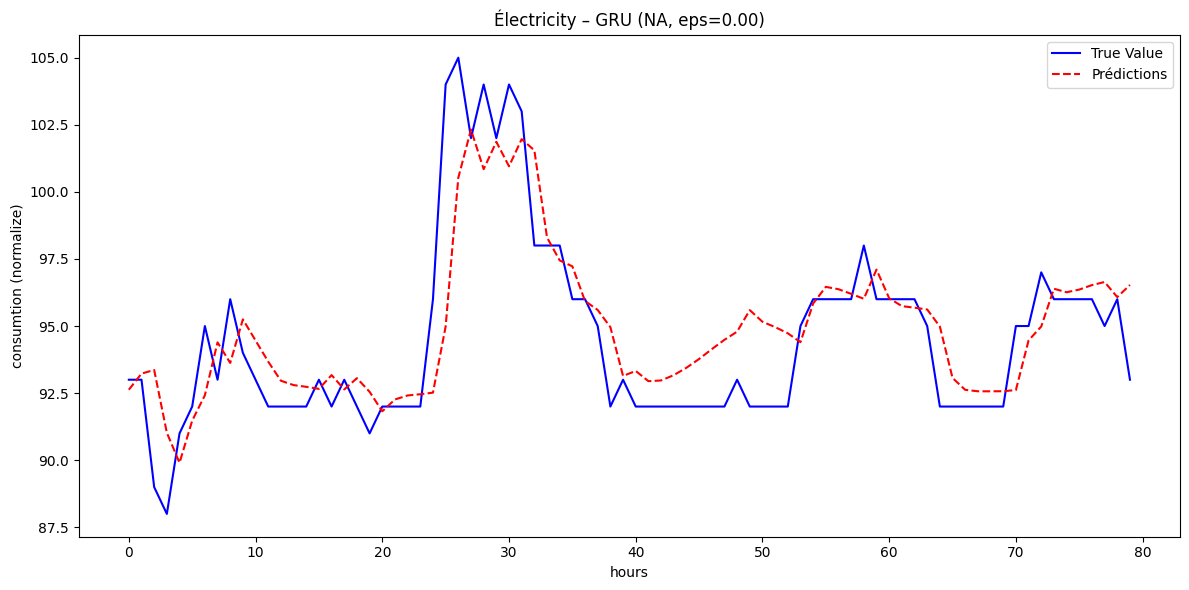

In [29]:
results_gru = evaluate_model_elec(model_gru, test_loader, dates, train_size)

real_values_gru = results_gru['real_values']
predicted_values_gru = results_gru['predicted_values']
test_dates_gru = results_gru['test_dates']

true_values_denorm_gru = real_values_gru * (serie_max - serie_min) + serie_min
predictions_denorm_gru = predicted_values_gru * (serie_max - serie_min) + serie_min

log_and_plot_elec(
    true_values=true_values_denorm_gru[-n_hours:],
    predictions=predictions_denorm_gru[-n_hours:],
    model_name='GRU',
    attack_name='NA',
    epsilon=0.00,
    res_tab=res_tab,
    similarity_fn=scalar_similarity,
    save_path=f"results/elec/SEED_{seed}/plots/PAST/0",
    save_png=True
)

In [30]:
model_gru_rev = SimpleGRU(input_size=1, hidden_size=64, output_size=1, num_layers=2)
model_gru_rev.to(device)
optimizer = torch.optim.Adam(model_gru_rev.parameters(), lr=0.001)
train_models_elec(model_gru_rev, loss_fn, optimizer, num_epochs, train_loader_rev,device)

Epoch [1/30], Train Loss: 0.0056
Epoch [2/30], Train Loss: 0.0005
Epoch [3/30], Train Loss: 0.0005
Epoch [4/30], Train Loss: 0.0004
Epoch [5/30], Train Loss: 0.0004
Epoch [6/30], Train Loss: 0.0004
Epoch [7/30], Train Loss: 0.0004
Epoch [8/30], Train Loss: 0.0004
Epoch [9/30], Train Loss: 0.0004
Epoch [10/30], Train Loss: 0.0004
Epoch [11/30], Train Loss: 0.0004
Epoch [12/30], Train Loss: 0.0004
Epoch [13/30], Train Loss: 0.0004
Epoch [14/30], Train Loss: 0.0004
Epoch [15/30], Train Loss: 0.0004
Epoch [16/30], Train Loss: 0.0004
Epoch [17/30], Train Loss: 0.0004
Epoch [18/30], Train Loss: 0.0004
Epoch [19/30], Train Loss: 0.0004
Epoch [20/30], Train Loss: 0.0004
Epoch [21/30], Train Loss: 0.0004
Epoch [22/30], Train Loss: 0.0004
Epoch [23/30], Train Loss: 0.0004
Epoch [24/30], Train Loss: 0.0004
Epoch [25/30], Train Loss: 0.0004
Epoch [26/30], Train Loss: 0.0004
Epoch [27/30], Train Loss: 0.0004
Epoch [28/30], Train Loss: 0.0004
Epoch [29/30], Train Loss: 0.0004
Epoch [30/30], Train Lo

GRU | PAST – Epsilon 0.00 – MAE: 1.3328 | SIM: 0.9998


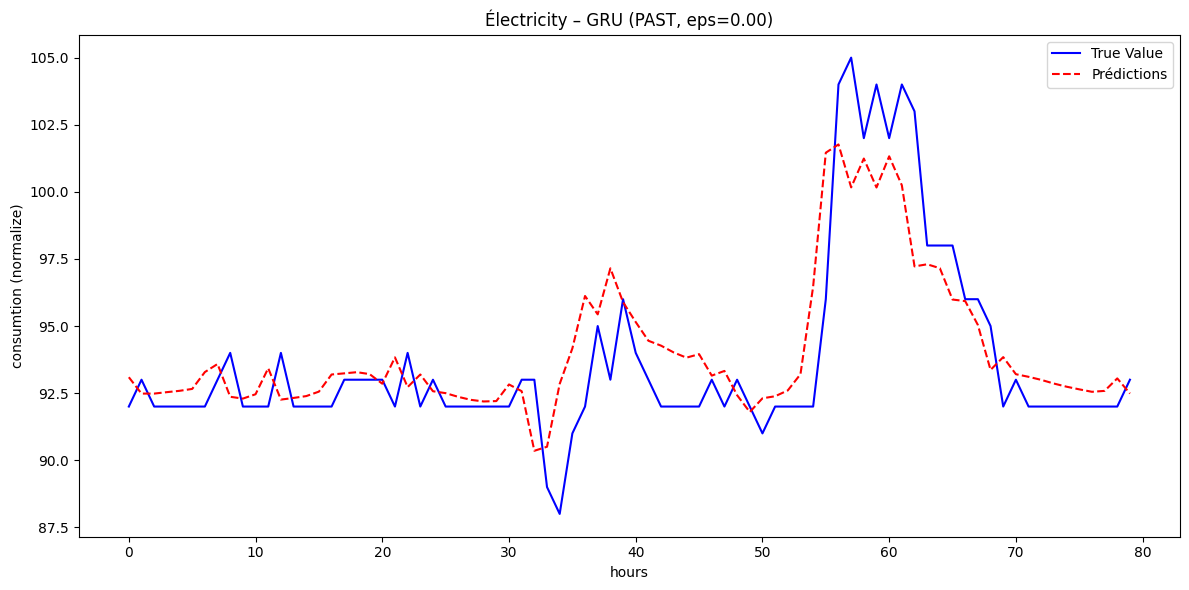

In [31]:
results_rev_gru = evaluate_model_elec(model_gru_rev, test_loader_rev, dates_rev, train_size_rev)

real_values_rev_gru = results_rev_gru['real_values']
predicted_values_rev_gru = results_rev_gru['predicted_values']
test_dates_rev_gru = results_rev_gru['test_dates']

true_values_denorm_rev_gru = real_values_rev_gru * (serie_max_rev - serie_min_rev) + serie_min_rev
predictions_denorm_rev_gru = predicted_values_rev_gru * (serie_max_rev - serie_min_rev) + serie_min_rev

log_and_plot_elec(
    true_values=true_values_denorm_rev_gru[-n_hours:],
    predictions=predictions_denorm_rev_gru[-n_hours:],
    model_name='GRU',
    attack_name='PAST',
    epsilon=0.00,
    res_tab=res_tab,
    similarity_fn=scalar_similarity,
    save_path=f"results/elec/SEED_{seed}/plots/PAST/0",
    save_png=True
)

GRU | REV – Epsilon 0.01 – MAE: 2.4659 | SIM: 0.9994


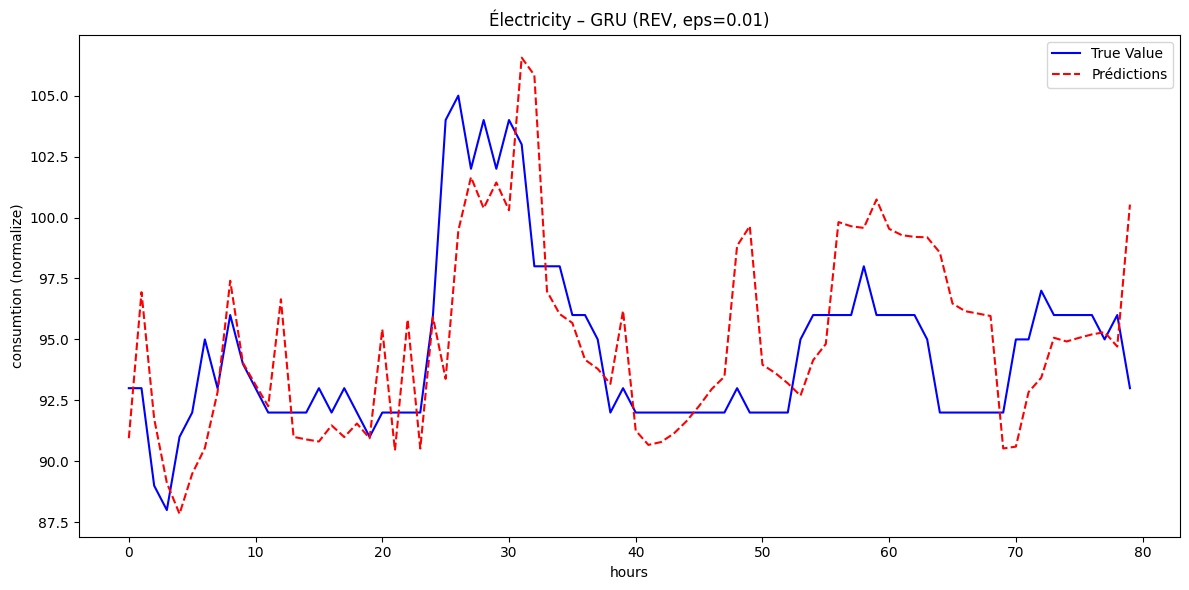

GRU | REV – Epsilon 0.02 – MAE: 4.7622 | SIM: 0.9984


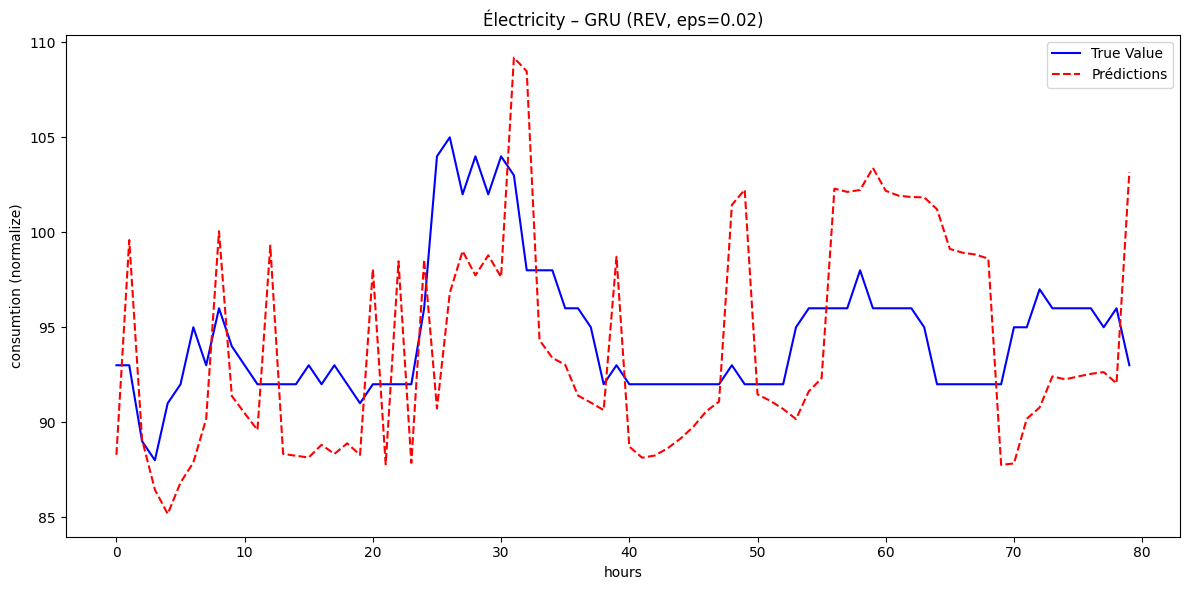

GRU | REV – Epsilon 0.03 – MAE: 7.3861 | SIM: 0.9966


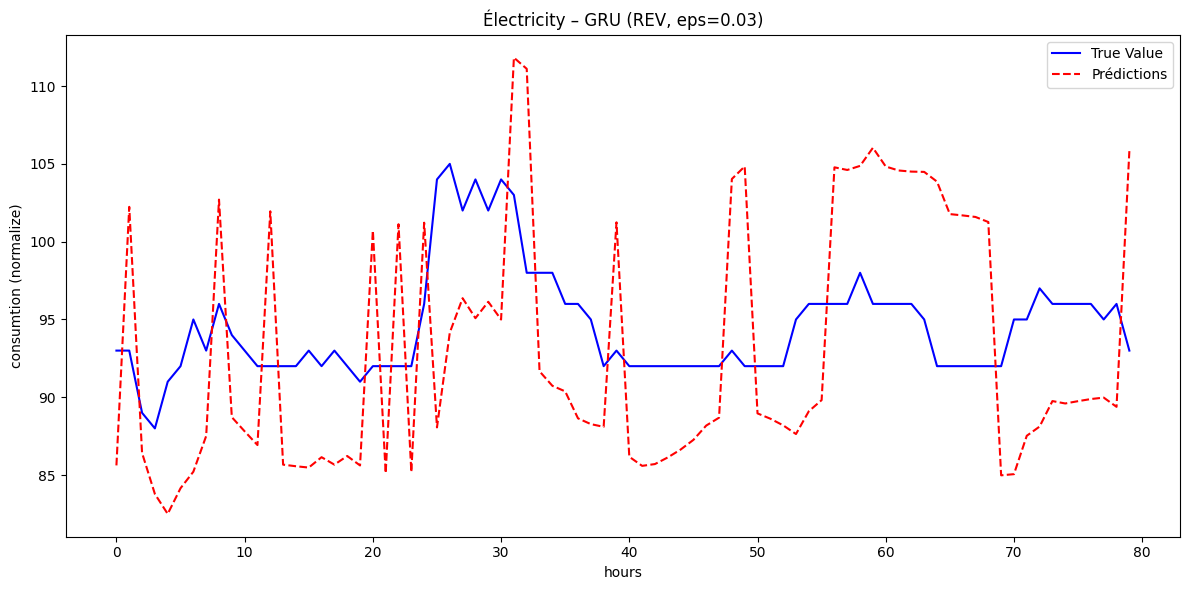

GRU | REV – Epsilon 0.04 – MAE: 10.0083 | SIM: 0.9941


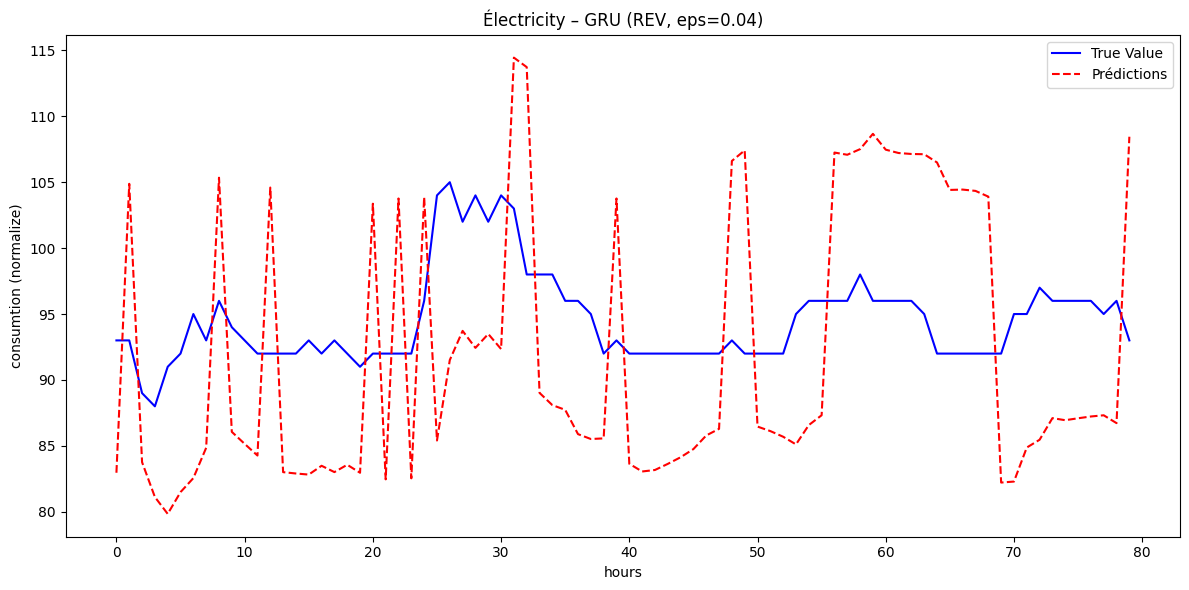

GRU | REV – Epsilon 0.05 – MAE: 12.6251 | SIM: 0.9909


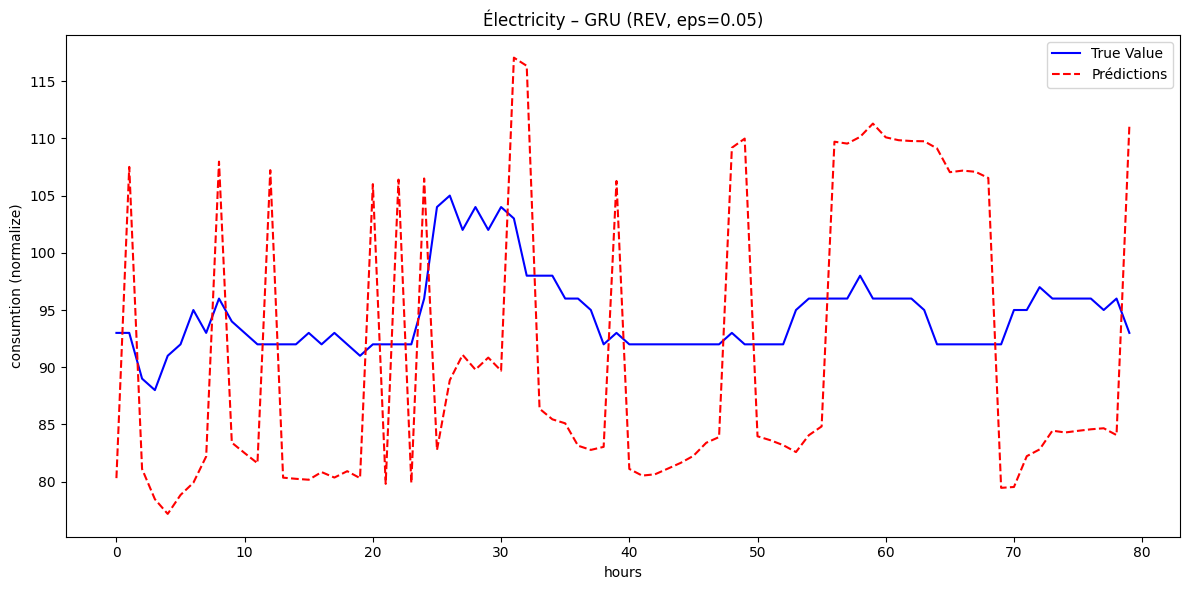

GRU | REV – Epsilon 0.07 – MAE: 19.1333 | SIM: 0.9792


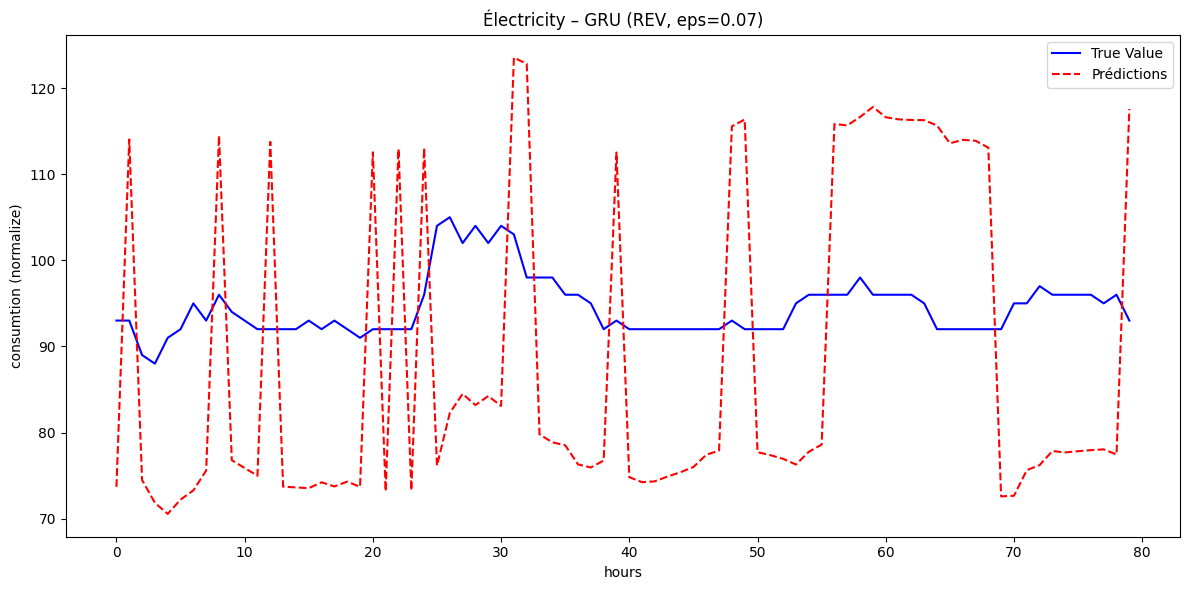

GRU | REV – Epsilon 0.10 – MAE: 25.5749 | SIM: 0.9625


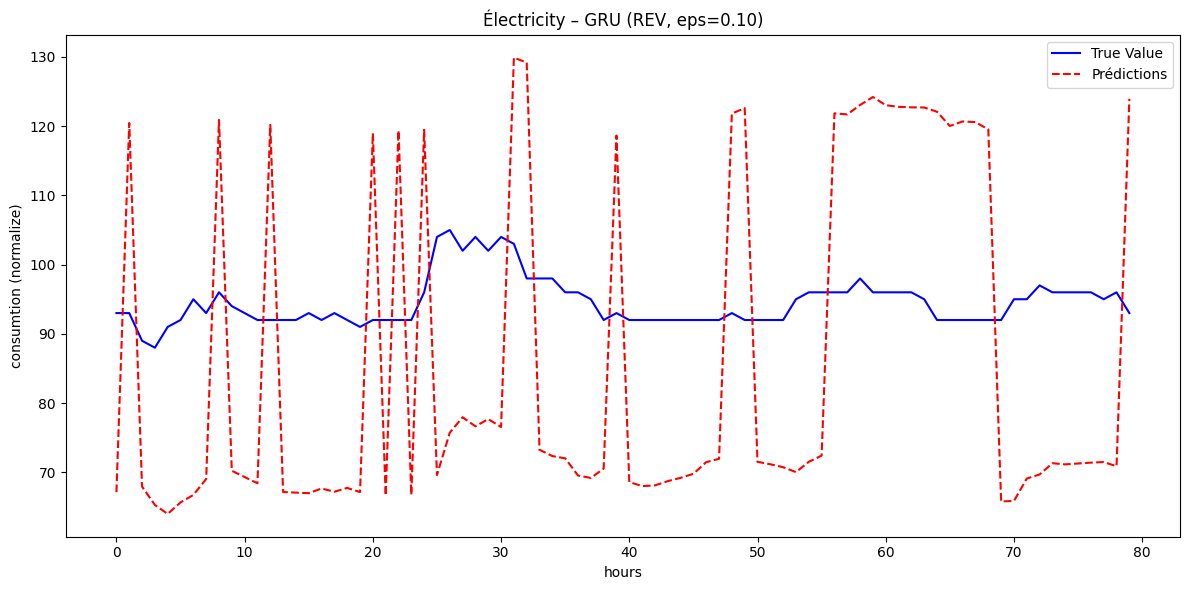

GRU | REV – Epsilon 0.20 – MAE: 50.3181 | SIM: 0.8519


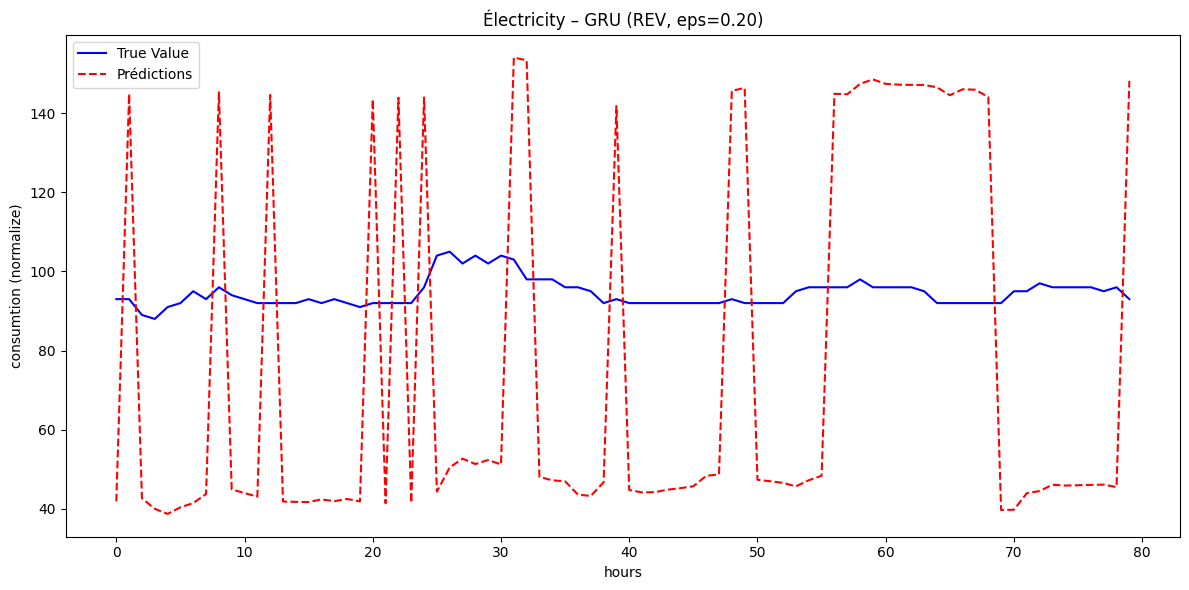

In [32]:
results = reverse_forecast_attack(
    model_gru_rev, model_rnn,
    test_loader_rev, test_loader,
    epsilons,
    serie_min_rev, serie_max_rev
)

for esp, (true_vals, preds) in results.items():
  log_and_plot_elec(
      true_values=true_vals[-n_hours:],
      predictions=preds[-n_hours:],
      model_name='GRU',
      attack_name='REV',
      epsilon=esp,
      res_tab=res_tab,
      similarity_fn=scalar_similarity,
      save_path=f"results/elec/SEED_{seed}/plots/REV/{esp}",
      save_png=True
  )

In [33]:
display(res_tab)

Attack              NA      PAST       REV                                 \
ε                 0.00      0.00      0.01      0.02      0.03       0.04   
Model Metric                                                                
LSTM  MAE     1.580212  1.358286  2.847092  4.487642  6.545673   8.694085   
      RMSE    2.118119  1.961298  3.301107  5.010583  6.896636   9.098038   
      SIM     0.999774  0.999800  0.999543  0.998850  0.998154   0.996407   
RNN   MAE     2.011900  1.471915  1.877487  3.081242  4.848162   6.720698   
      RMSE    2.449172  2.005250  2.574451  3.776596  5.376527   7.110757   
      SIM     0.999781  0.999808  0.999640  0.999216  0.998492   0.997448   
GRU   MAE     1.417306  1.332837  2.465941  4.762157  7.386067  10.008288   
      RMSE    2.008528  1.888515  3.225765  5.350692  7.787122  10.313426   
      SIM     0.999783  0.999805  0.999434  0.998401  0.996650   0.994149   

Attack                                                    
ε                  0.05       0.07       0.10       0.20  
Model Metric                                              
LSTM  MAE     11.248319  16.739714  21.961461  38.360962  
      RMSE    11.713782  17.265378  22.670161  39.716961  
      SIM      0.994509   0.989532   0.984862   0.965235  
RNN   MAE      8.593297  13.274157  17.952431  36.599560  
      RMSE     8.901125  13.474168  18.099435  36.667393  
      SIM      0.996068   0.991027   0.983492   0.923812  
GRU   MAE     12.625121  19.133328  25.574922  50.318114  
      RMSE    12.872905  19.305406  25.709693  50.398179  
      SIM      0.990874   0.979193   0.962463   0.851885

In [34]:
from attack.fgsm import fgsm_attack

In [35]:
# Creation of the tab result for plotting adversial attack result
models = ['LSTM','RNN','GRU']
metrics = ['MAE', "RMSE", 'SIM']

row_index = pd.MultiIndex.from_product([models, metrics], names=['Model', 'Metric'])

attacks = ['FGSM']
epsilons_attack = {
    'FGSM':[0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1, 0.2],
}

col_tuples = []
for atk, eps_list in epsilons_attack.items():
    for eps in eps_list:
        col_tuples.append((atk, f"{eps:.2f}"))

col_index = pd.MultiIndex.from_tuples(col_tuples, names=['Attack', 'ε'])

res_tab_fgsm = pd.DataFrame(index=row_index, columns=col_index, dtype=float)

print(res_tab_fgsm)

Attack       FGSM                                   
ε            0.01 0.02 0.03 0.04 0.05 0.07 0.10 0.20
Model Metric                                        
LSTM  MAE     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      RMSE    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      SIM     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
RNN   MAE     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      RMSE    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      SIM     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
GRU   MAE     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      RMSE    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      SIM     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN


In [36]:
import sys

if 'fgsm_attack' in globals():
    del globals()['fgsm_attack']

module_name = 'attack.fgsm'
if module_name in sys.modules:
    del sys.modules[module_name]

from attack.fgsm import fgsm_attack

GRU | FGSM – Epsilon 0.01 – MAE: 3.8755 | SIM: 0.9992


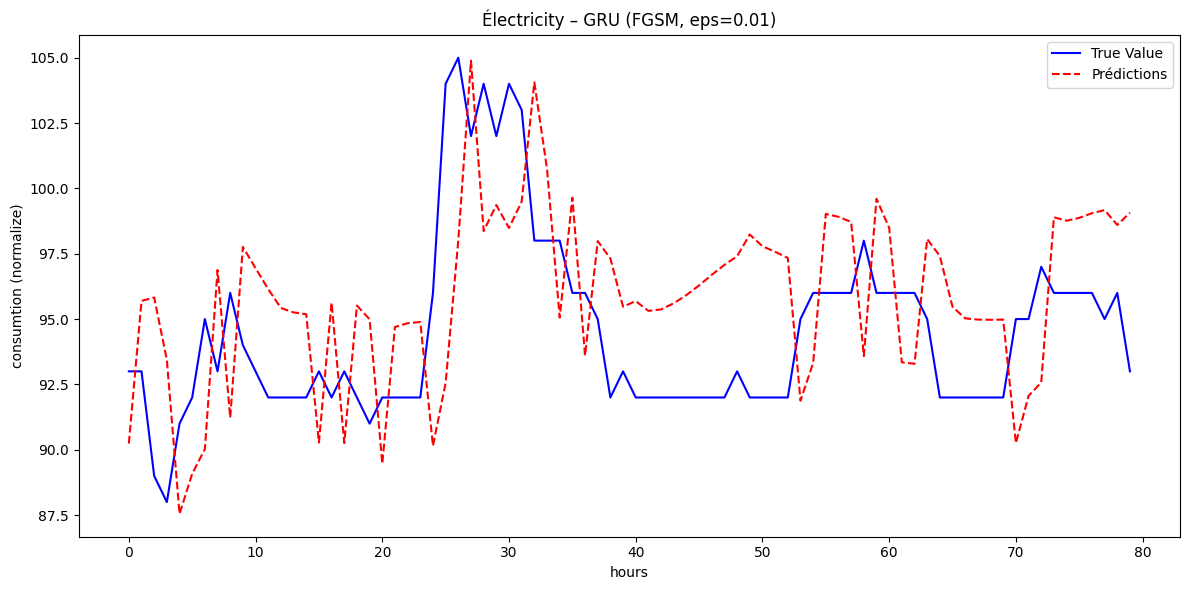

LSTM | FGSM – Epsilon 0.01 – MAE: 3.9570 | SIM: 0.9992


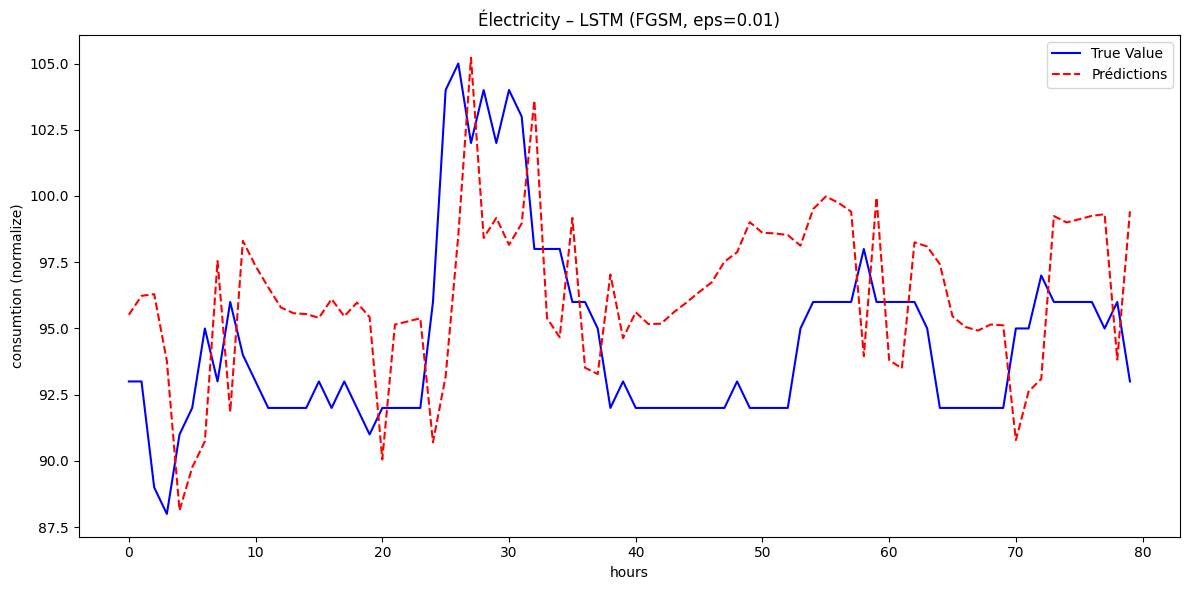

RNN | FGSM – Epsilon 0.01 – MAE: 4.8799 | SIM: 0.9993


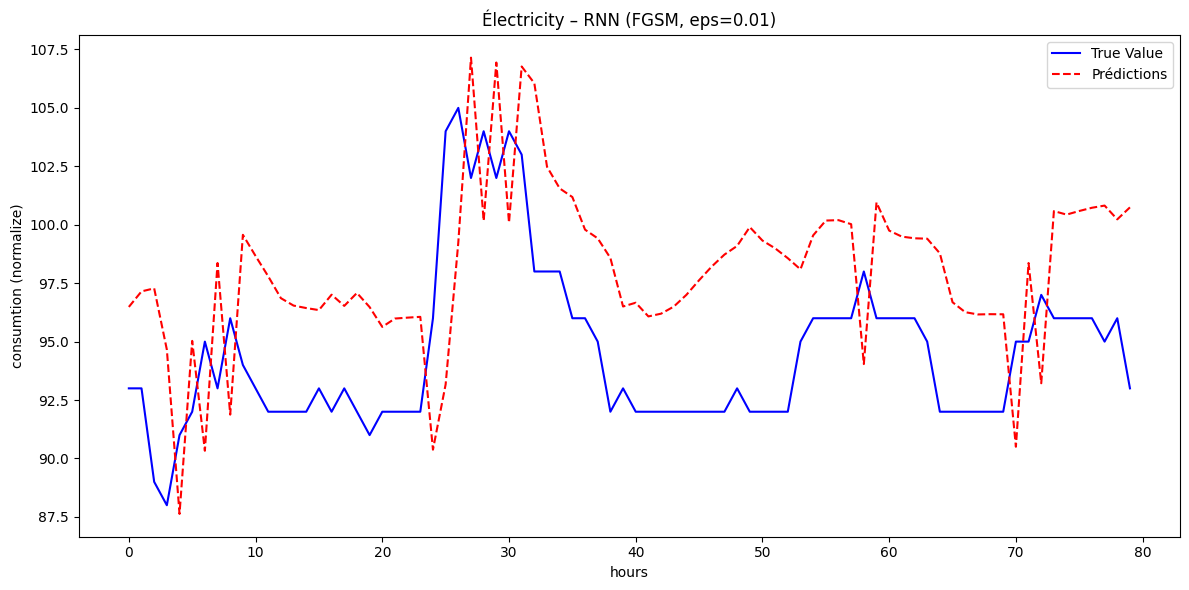

GRU | FGSM – Epsilon 0.02 – MAE: 6.3476 | SIM: 0.9980


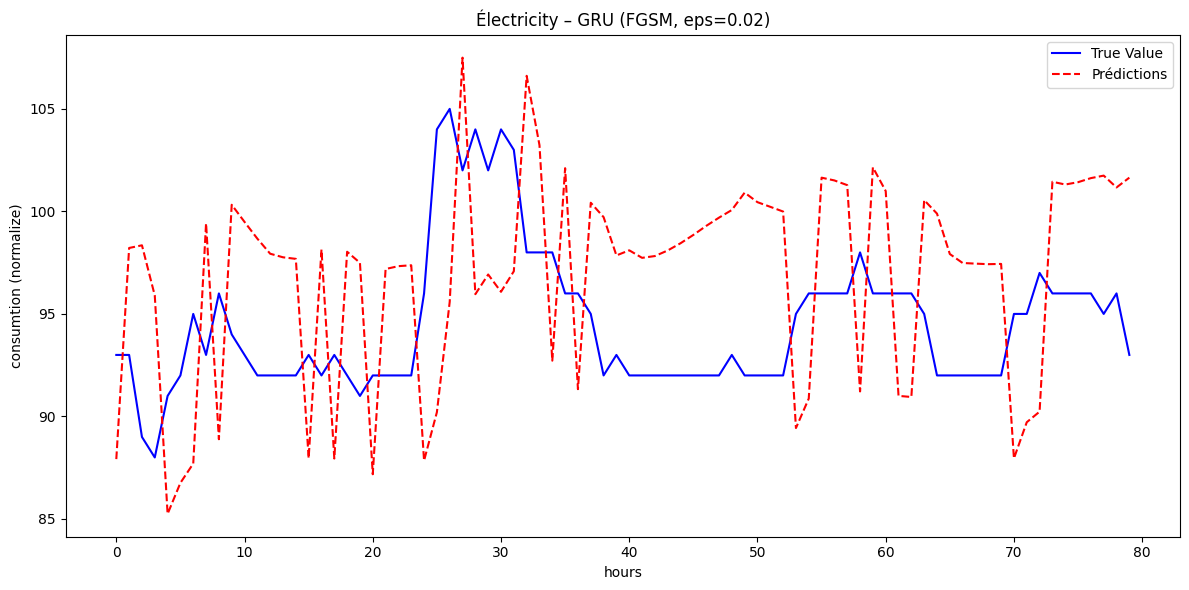

LSTM | FGSM – Epsilon 0.02 – MAE: 6.3516 | SIM: 0.9981


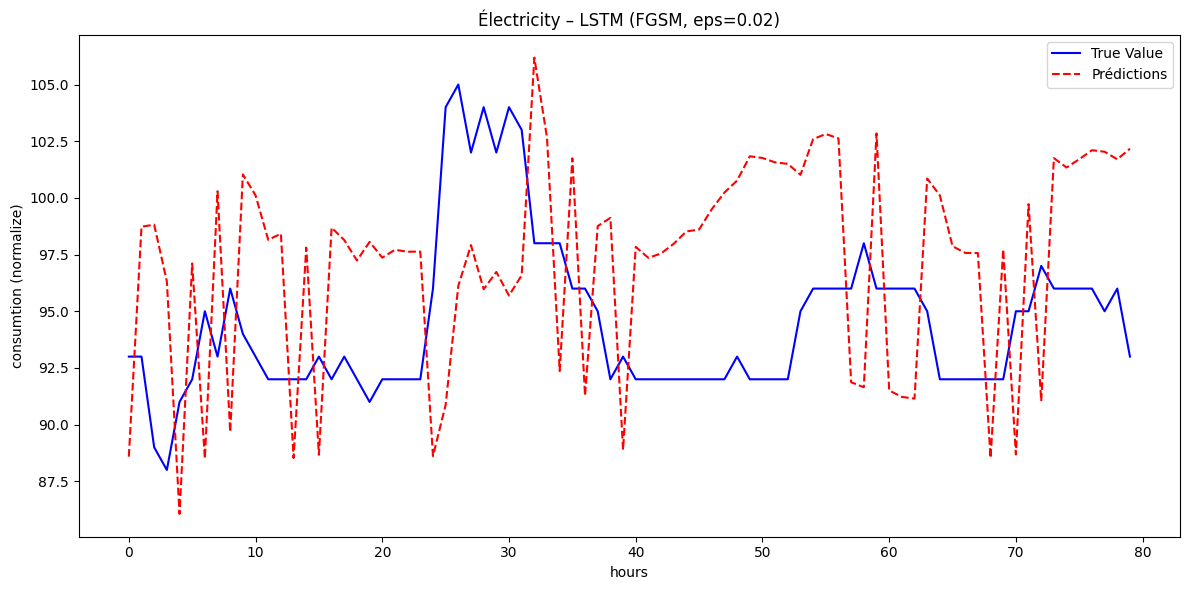

RNN | FGSM – Epsilon 0.02 – MAE: 7.7433 | SIM: 0.9984


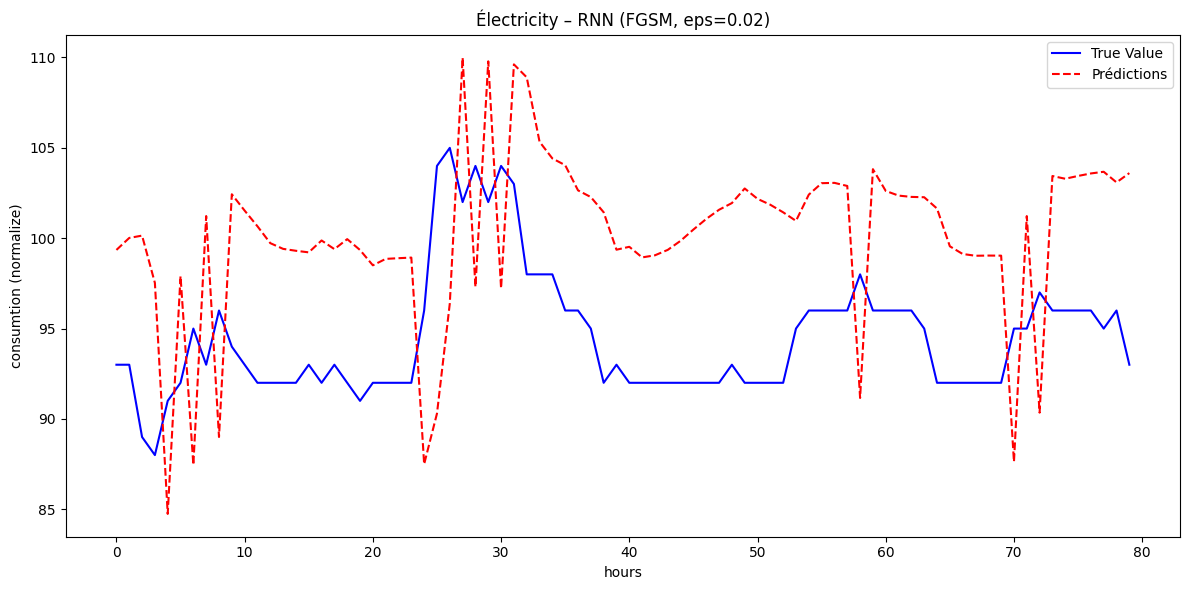

GRU | FGSM – Epsilon 0.03 – MAE: 8.8248 | SIM: 0.9964


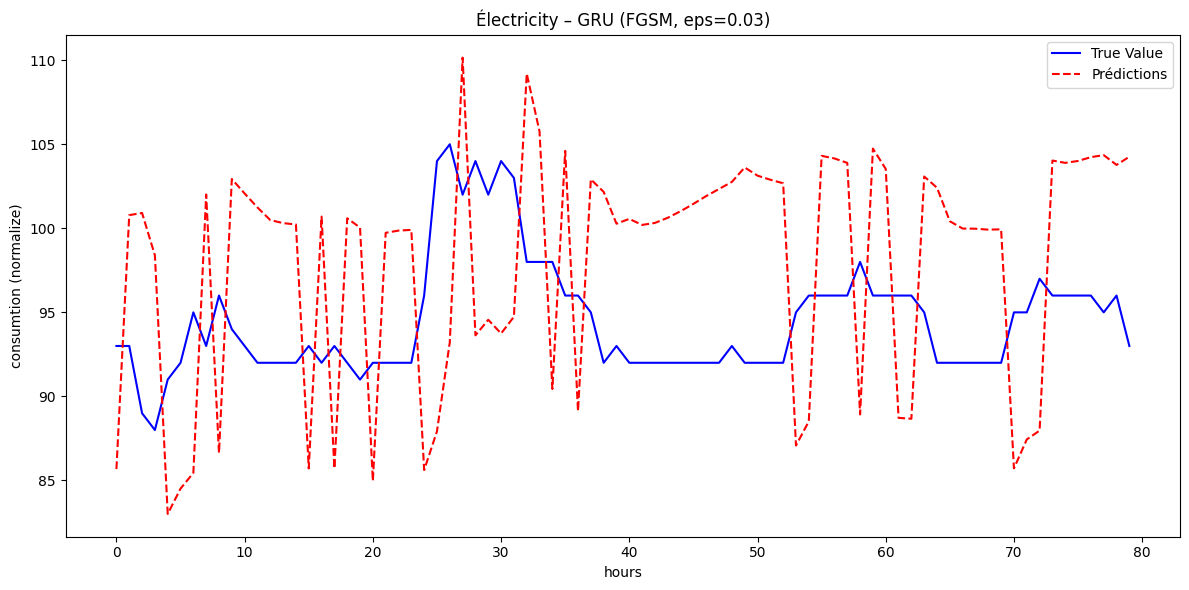

LSTM | FGSM – Epsilon 0.03 – MAE: 8.9100 | SIM: 0.9970


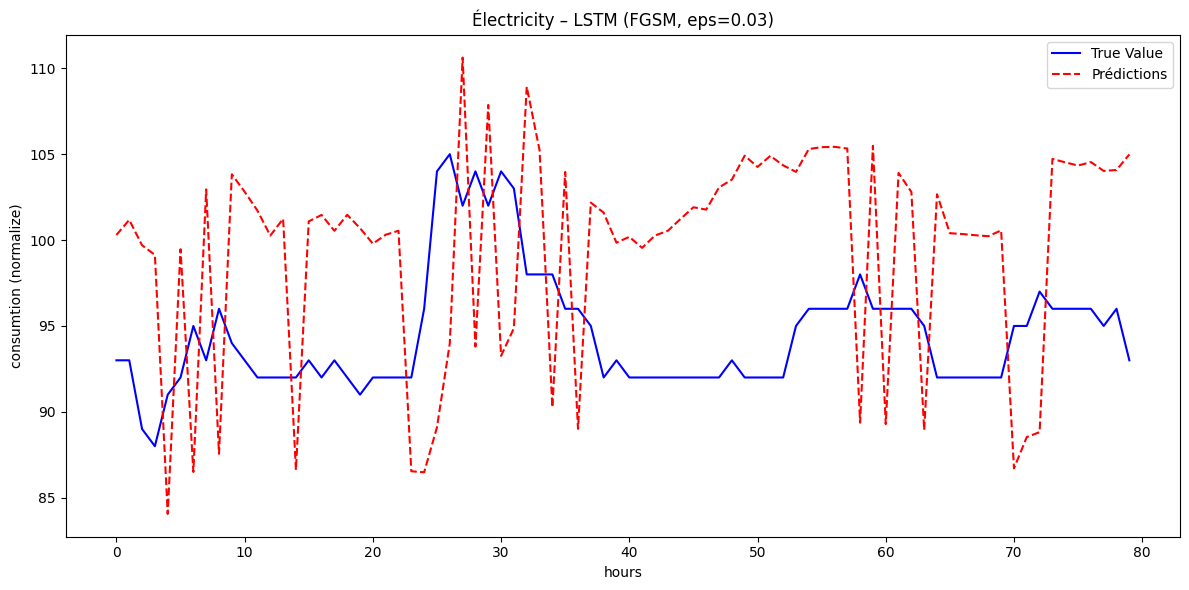

RNN | FGSM – Epsilon 0.03 – MAE: 10.6001 | SIM: 0.9972


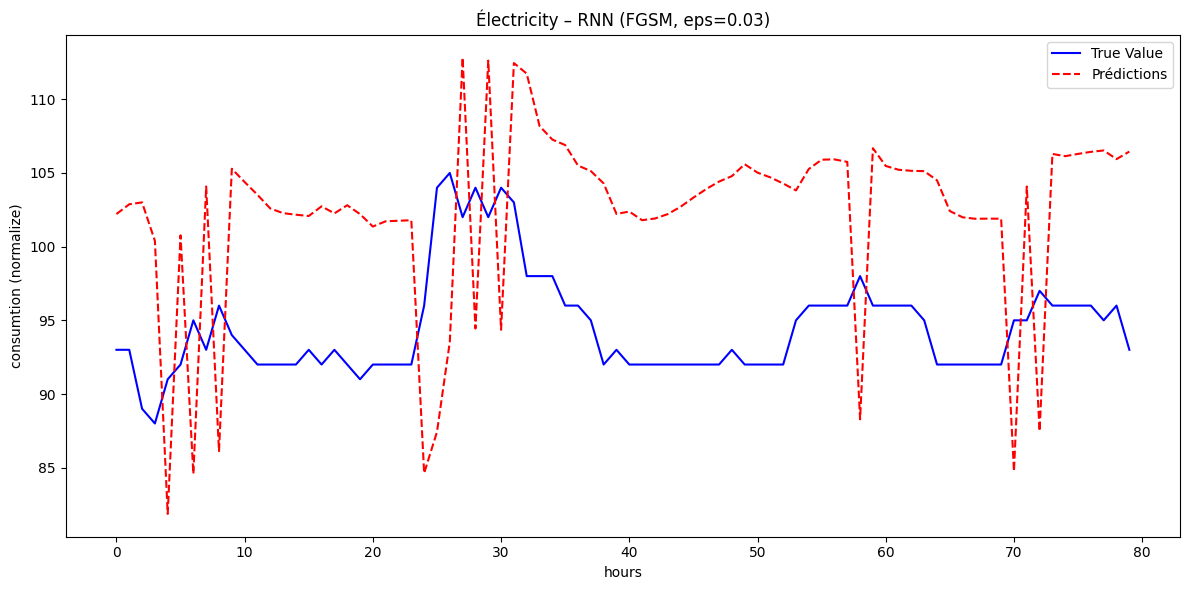

GRU | FGSM – Epsilon 0.04 – MAE: 11.2982 | SIM: 0.9943


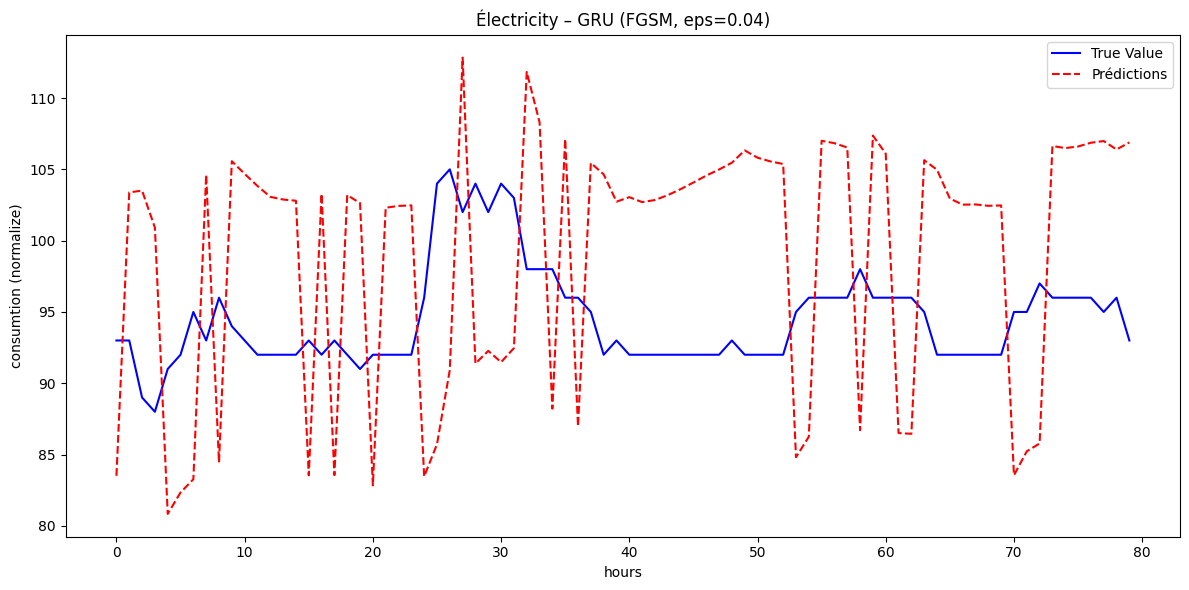

LSTM | FGSM – Epsilon 0.04 – MAE: 11.3645 | SIM: 0.9951


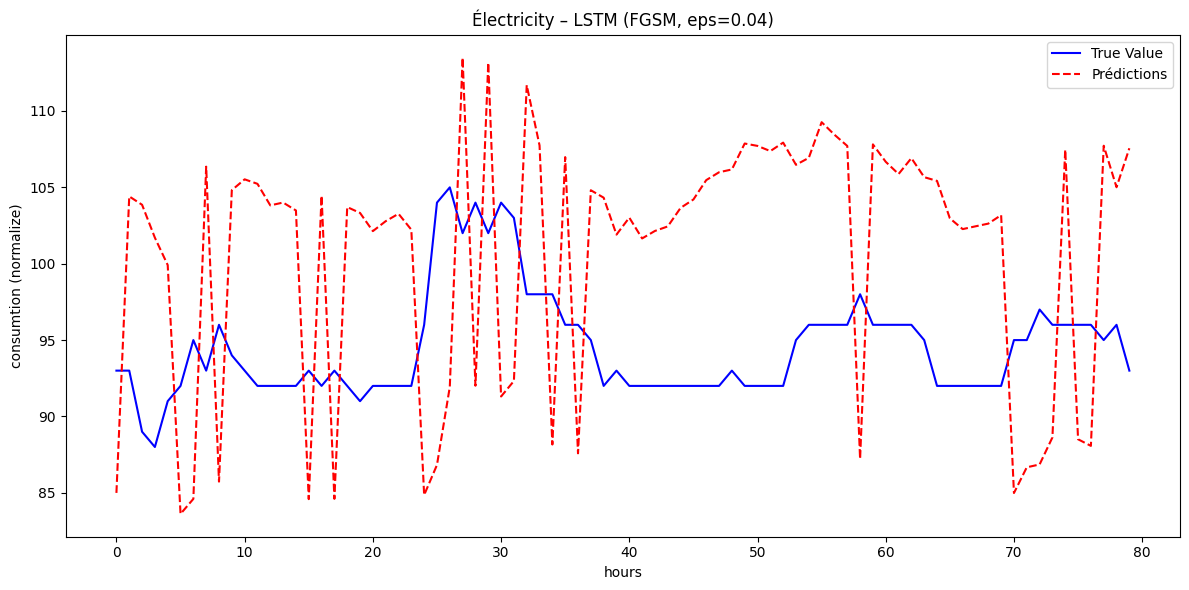

RNN | FGSM – Epsilon 0.04 – MAE: 13.4482 | SIM: 0.9958


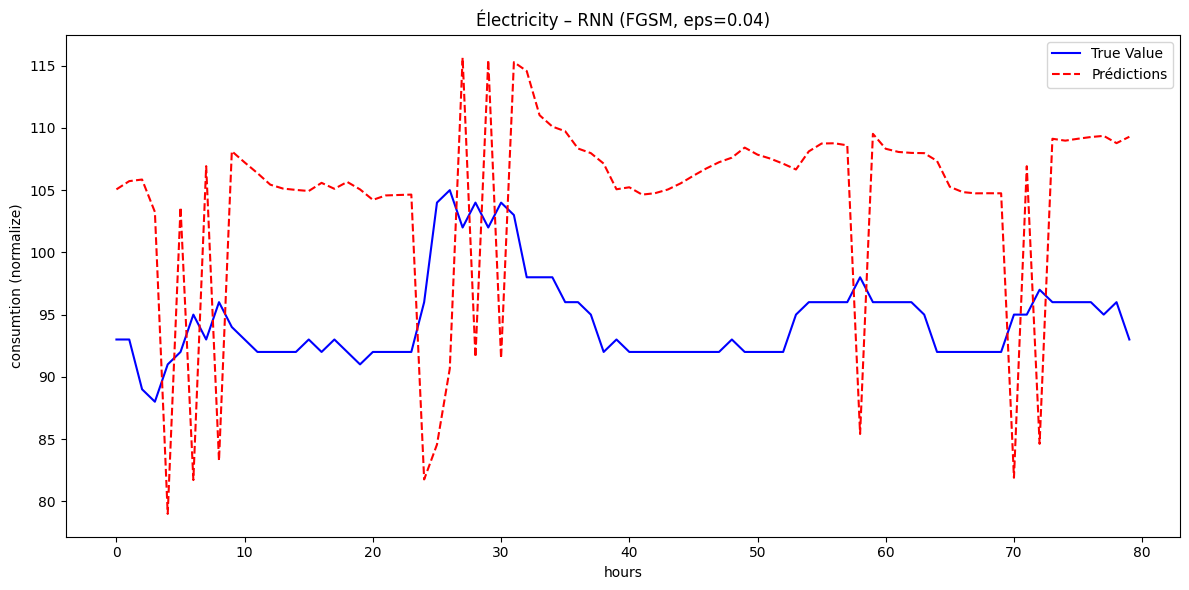

GRU | FGSM – Epsilon 0.05 – MAE: 13.7594 | SIM: 0.9919


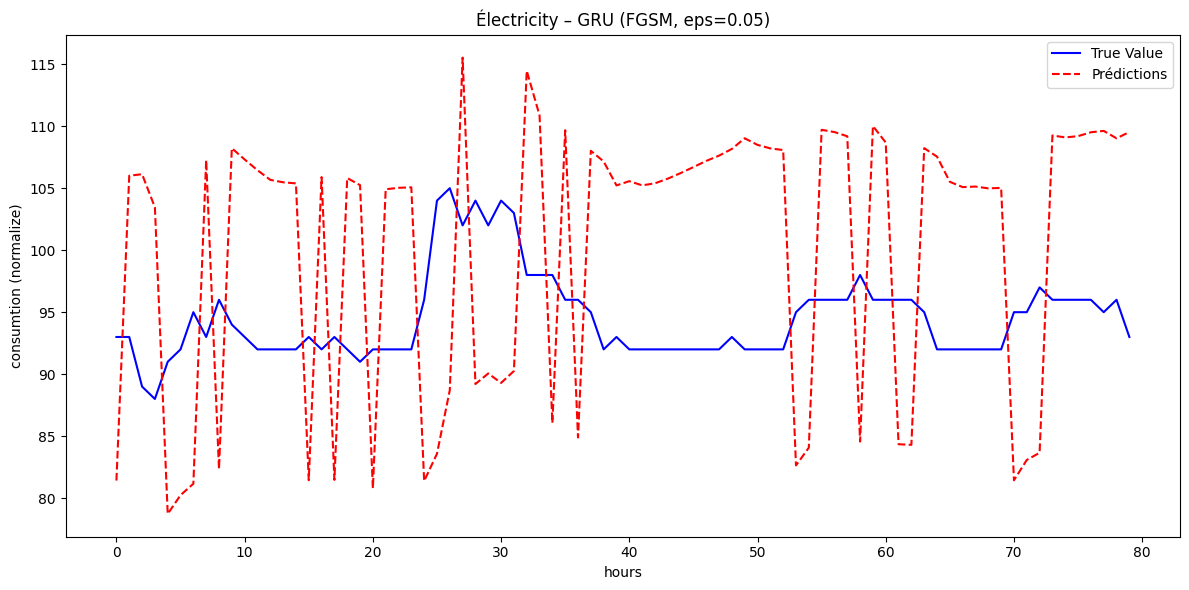

LSTM | FGSM – Epsilon 0.05 – MAE: 13.8761 | SIM: 0.9927


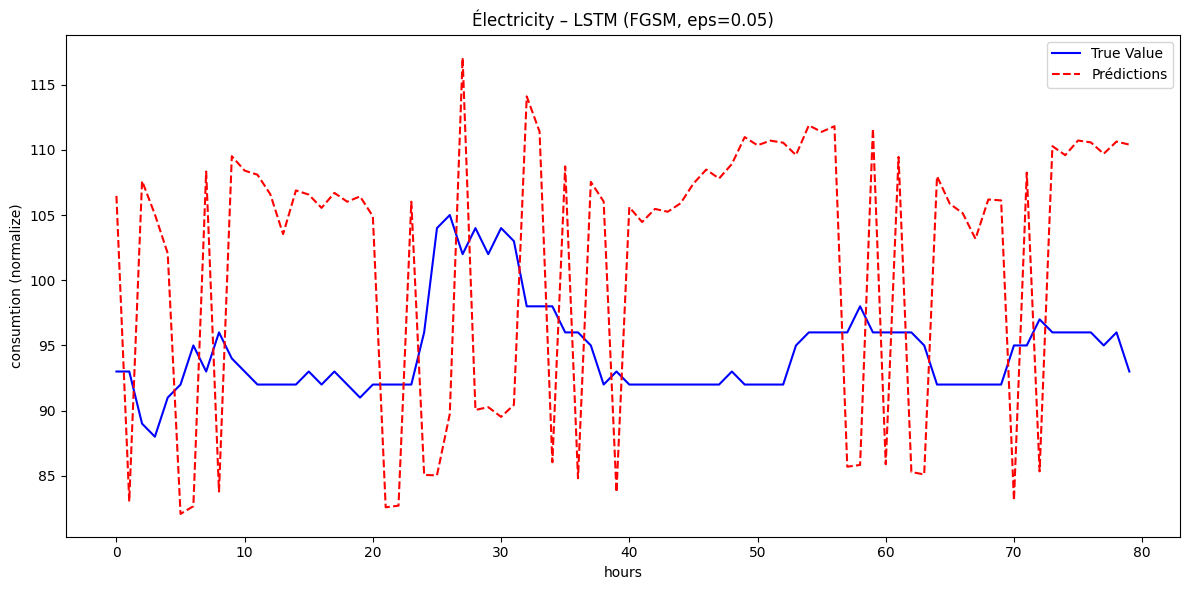

RNN | FGSM – Epsilon 0.05 – MAE: 16.2859 | SIM: 0.9941


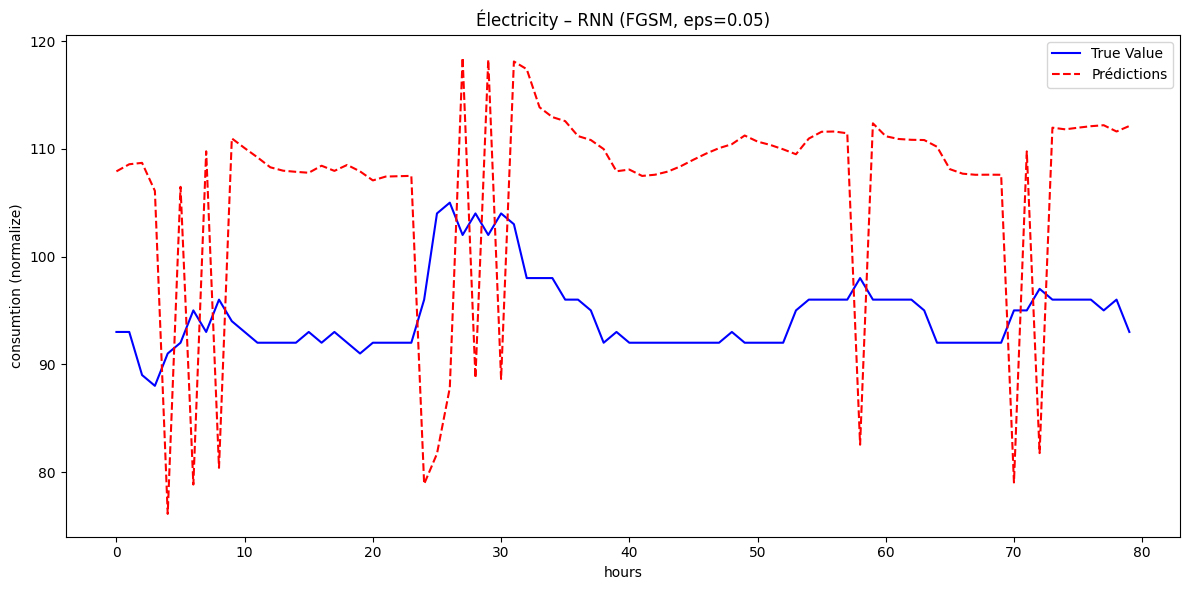

GRU | FGSM – Epsilon 0.07 – MAE: 19.8101 | SIM: 0.9847


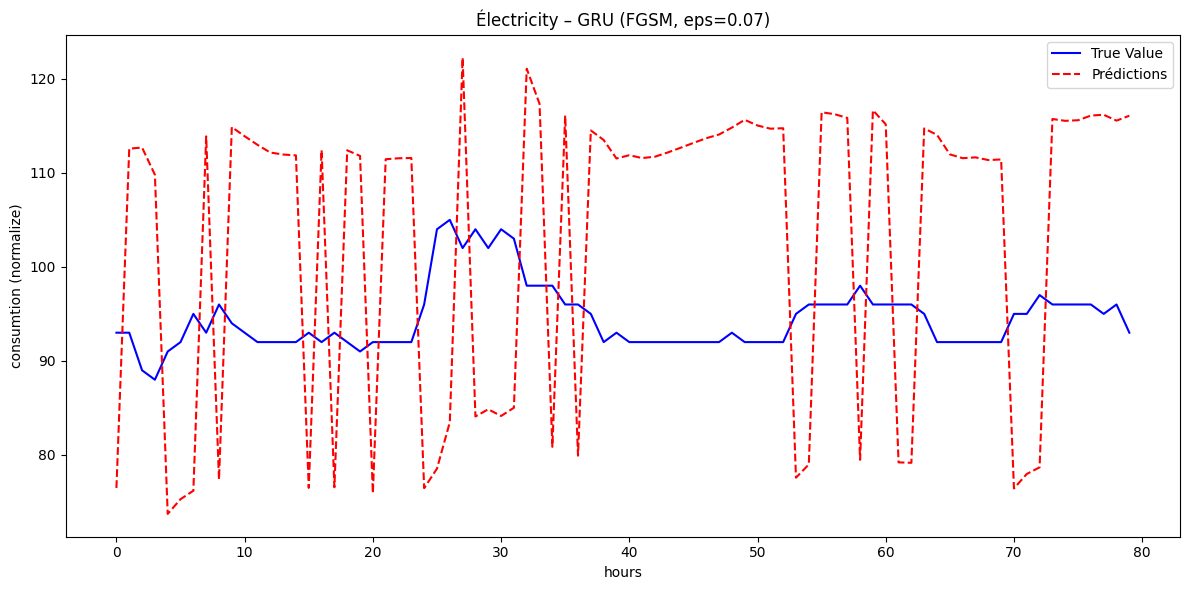

LSTM | FGSM – Epsilon 0.07 – MAE: 20.5423 | SIM: 0.9879


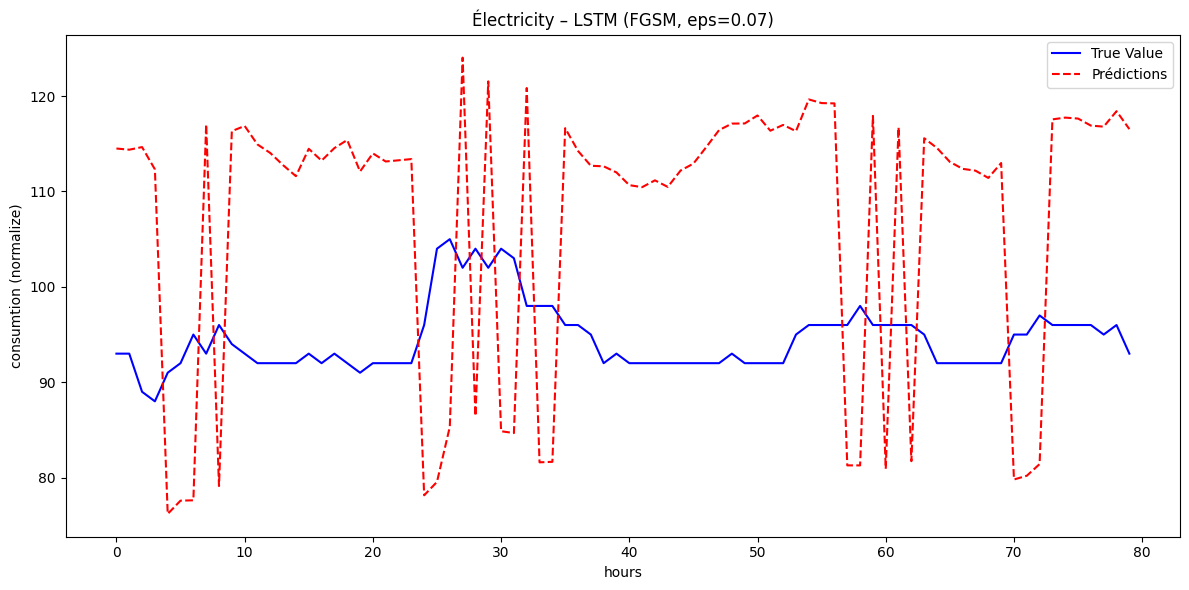

RNN | FGSM – Epsilon 0.07 – MAE: 23.3221 | SIM: 0.9892


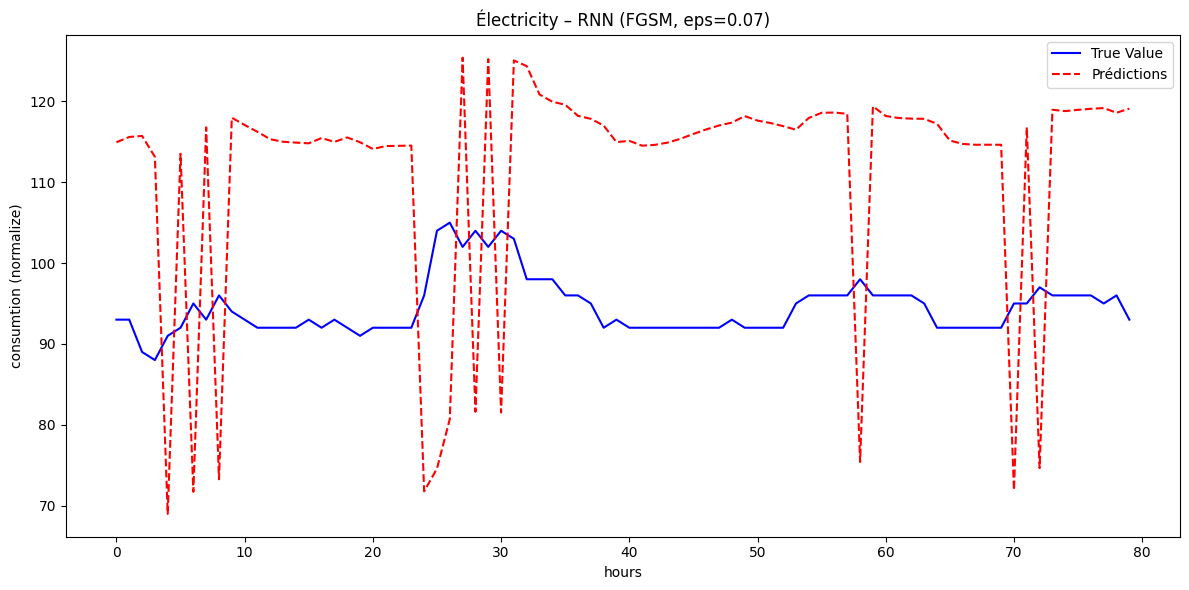

GRU | FGSM – Epsilon 0.10 – MAE: 25.6431 | SIM: 0.9765


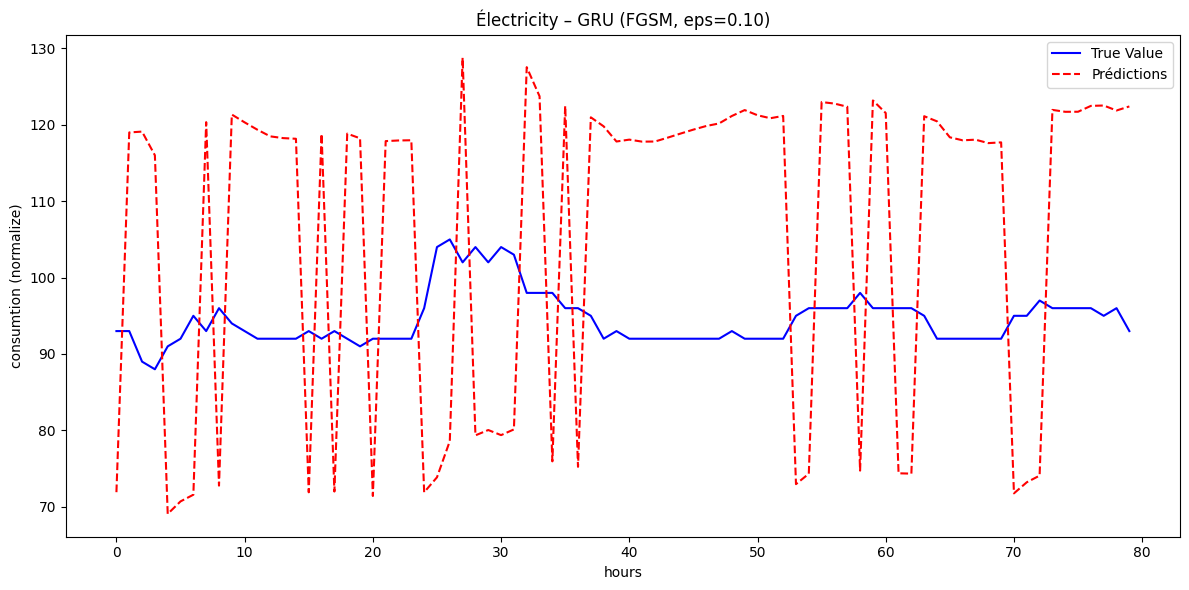

LSTM | FGSM – Epsilon 0.10 – MAE: 26.0127 | SIM: 0.9785


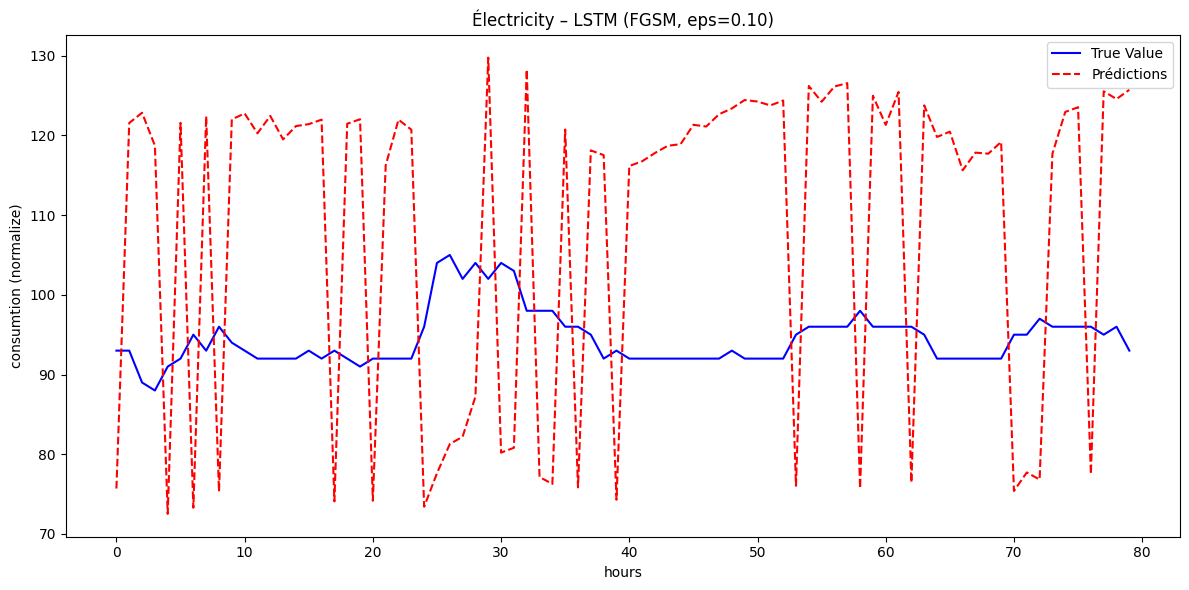

RNN | FGSM – Epsilon 0.10 – MAE: 30.2542 | SIM: 0.9834


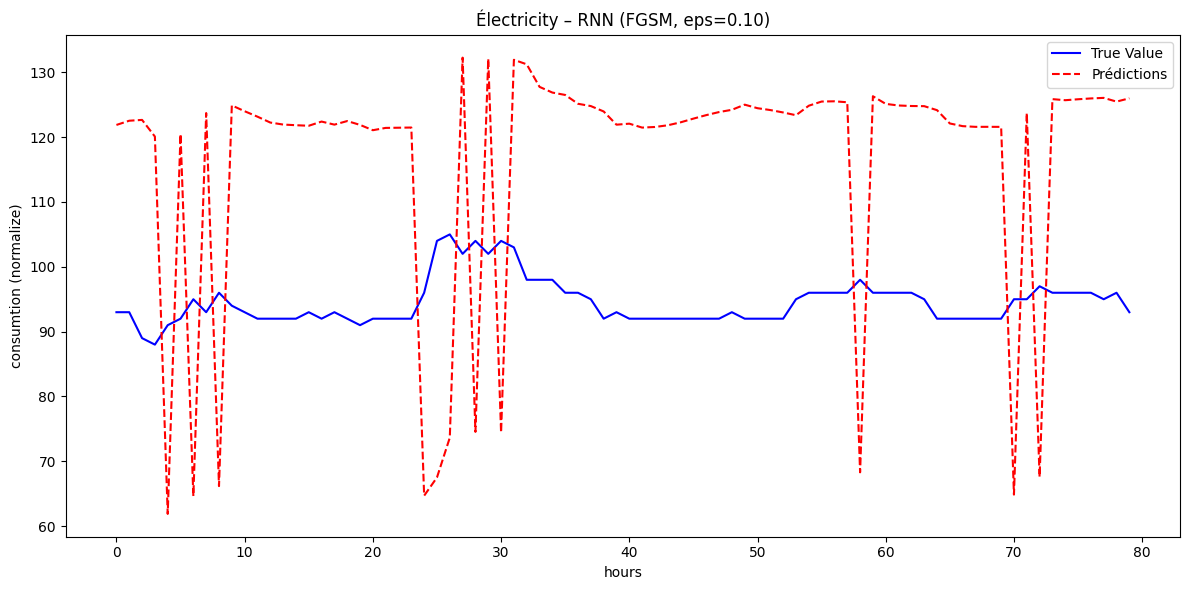

GRU | FGSM – Epsilon 0.20 – MAE: 46.0942 | SIM: 0.9404


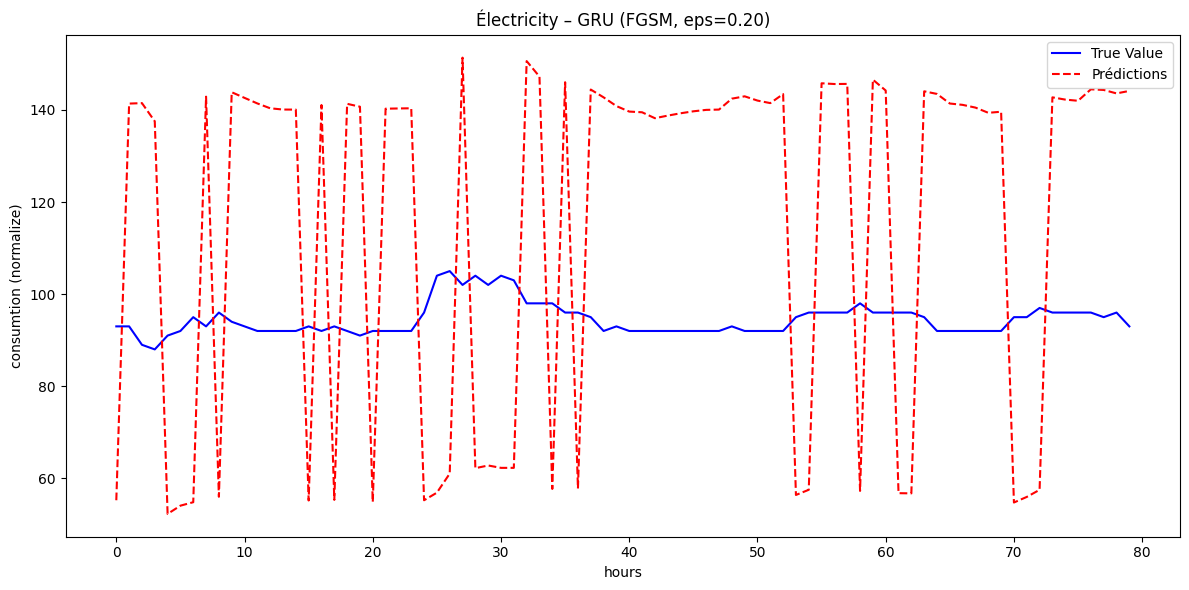

LSTM | FGSM – Epsilon 0.20 – MAE: 43.9629 | SIM: 0.9493


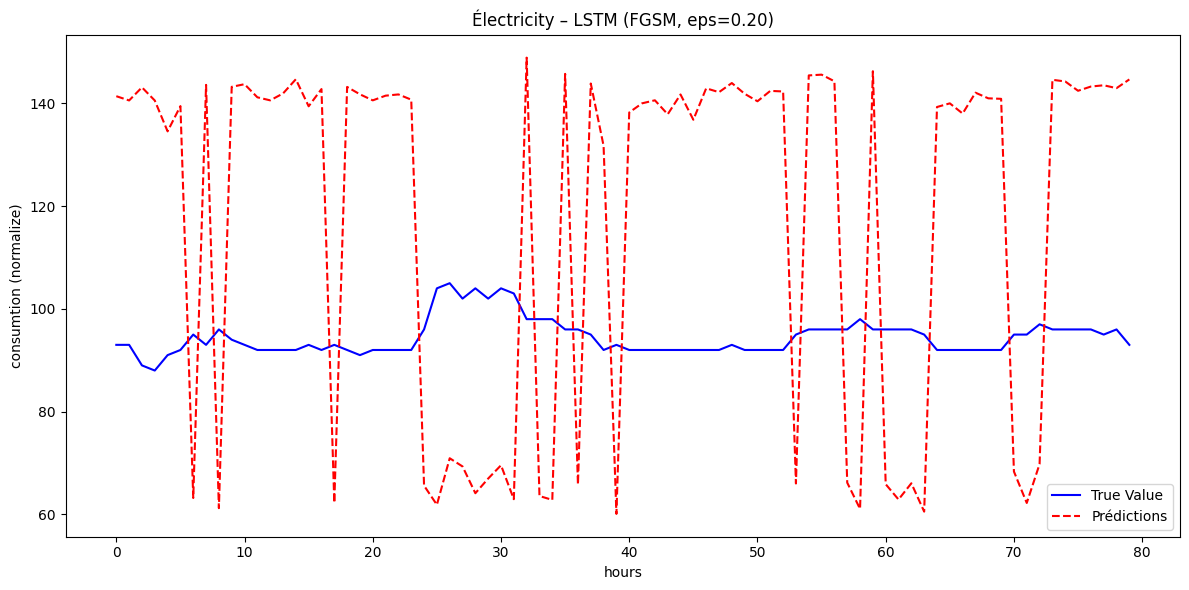

RNN | FGSM – Epsilon 0.20 – MAE: 56.5378 | SIM: 0.9584


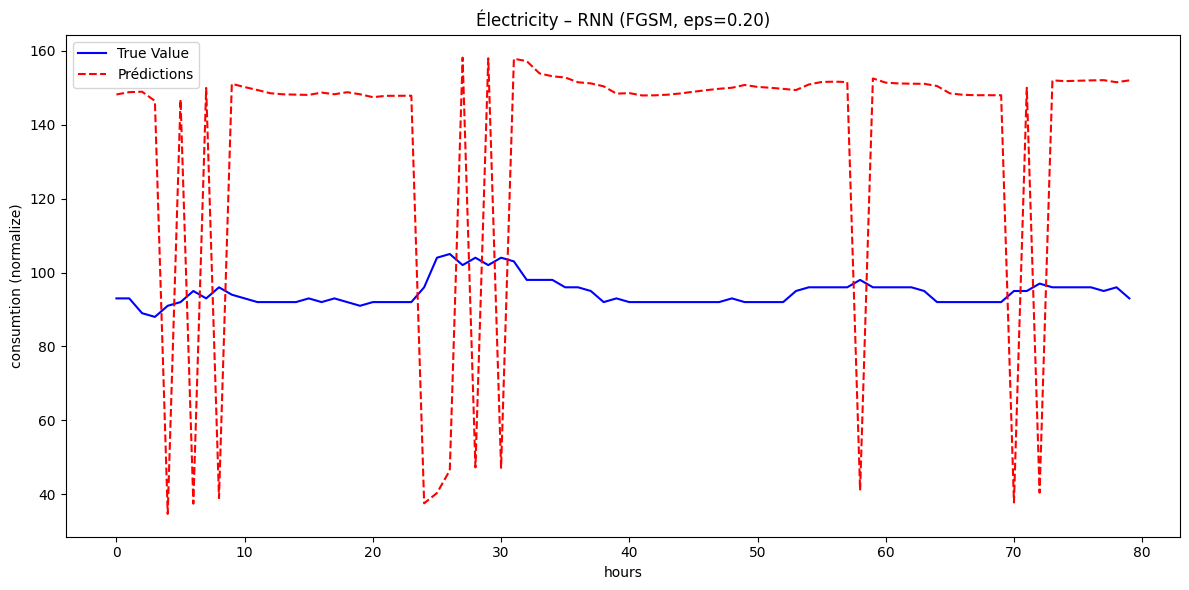

In [37]:
epsilons_fgsm = [0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1, 0.2]

for eps in epsilons_fgsm:
    true_vals_fgsm, preds_fgsm = fgsm_attack(
        model_gru, test_loader, loss_fn, eps, serie_min_rev, serie_max_rev
    )

    log_and_plot_elec(
        true_values=true_vals_fgsm[-n_hours:],
        predictions=preds_fgsm[-n_hours:],
        model_name='GRU',
        attack_name='FGSM',
        epsilon=eps,
        res_tab=res_tab_fgsm,
        similarity_fn=scalar_similarity,
        save_path=f"results/elec/SEED_{seed}/plots/FGSM/{eps}",
        save_png=True
    )

    true_vals_fgsm, preds_fgsm = fgsm_attack(
        model, test_loader, loss_fn, eps, serie_min_rev, serie_max_rev
    )

    log_and_plot_elec(
        true_values=true_vals_fgsm[-n_hours:],
        predictions=preds_fgsm[-n_hours:],
        model_name='LSTM',
        attack_name='FGSM',
        epsilon=eps,
        res_tab=res_tab_fgsm,
        similarity_fn=scalar_similarity,
        save_path=f"results/elec/SEED_{seed}/plots/FGSM/{eps}",
        save_png=True
    )

    true_vals_fgsm, preds_fgsm = fgsm_attack(
        model_rnn, test_loader, loss_fn, eps, serie_min_rev, serie_max_rev
    )

    log_and_plot_elec(
        true_values=true_vals_fgsm[-n_hours:],
        predictions=preds_fgsm[-n_hours:],
        model_name='RNN',
        attack_name='FGSM',
        epsilon=eps,
        res_tab=res_tab_fgsm,
        similarity_fn=scalar_similarity,
        save_path=f"results/elec/SEED_{seed}/plots/FGSM/{eps}",
        save_png=True
    )


In [38]:
display(res_tab_fgsm)

Attack            FGSM                                                        \
ε                 0.01      0.02       0.03       0.04       0.05       0.07   
Model Metric                                                                   
LSTM  MAE     3.956958  6.351583   8.910020  11.364468  13.876124  20.542337   
      RMSE    4.233530  6.570435   9.074512  11.545886  14.074180  20.745245   
      SIM     0.999182  0.998062   0.997004   0.995145   0.992744   0.987873   
RNN   MAE     4.879912  7.743302  10.600060  13.448234  16.285912  23.322100   
      RMSE    5.075445  7.867643  10.690906  13.519658  16.344665  23.362634   
      SIM     0.999278  0.998413   0.997236   0.995791   0.994116   0.989150   
GRU   MAE     3.875482  6.347599   8.824775  11.298175  13.759360  19.810122   
      RMSE    4.133745  6.511658   8.946979  11.399038  13.850010  19.903297   
      SIM     0.999155  0.998003   0.996377   0.994333   0.991932   0.984741   

Attack                              
ε                  0.10       0.20  
Model Metric                        
LSTM  MAE     26.012677  43.962884  
      RMSE    26.396452  44.653686  
      SIM      0.978451   0.949267  
RNN   MAE     30.254191  56.537820  
      RMSE    30.285059  56.554994  
      SIM      0.983424   0.958385  
GRU   MAE     25.643132  46.094218  
      RMSE    25.761636  46.318056  
      SIM      0.976455   0.940433

In [39]:
from attack.rev_bim import reverse_forecast_attack_bim

In [40]:
# Creation of the tab result for plotting adversial attack result
models = ['LSTM','RNN','GRU']
metrics = ['MAE', "RMSE", 'SIM']

row_index = pd.MultiIndex.from_product([models, metrics], names=['Model', 'Metric'])

attacks = ['REV_BIM']
epsilons = {
    'REV_BIM':[0.01,0.02,0.03,0.04, 0.05, 0.075, 0.1, 0.2],
}

col_tuples = []
for atk, eps_list in epsilons.items():
    for eps in eps_list:
        col_tuples.append((atk, f"{eps:.2f}"))

col_index = pd.MultiIndex.from_tuples(col_tuples, names=['Attack', 'ε'])

res_tab_bim = pd.DataFrame(index=row_index, columns=col_index, dtype=float)

print(res_tab_bim)

Attack       REV_BIM                                   
ε               0.01 0.02 0.03 0.04 0.05 0.07 0.10 0.20
Model Metric                                           
LSTM  MAE        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      RMSE       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      SIM        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
RNN   MAE        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      RMSE       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      SIM        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
GRU   MAE        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      RMSE       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
      SIM        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN


GRU | REV_BIM – Epsilon 0.01 – MAE: 2.0909 | SIM: 0.9996


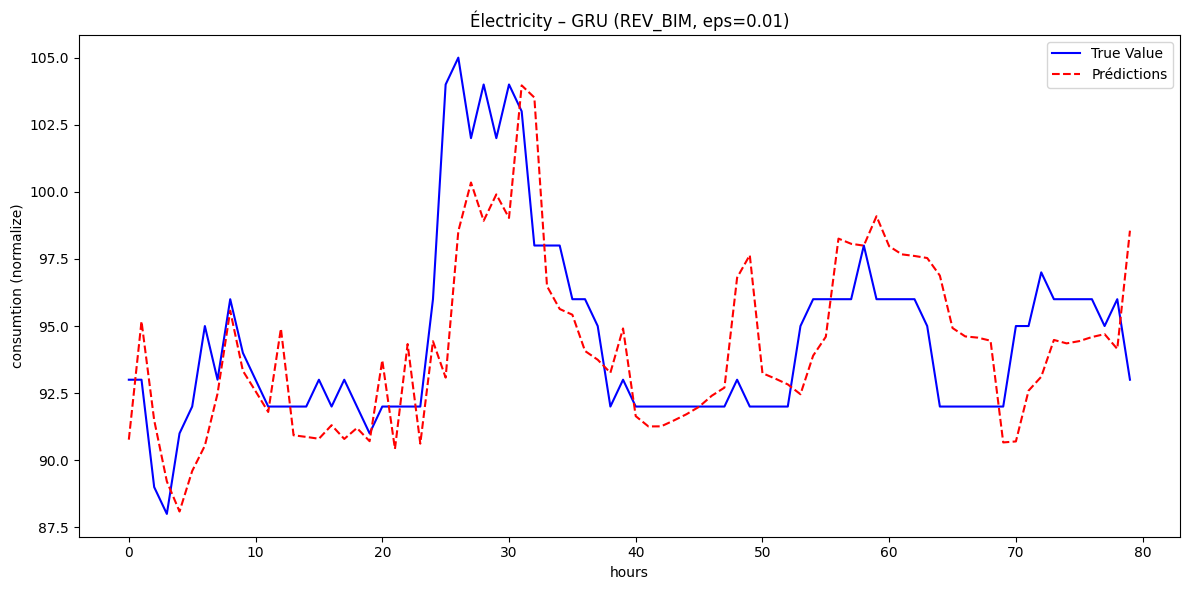

GRU | REV_BIM – Epsilon 0.02 – MAE: 3.6838 | SIM: 0.9990


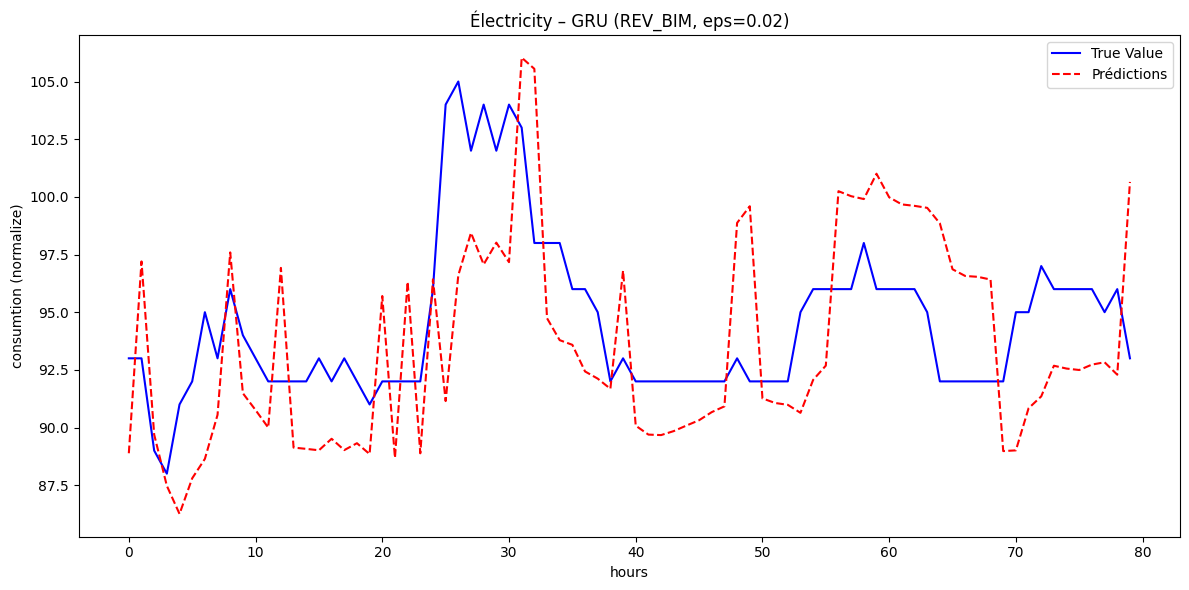

GRU | REV_BIM – Epsilon 0.03 – MAE: 5.4479 | SIM: 0.9982


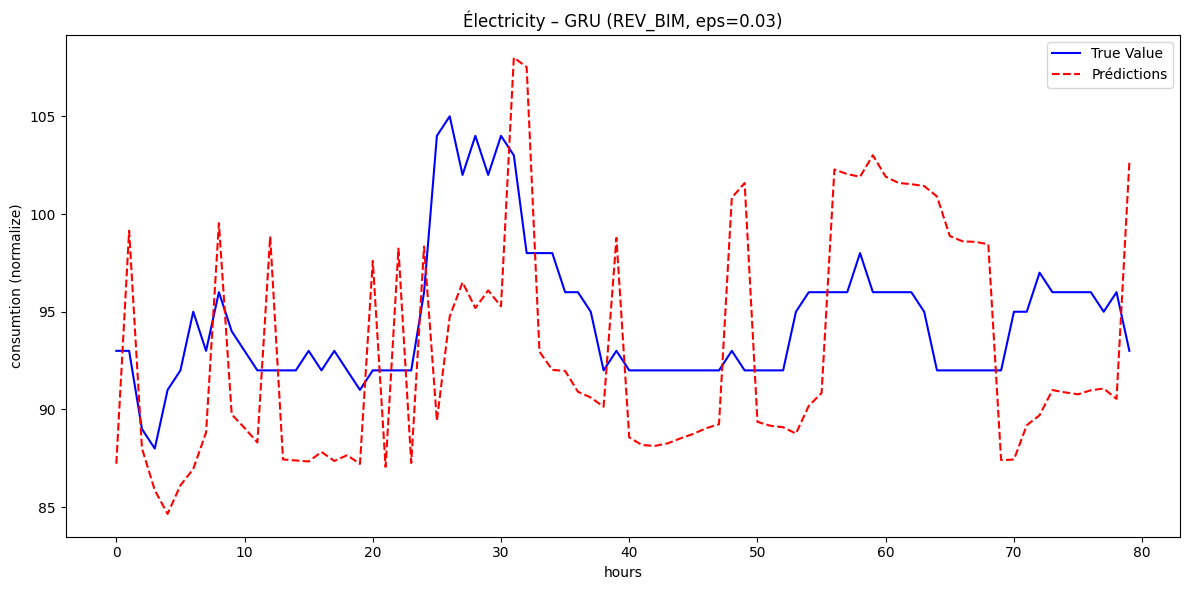

GRU | REV_BIM – Epsilon 0.04 – MAE: 7.1577 | SIM: 0.9970


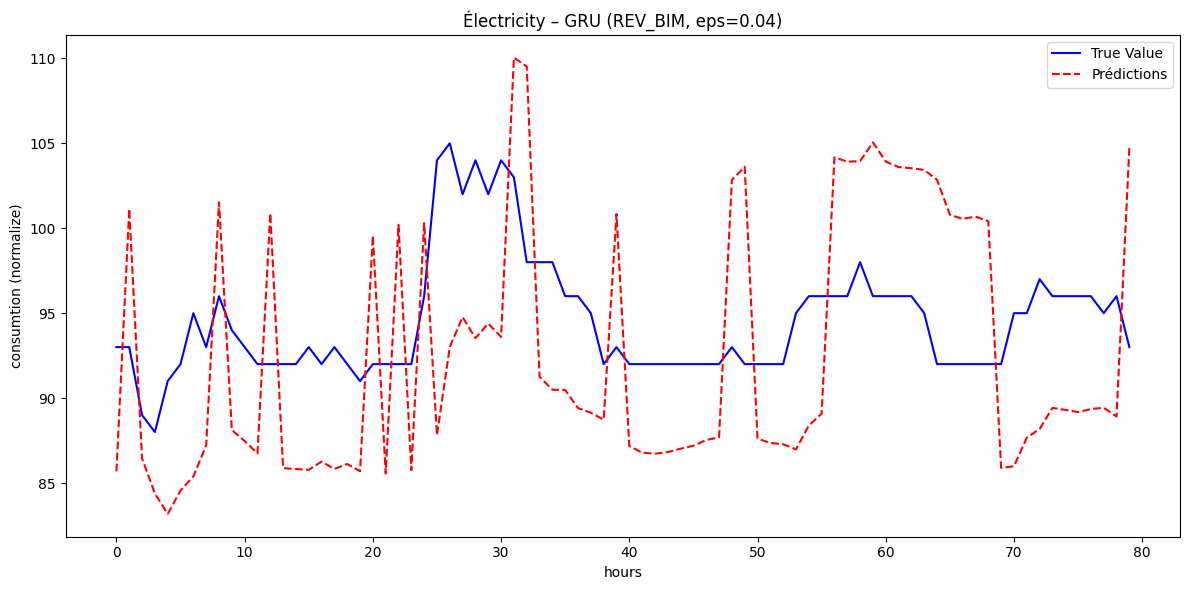

GRU | REV_BIM – Epsilon 0.05 – MAE: 8.7829 | SIM: 0.9955


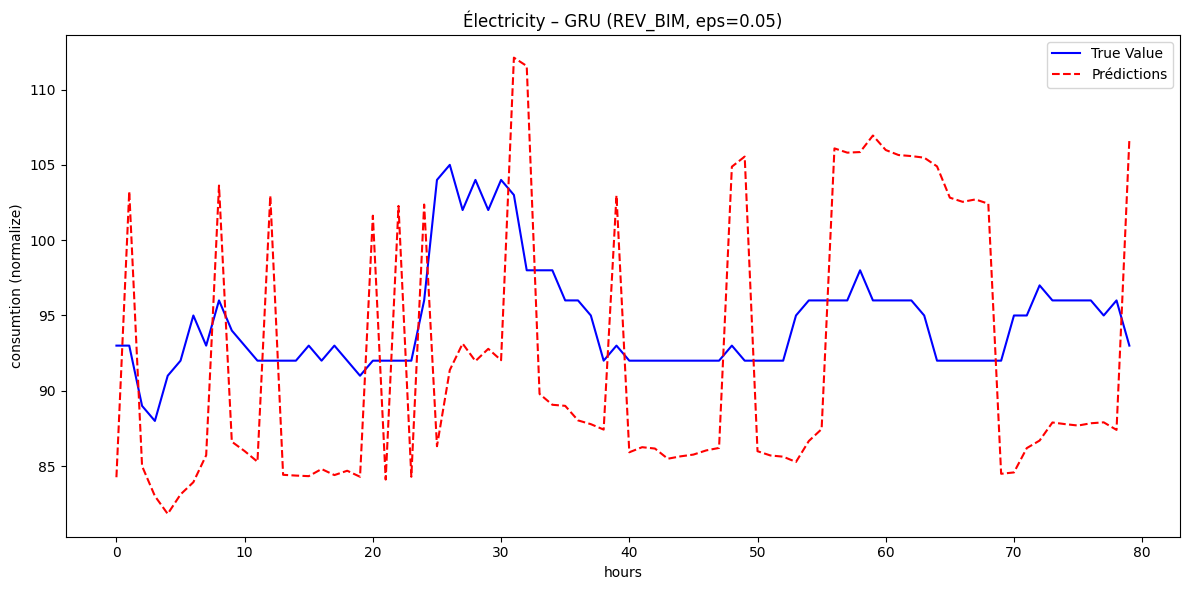

GRU | REV_BIM – Epsilon 0.07 – MAE: 11.6742 | SIM: 0.9920


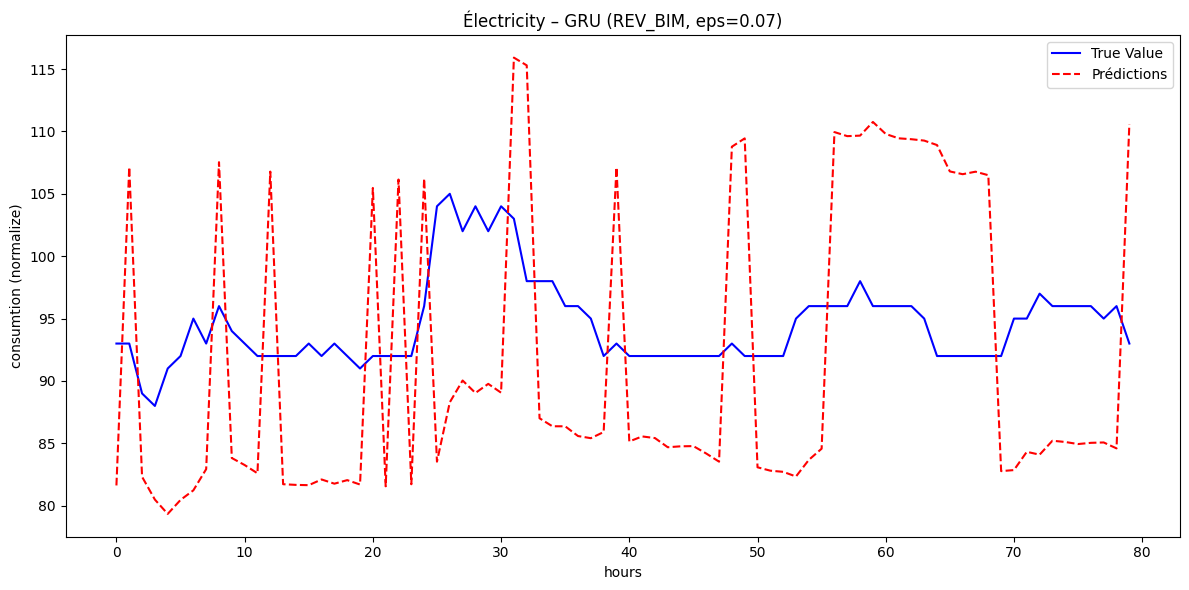

GRU | REV_BIM – Epsilon 0.10 – MAE: 14.4873 | SIM: 0.9870


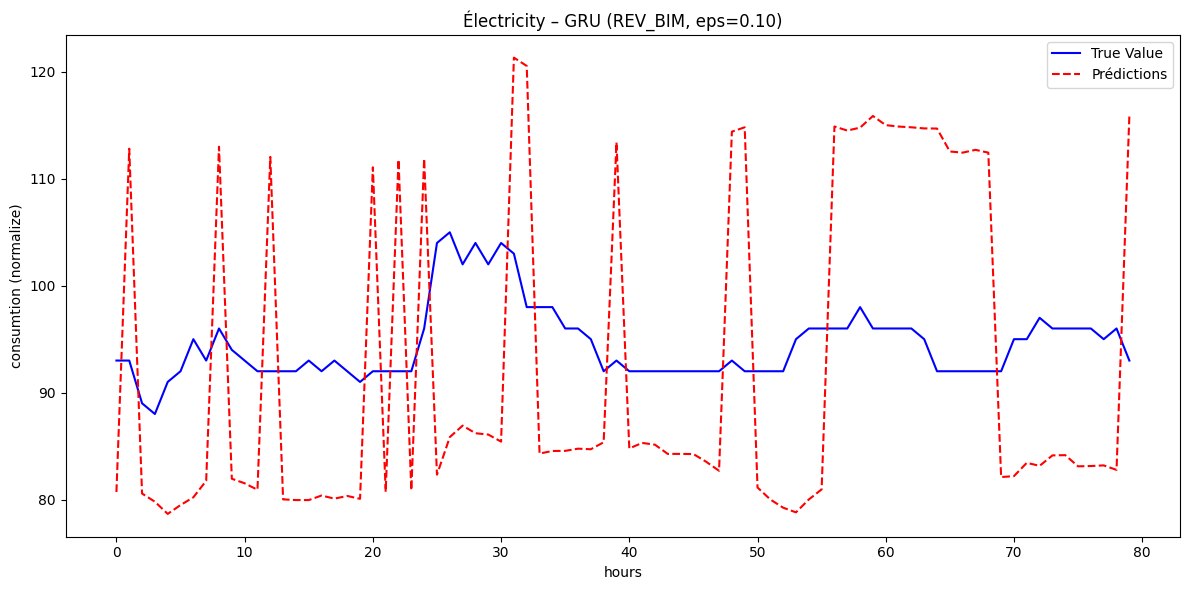

GRU | REV_BIM – Epsilon 0.20 – MAE: 14.0743 | SIM: 0.9848


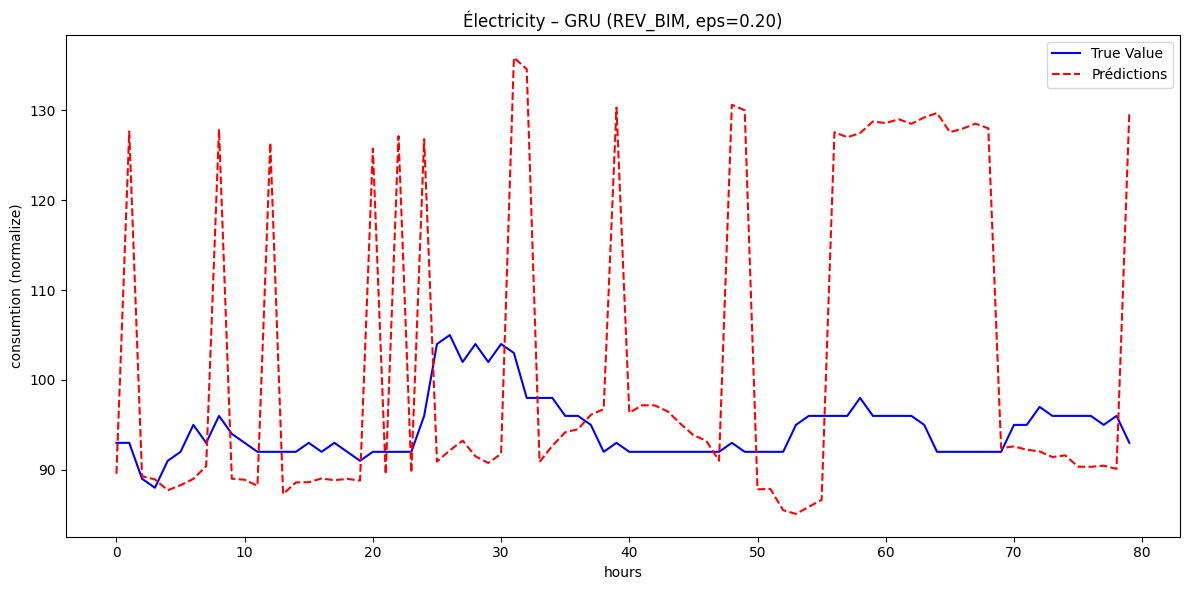

LSTM | REV_BIM – Epsilon 0.01 – MAE: 2.5611 | SIM: 0.9996


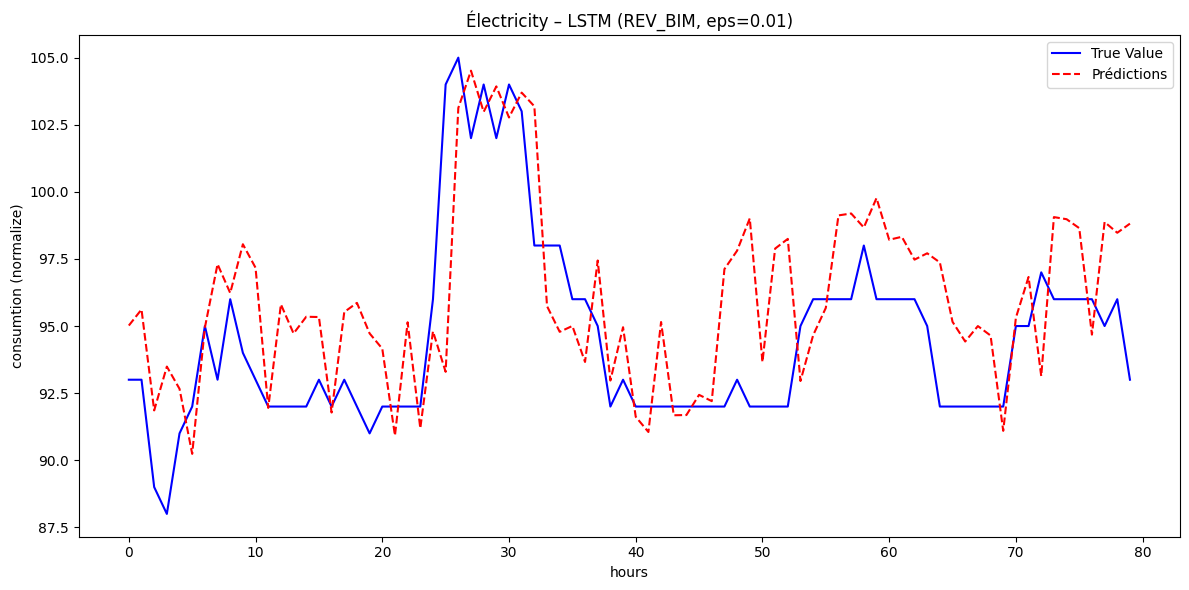

LSTM | REV_BIM – Epsilon 0.02 – MAE: 4.4536 | SIM: 0.9988


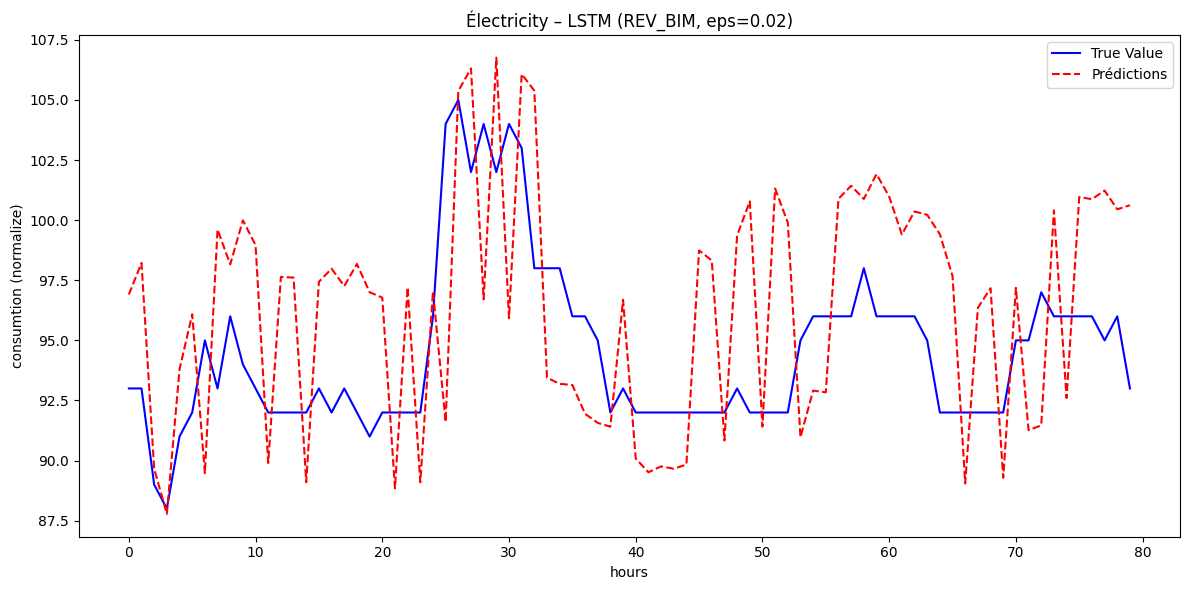

LSTM | REV_BIM – Epsilon 0.03 – MAE: 6.6575 | SIM: 0.9981


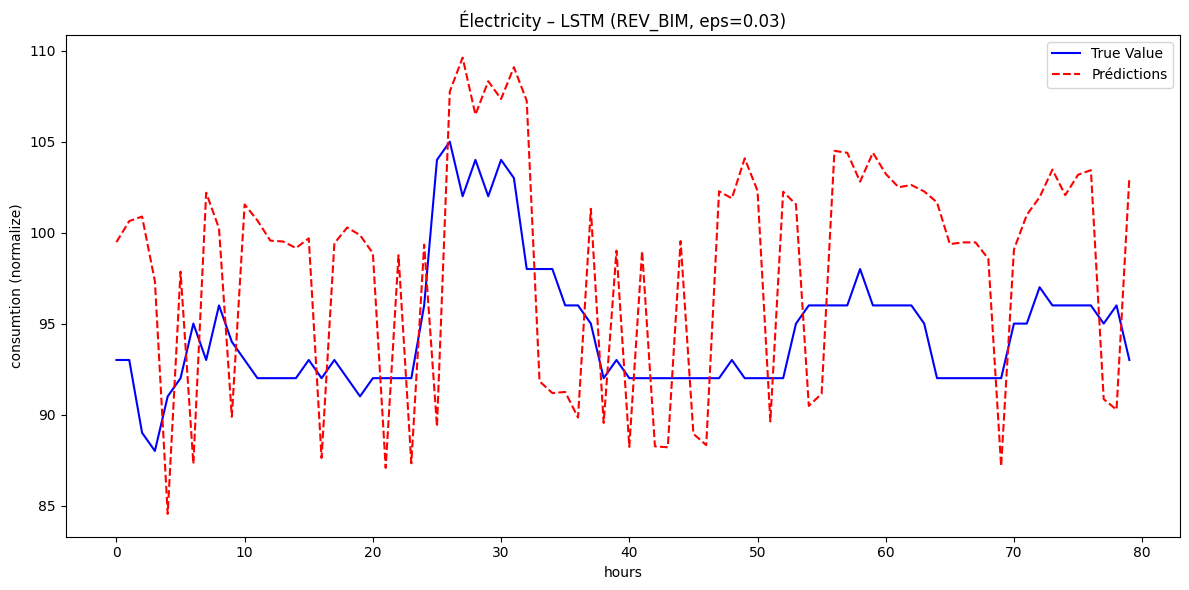

LSTM | REV_BIM – Epsilon 0.04 – MAE: 8.4152 | SIM: 0.9968


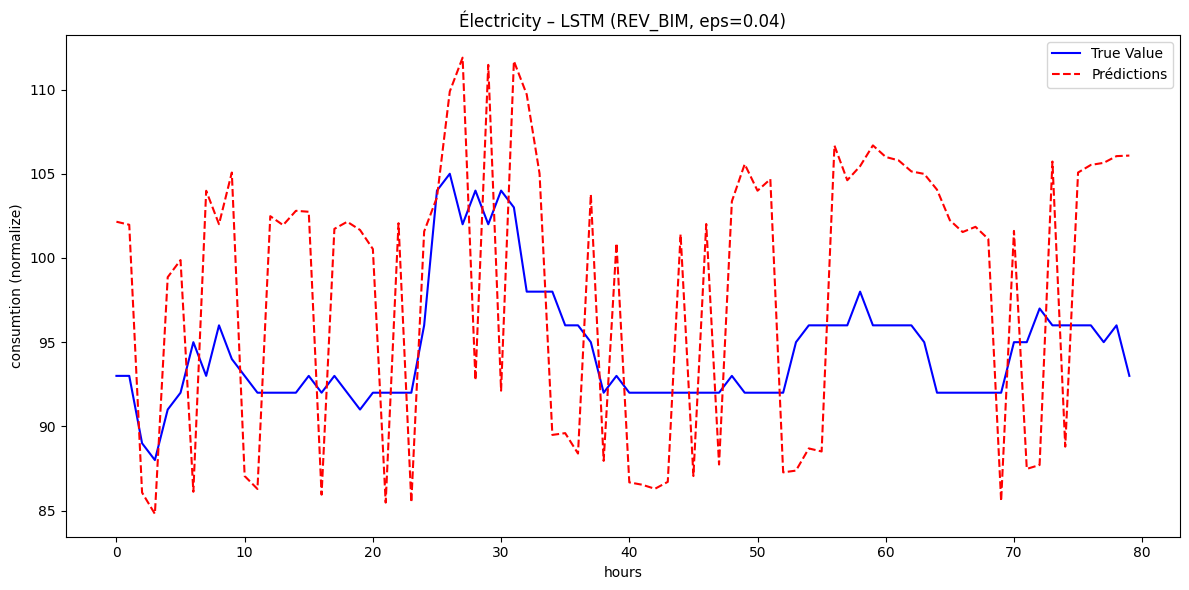

LSTM | REV_BIM – Epsilon 0.05 – MAE: 10.8693 | SIM: 0.9952


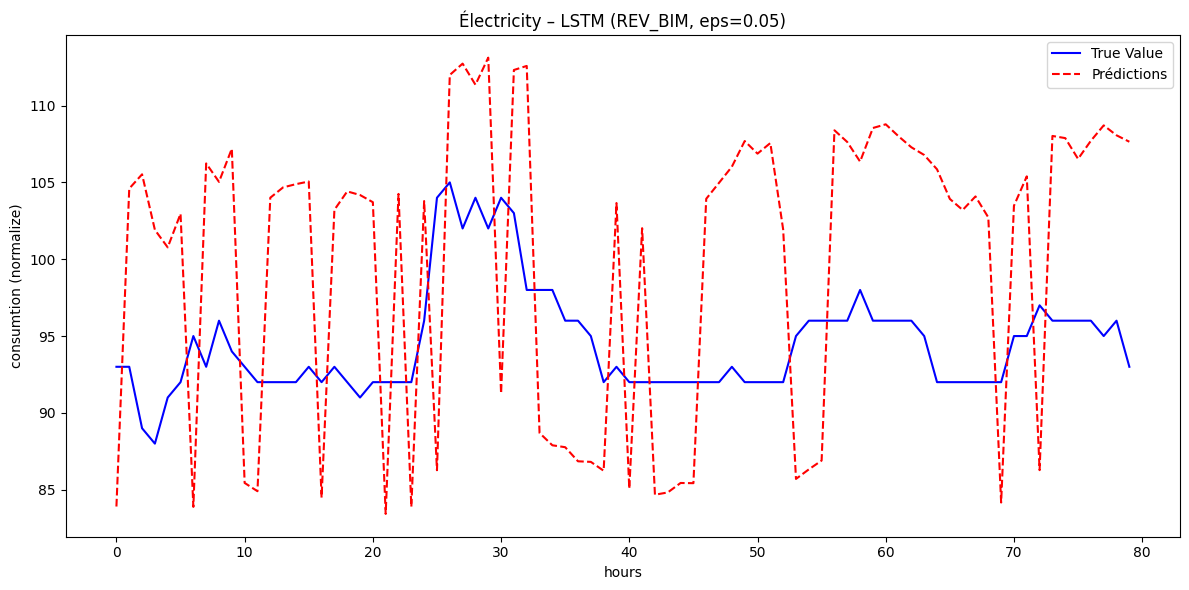

LSTM | REV_BIM – Epsilon 0.07 – MAE: 14.4742 | SIM: 0.9916


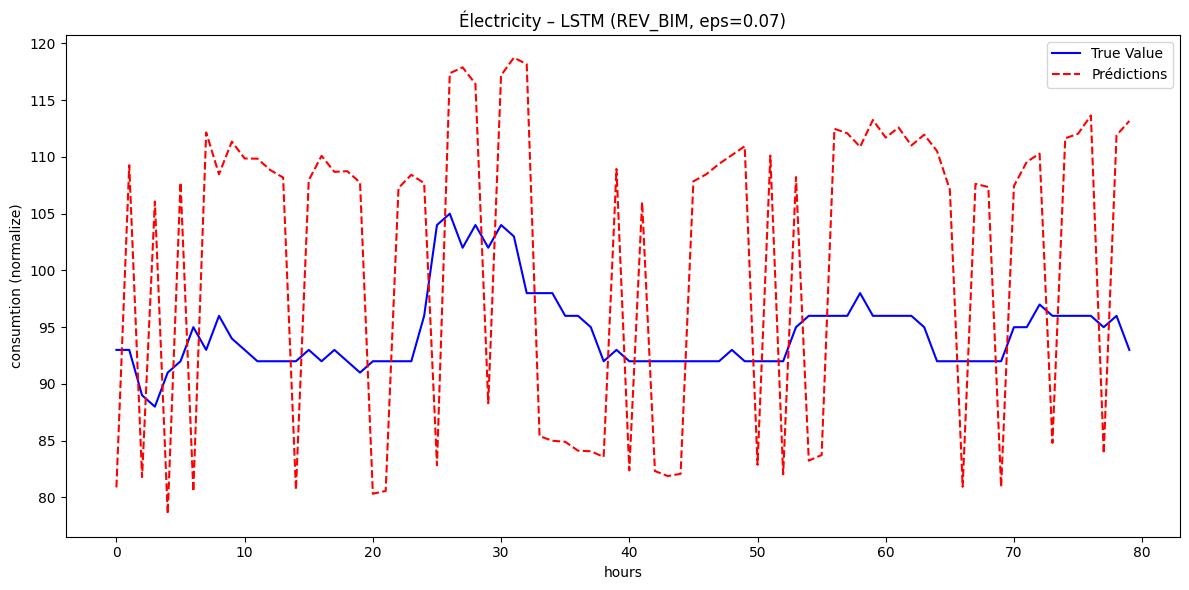

LSTM | REV_BIM – Epsilon 0.10 – MAE: 19.2781 | SIM: 0.9866


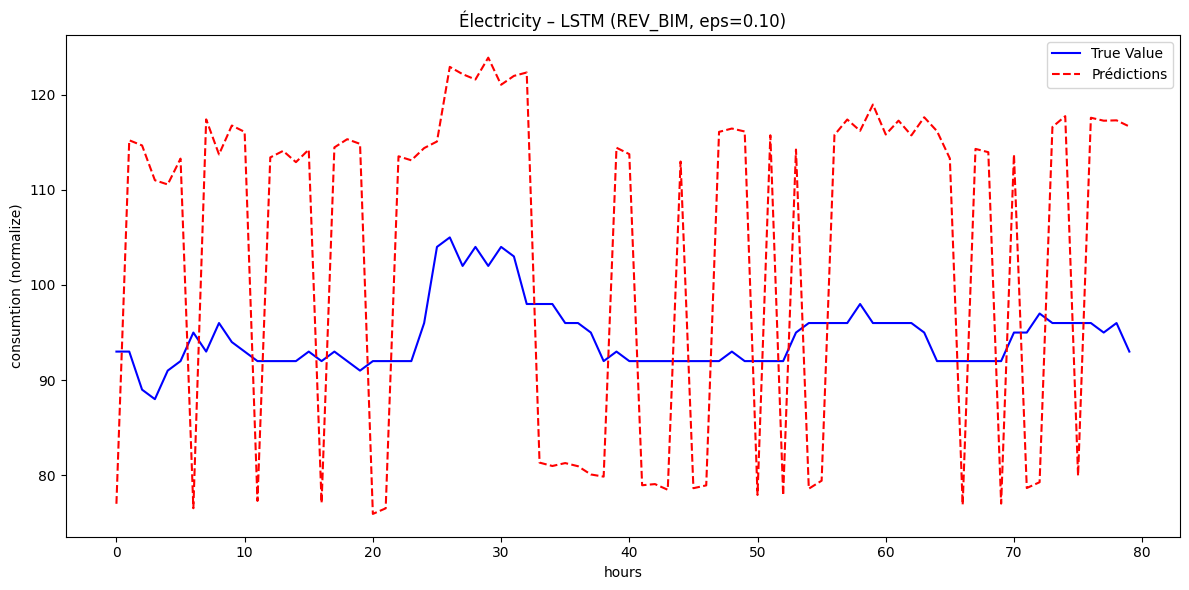

LSTM | REV_BIM – Epsilon 0.20 – MAE: 33.8891 | SIM: 0.9752


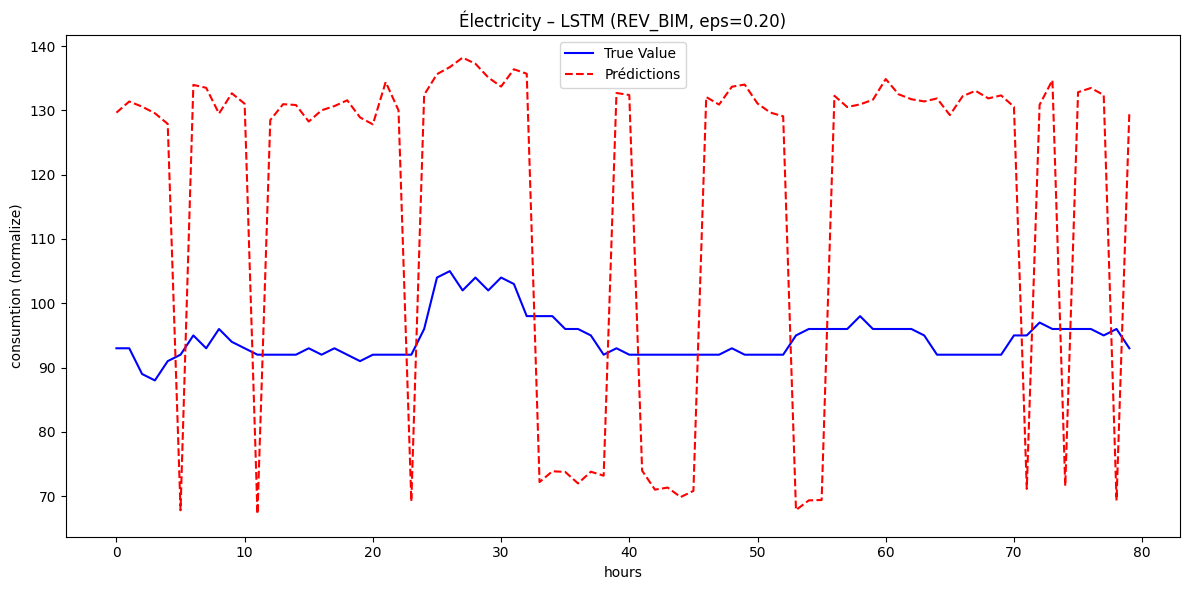

RNN | REV_BIM – Epsilon 0.01 – MAE: 1.8775 | SIM: 0.9996


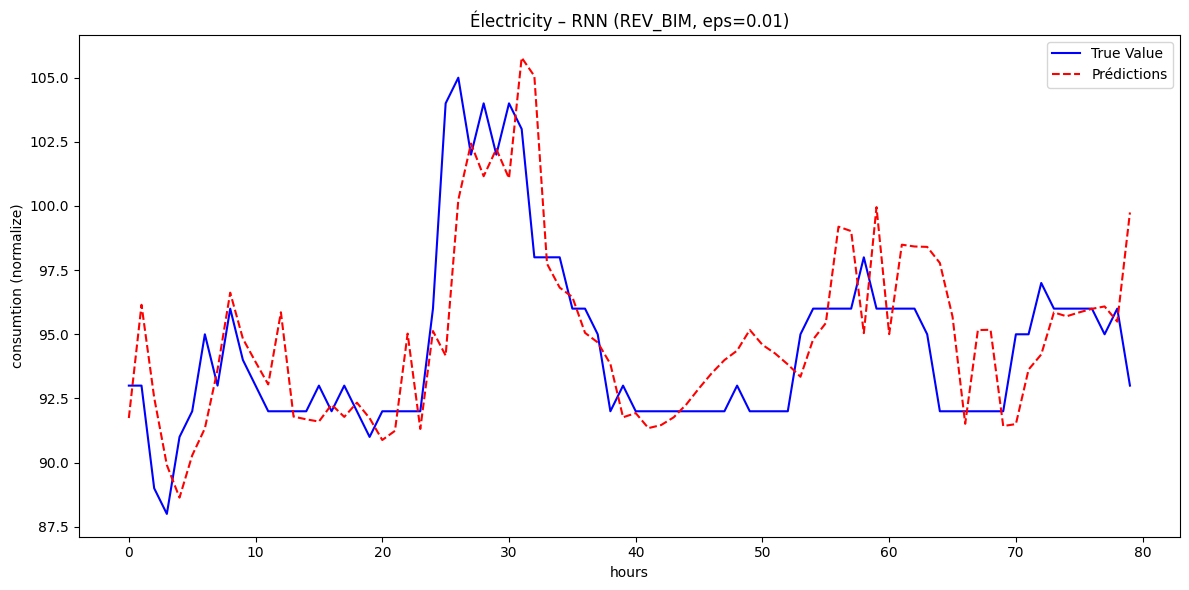

RNN | REV_BIM – Epsilon 0.02 – MAE: 3.0812 | SIM: 0.9992


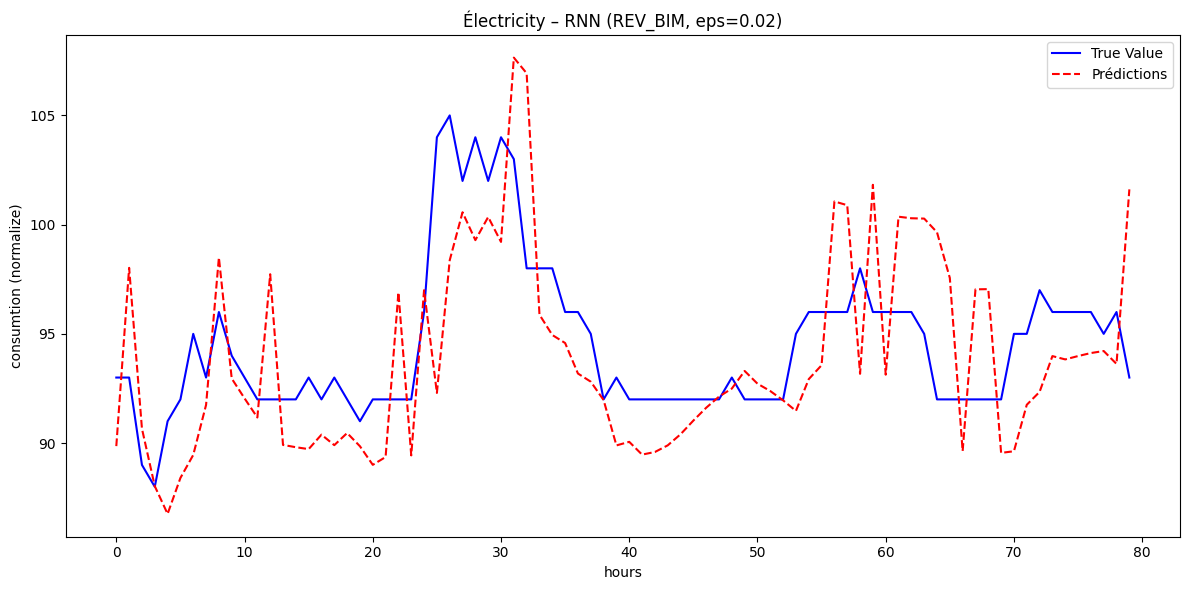

RNN | REV_BIM – Epsilon 0.03 – MAE: 4.8482 | SIM: 0.9985


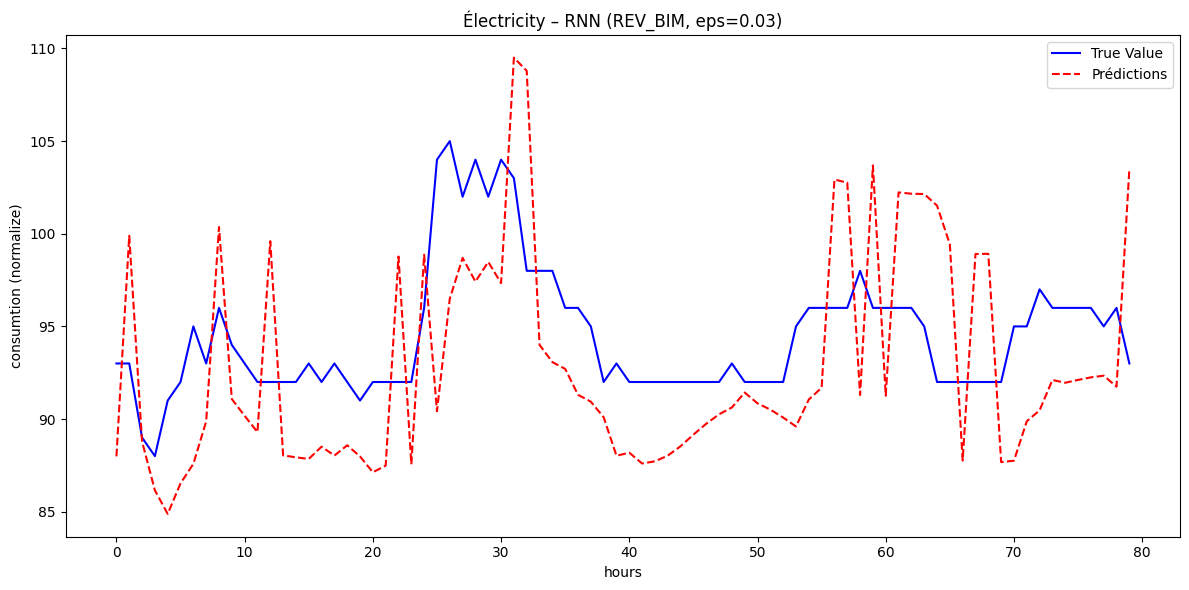

RNN | REV_BIM – Epsilon 0.04 – MAE: 6.7207 | SIM: 0.9974


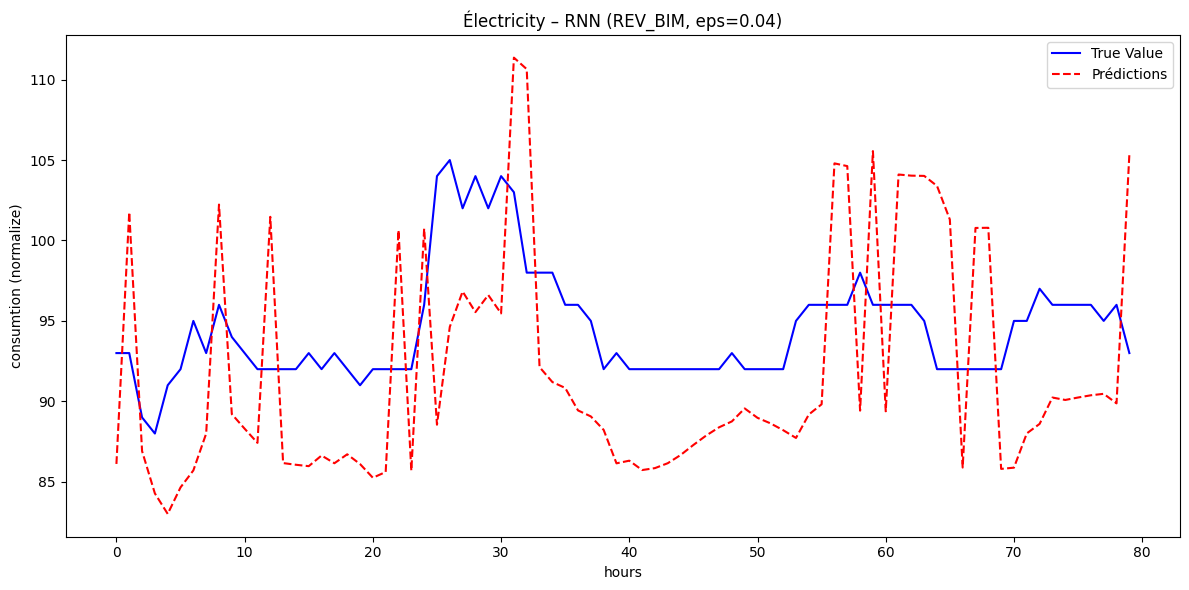

RNN | REV_BIM – Epsilon 0.05 – MAE: 8.5933 | SIM: 0.9961


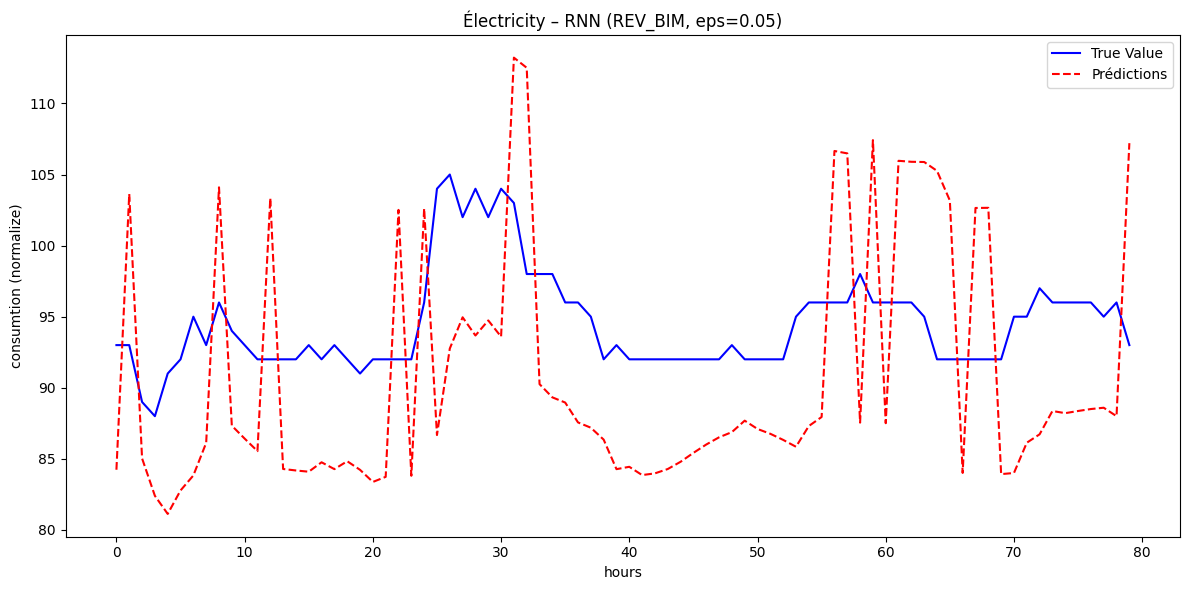

RNN | REV_BIM – Epsilon 0.07 – MAE: 12.3695 | SIM: 0.9922


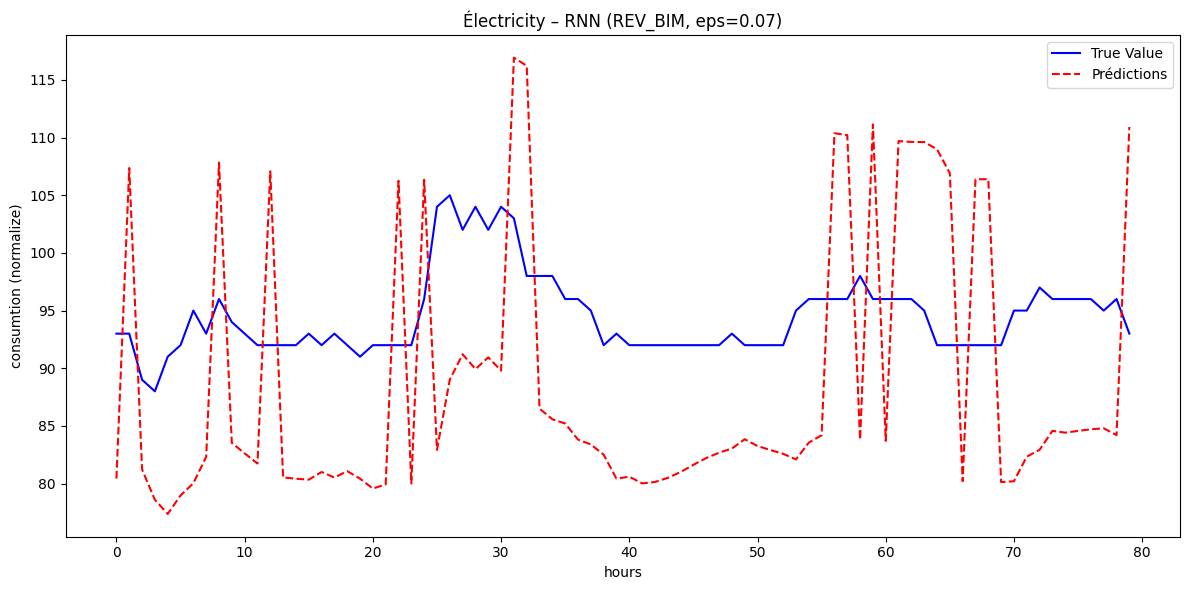

RNN | REV_BIM – Epsilon 0.10 – MAE: 18.1065 | SIM: 0.9832


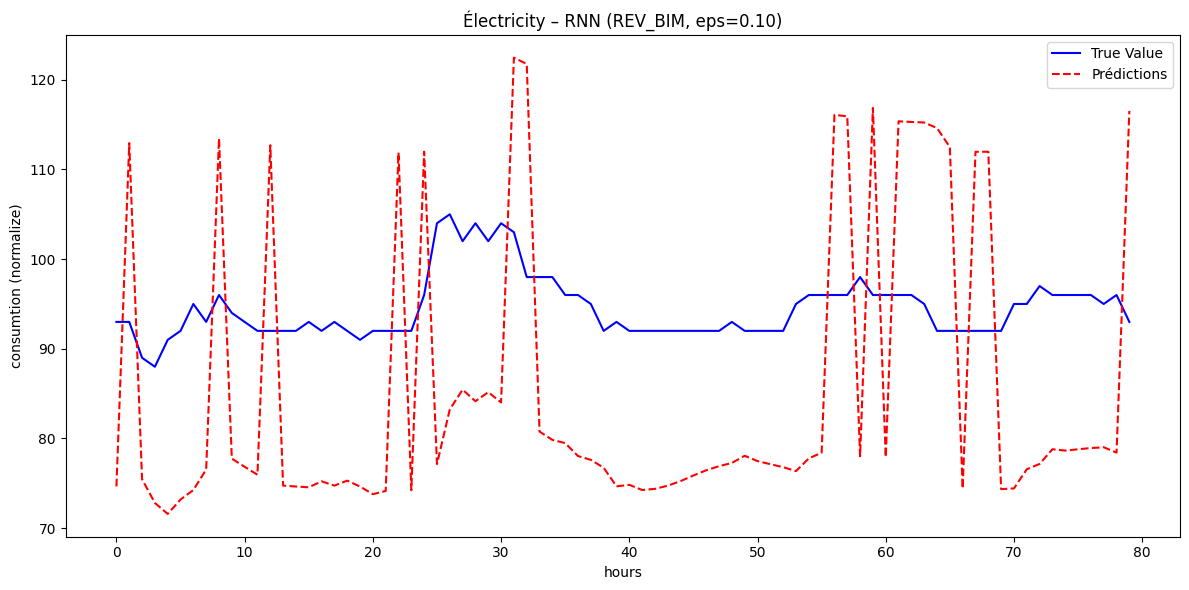

KeyboardInterrupt: 

In [41]:
from attack.rev_bim import reverse_forecast_attack_bim
alpha = 0.01
epsilons = [0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1, 0.2]

bim_attacks = [
    {
        "model_rev": model_gru_rev,
        "model_target": model_gru,
        "model_name": "GRU"
    },
    {
        "model_rev": model_rev,
        "model_target": model,
        "model_name": "LSTM"
    },
    {
        "model_rev": model_rnn_rev,
        "model_target": model_rnn,
        "model_name": "RNN"
    }
]

for attack in bim_attacks:
    for eps in epsilons:
        num_iter = int(eps / alpha)

        results_bim = reverse_forecast_attack_bim(
            model_rev=attack["model_rev"],
            model_normal=attack["model_target"],
            test_loader_rev=test_loader_rev,
            test_loader=test_loader,
            epsilons=[eps],
            price_min=serie_min_rev,
            price_max=serie_max_rev,
            alpha=alpha,
            num_iter=num_iter
        )

        for eps_val, (true_vals, preds) in results_bim.items():
            log_and_plot_elec(
                true_values=true_vals[-n_hours:],
                predictions=preds[-n_hours:],
                model_name=attack["model_name"],
                attack_name="REV_BIM",
                epsilon=eps_val,
                res_tab=res_tab_bim,
                similarity_fn=scalar_similarity,
                save_path=f"results/elec/SEED_{seed}/plots/REV_BIM/{eps_val}",
                save_png=True
            )


In [ ]:
display(res_tab_bim)

In [ ]:
model_surrogate = SimpleLSTM(input_size=1, hidden_size=64, output_size=1, num_layers=2)
optimizer = torch.optim.Adam(model_surrogate.parameters(), lr=0.001)
model_surrogate.to(device)
train_models_elec(model_surrogate, loss_fn, optimizer, num_epochs, train_loader,device)

In [ ]:
model_rnn_surrogate = SimpleRNN(input_size=1, hidden_size=64, output_size=1, num_layers=2)
optimizer = torch.optim.Adam(model_rnn_surrogate.parameters(), lr=0.001)
model_rnn_surrogate.to(device)
train_models_elec(model_rnn_surrogate, loss_fn, optimizer, num_epochs, train_loader,device)

In [ ]:
model_gru_surrogate = SimpleGRU(input_size=1, hidden_size=64, output_size=1, num_layers=2)
optimizer = torch.optim.Adam(model_gru_surrogate.parameters(), lr=0.001)
model_gru_surrogate.to(device)
train_models_elec(model_gru_surrogate, loss_fn, optimizer, num_epochs, train_loader,device)

In [ ]:
from attack.fgsm_surrogate import fgsm_surrogate_attack

In [ ]:
for eps in epsilons:
    true_vals_surro, preds_surro = fgsm_surrogate_attack(
        model_gru_surrogate,
        model_gru,
        test_loader,
        eps,
        serie_min_rev, serie_max_rev
    )

    log_and_plot_elec(
        true_values=true_vals_surro[-n_hours:],
        predictions=preds_surro[-n_hours:],
        model_name='GRU',
        attack_name='FGSM_SURRO',
        epsilon=eps,
        res_tab=res_tab_bim,
        similarity_fn=scalar_similarity,
        save_path=f"results/elec/SEED_{seed}/plots/FGSM_SURRO/{eps}",
        save_png=True
    )

    true_vals_surro, preds_surro = fgsm_surrogate_attack(
        model_rnn_surrogate,
        model_rnn,
        test_loader,
        eps,
        serie_min_rev, serie_max_rev
    )

    log_and_plot_elec(
        true_values=true_vals_surro[-n_hours:],
        predictions=preds_surro[-n_hours:],
        model_name='RNN',
        attack_name='FGSM_SURRO',
        epsilon=eps,
        res_tab=res_tab_bim,
        similarity_fn=scalar_similarity,
        save_path=f"results/elec/SEED_{seed}/plots/FGSM_SURRO/{eps}",
        save_png=True
    )

    true_vals_surro, preds_surro = fgsm_surrogate_attack(
        model_surrogate,
        model,
        test_loader,
        eps,
        serie_min_rev, serie_max_rev
    )

    log_and_plot_elec(
        true_values=true_vals_surro[-n_hours:],
        predictions=preds_surro[-n_hours:],
        model_name='LSTM',
        attack_name='FGSM_SURRO',
        epsilon=eps,
        res_tab=res_tab_bim,
        similarity_fn=scalar_similarity,
        save_path=f"results/elec/SEED_{seed}/plots/FGSM_SURRO/{eps}",
        save_png=True
    )

In [ ]:
display(res_tab)

In [ ]:
display(res_tab_bim)

In [ ]:
display(res_tab_fgsm)

In [ ]:
# Creation of the tab result for plotting adversial attack result
models = ['LSTM','RNN','GRU']
metrics = ['MAE', "RMSE", 'SIM']

row_index = pd.MultiIndex.from_product([models, metrics], names=['Model', 'Metric'])

attacks = ['BOUNDARY']
epsilons_attack = {
    'BOUNDARY':[0.01,0.02,0.03,0.04, 0.05, 0.075, 0.1, 0.2],
}

col_tuples = []
for atk, eps_list in epsilons_attack.items():
    for eps in eps_list:
        col_tuples.append((atk, f"{eps:.2f}"))

col_index = pd.MultiIndex.from_tuples(col_tuples, names=['Attack', 'ε'])

res_tab_boundary = pd.DataFrame(index=row_index, columns=col_index, dtype=float)

print(res_tab_boundary)

In [ ]:
from attack.boundary import boundary_attack

In [ ]:
for eps in epsilons:
  delta = eps * 0.5
  eta = eps * 0.25
  num_iter = int(20 + 200 * eps)
  true_vals_bondary, preds_bondary = boundary_attack(
      model_gru,
      test_loader,
      eps,
      serie_min_rev, serie_max_rev,
      num_iter,delta,eta
  )

  log_and_plot_elec(
      true_values=true_vals_bondary[-n_hours:],
      predictions=preds_bondary[-n_hours:],
      model_name='GRU',
      attack_name='BOUNDARY',
      epsilon=eps,
      res_tab=res_tab_boundary,
      similarity_fn=scalar_similarity,
      save_path=f"results/elec/SEED_{seed}/plots/BOUNDARY/{eps}",
      save_png=True
  )

  true_vals_bondary, preds_bondary = boundary_attack(
      model,
      test_loader,
      eps,
      serie_min_rev, serie_max_rev,
      num_iter,delta,eta
  )

  log_and_plot_elec(
      true_values=true_vals_bondary[-n_hours:],
      predictions=preds_bondary[-n_hours:],
      model_name='LSTM',
      attack_name='BOUNDARY',
      epsilon=eps,
      res_tab=res_tab_boundary,
      similarity_fn=scalar_similarity,
      save_path=f"results/elec/SEED_{seed}/plots/BOUNDARY/{eps}",
      save_png=True
  )

  true_vals_bondary, preds_bondary = boundary_attack(
      model_rnn,
      test_loader,
      eps,
      serie_min_rev, serie_max_rev,
      num_iter,delta,eta
  )

  log_and_plot_elec(
      true_values=true_vals_bondary[-n_hours:],
      predictions=preds_bondary[-n_hours:],
      model_name='RNN',
      attack_name='BOUNDARY',
      epsilon=eps,
      res_tab=res_tab_boundary,
      similarity_fn=scalar_similarity,
      save_path=f"results/elec/SEED_{seed}/plots/BOUNDARY/{eps}",
      save_png=True
  )

In [ ]:
display(res_tab_boundary)

In [ ]:
display(res_tab)

In [ ]:
result = pd.concat([res_tab, res_tab_bim,res_tab_fgsm,res_tab_boundary], axis=1)

# Affichage du résultat
display(result)
result.to_excel(f"results/elec/SEED_{seed}/result.xlsx")